<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/Copia_de_Modulo2Dario_Preparacion_Calidad_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; font-family: 'Segoe UI', sans-serif;">
  <h1 style="color: #e94560; font-size: 2.4em; margin-bottom: 8px;">🏭 CIENCIA DE DATOS APLICADA AL MANTENIMIENTO PREDICTIVO</h1>
  <h2 style="color: #a8dadc; font-size: 1.6em; margin-bottom: 6px;">MÓDULO 2 — Preparación y Calidad de Datos</h2>
  <hr style="border-color:#e94560; margin: 20px 0;">
  <p style="color: #aaa; font-size: 0.95em;">📁 Datasets reales: OT_2024 (CMMS) · MODBUS-RTU (Sensores) · Rodamientos CWRU · APS Failure · Transportes FOX</p>
</div>

---
## 🗺️ Estructura del Módulo 2

| # | Subtema | Datasets |
|---|---------|----------|
| 2.1 | Fuentes de datos en mantenimiento (CMMS, ERP, Sensores) | OT_2024, MODBUS-RTU |
| 2.2 | Importación y estructuración de datos | Todos |
| 2.3 | Limpieza de datos (Outliers, imputación, stuck values) | APS Failure, MODBUS-RTU, Transportes FOX |
| 2.4 | Transformación de datos (Resampling, normalización, ventanas) | MODBUS-RTU, Rodamientos |
| 2.5 | Feature Engineering para mantenimiento predictivo | Rodamientos CWRU, feature_time |
| 2.6 | Validación de calidad de datos | OT_2024, MODBUS-RTU |

> **Convención visual:** 📖 Concepto | 🔍 Ejemplo guiado | 💡 Interpretación | ✏️ Ejercicio | ✅ Solución | ⚡ Mini reto | 🧠 Quiz

In [1]:
# -------------------------------------------------------
# CELDA 0A — Instalación de librerías (solo Google Colab)
# Ejecutar PRIMERO si estás en Google Colab
# -------------------------------------------------------
import subprocess, sys

librerias = ['PyWavelets', 'openpyxl', 'matplotlib', 'seaborn', 'scipy', 'scikit-learn']
for lib in librerias:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [2]:
# -------------------------------------------------------
# CELDA 0B — Subir archivos a Google Colab
# -------------------------------------------------------
# OPCIÓN A: Subir archivos manualmente
# Ejecuta esta celda y sube los 7 archivos CSV/Excel del módulo

from google.colab import files
import os

print("📂 Archivos necesarios para este módulo:")
archivos_necesarios = [
    'OT_2024.csv',
    'MODBUS-RTU.csv',
    'TRANSPORTES FOX .xlsx',
    'Healthy-bearing.csv',
    'Faulty-bearing.csv',
    'feature_time_48k_2048_load_1.csv',
    'aps_failure_test_set_streamlit.csv',
]
for arch in archivos_necesarios:
    existe = os.path.exists(arch)
    estado = '✅' if existe else '❌'
    print(f"  {estado} {arch}")

print("\n💡 Si algún archivo falta, descomenta la siguiente línea:")
#uploaded = files.upload()   # ← Descomenta para subir archivos

📂 Archivos necesarios para este módulo:
  ✅ OT_2024.csv
  ✅ MODBUS-RTU.csv
  ✅ TRANSPORTES FOX .xlsx
  ✅ Healthy-bearing.csv
  ✅ Faulty-bearing.csv
  ✅ feature_time_48k_2048_load_1.csv
  ✅ aps_failure_test_set_streamlit.csv

💡 Si algún archivo falta, descomenta la siguiente línea:


In [3]:
# -------------------------------------------------------
# CELDA 0 — Configuración del entorno
# Ejecutar SIEMPRE al inicio de la sesión
# -------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
import pywt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder

# Configuración global de visualización
plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.titlesize'    : 14,
    'axes.labelsize'    : 12,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'grid.alpha'        : 0.3,
})
sns.set_palette("husl")

# Paleta de colores corporativa del curso
COLORS = {
    'primary'   : '#e94560',
    'secondary' : '#0f3460',
    'accent'    : '#a8dadc',
    'ok'        : '#2ecc71',
    'warn'      : '#f39c12',
    'danger'    : '#e74c3c',
    'neutral'   : '#95a5a6',
}

print("✅ Entorno configurado correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   pywt    {pywt.__version__}")

✅ Entorno configurado correctamente
   pandas  2.2.2
   numpy   2.0.2
   pywt    1.8.0


---
# 📌 SUBTEMA 2.1 — Fuentes de Datos en Mantenimiento

---

## 📖 Concepto

### ¿Qué son las fuentes de datos en mantenimiento?

En una planta industrial, los datos de mantenimiento provienen de **tres grandes fuentes**:

| Fuente | ¿Qué es? | Ejemplos de datos |
|--------|----------|-------------------|
| **CMMS** | Sistema de Gestión de Mantenimiento Computarizado | Órdenes de trabajo, historial de fallas, costos |
| **ERP** | Sistema de Planificación de Recursos Empresariales | Inventario de repuestos, proveedores, costos |
| **Sensores / IoT** | Dispositivos que miden variables físicas en tiempo real | Vibración, temperatura, corriente, voltaje |

### ¿Para qué sirve conocer las fuentes?

Antes de analizar datos, necesitas saber **de dónde vienen**, porque cada fuente tiene:
- Formato diferente (CSV, Excel, base de datos, protocolo industrial)
- Frecuencia de actualización diferente (tiempo real vs. diario vs. por evento)
- Calidad diferente (sensores pueden fallar, CMMS puede tener datos incompletos)

### ¿Cuándo se aplica en mantenimiento predictivo?

Siempre. El primer paso de cualquier proyecto de mantenimiento predictivo es **identificar y conectar las fuentes de datos** disponibles en la planta.

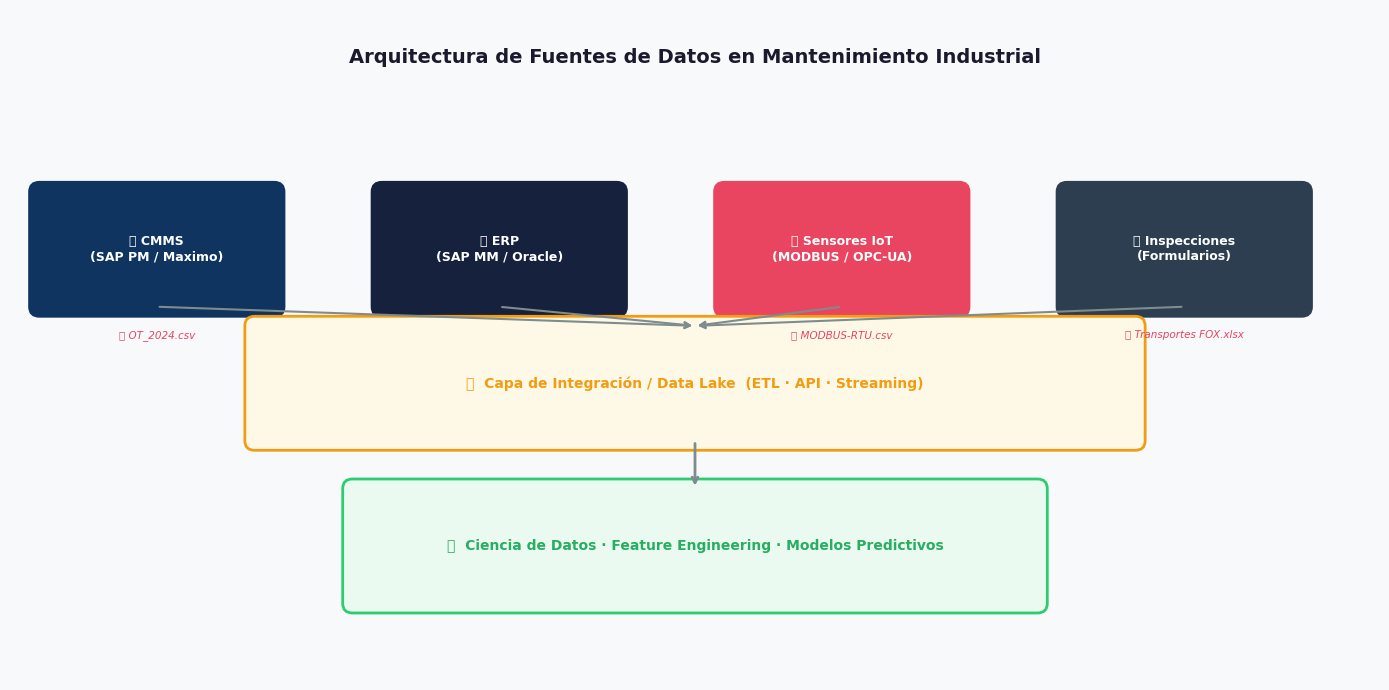


📌 Diagrama: flujo de datos desde las fuentes hasta el análisis predictivo.


In [4]:
# -------------------------------------------------------
# CELDA 2.1.A — Diagrama de arquitectura de fuentes de datos
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

ax.text(7, 6.5, 'Arquitectura de Fuentes de Datos en Mantenimiento Industrial',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#1a1a2e')

# Capa 1: Fuentes
fuentes = [
    (1.5, 4.5, '🏭 CMMS\n(SAP PM / Maximo)', '#0f3460'),
    (5.0, 4.5, '📦 ERP\n(SAP MM / Oracle)', '#16213e'),
    (8.5, 4.5, '📡 Sensores IoT\n(MODBUS / OPC-UA)', '#e94560'),
    (12.0, 4.5, '📋 Inspecciones\n(Formularios)', '#2c3e50'),
]
for x, y, txt, color in fuentes:
    rect = mpatches.FancyBboxPatch((x-1.2, y-0.6), 2.4, 1.2,
                                    boxstyle="round,pad=0.1", linewidth=2,
                                    edgecolor=color, facecolor=color)
    ax.add_patch(rect)
    ax.text(x, y, txt, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')

# Capa 2: Integración
rect_int = mpatches.FancyBboxPatch((2.5, 2.5), 9, 1.2,
                                    boxstyle="round,pad=0.1", linewidth=2,
                                    edgecolor='#f39c12', facecolor='#fef9e7')
ax.add_patch(rect_int)
ax.text(7, 3.1, '🔄  Capa de Integración / Data Lake  (ETL · API · Streaming)',
        ha='center', va='center', fontsize=10, fontweight='bold', color='#f39c12')

# Capa 3: Análisis
rect_ana = mpatches.FancyBboxPatch((3.5, 0.8), 7, 1.2,
                                    boxstyle="round,pad=0.1", linewidth=2,
                                    edgecolor='#2ecc71', facecolor='#eafaf1')
ax.add_patch(rect_ana)
ax.text(7, 1.4, '🧠  Ciencia de Datos · Feature Engineering · Modelos Predictivos',
        ha='center', va='center', fontsize=10, fontweight='bold', color='#27ae60')

# Flechas
for x in [1.5, 5.0, 8.5, 12.0]:
    ax.annotate('', xy=(7, 3.7), xytext=(x, 3.9),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))
ax.annotate('', xy=(7, 2.0), xytext=(7, 2.5),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))

# Etiquetas de datasets reales
for x, txt in [(1.5, 'OT_2024.csv'), (8.5, 'MODBUS-RTU.csv'), (12.0, 'Transportes FOX.xlsx')]:
    ax.text(x, 3.6, f'📂 {txt}', ha='center', va='center',
            fontsize=7.5, color='#e94560', style='italic')

plt.tight_layout()
plt.show()
print("\n📌 Diagrama: flujo de datos desde las fuentes hasta el análisis predictivo.")

---
## 🔍 Ejemplo Guiado 2.1 — Exploración inicial de un CMMS real

Vamos a cargar el dataset **OT_2024.csv**, que contiene órdenes de trabajo reales de un sistema CMMS.

In [5]:
# -------------------------------------------------------
# CELDA 2.1.B — Carga y exploración del CMMS (OT_2024)
# -------------------------------------------------------

# encoding='utf-8-sig' elimina el BOM (Byte Order Mark) de archivos Windows
df_ot = pd.read_csv(
    'OT_2024.csv',
    encoding='utf-8-sig',
    low_memory=False
)

print("=" * 60)
print("📋 INFORMACIÓN GENERAL DEL DATASET CMMS")
print("=" * 60)
print(f"  Filas (órdenes de trabajo) : {df_ot.shape[0]:,}")
print(f"  Columnas (campos)          : {df_ot.shape[1]}")
print(f"  Memoria utilizada          : {df_ot.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Mostrar primeras filas
print("\n📄 Primeras 3 órdenes de trabajo:")
df_ot.head(3)

📋 INFORMACIÓN GENERAL DEL DATASET CMMS
  Filas (órdenes de trabajo) : 1,048,575
  Columnas (campos)          : 39
  Memoria utilizada          : 1009.8 MB

📄 Primeras 3 órdenes de trabajo:


,item,Nº OT,Planta OT,Tipo Conexión,Planta,Objeto,Descripción Objeto,Fuente clase elemento,Estado,Tipo Objeto,...,Fecha de Primer Inicio,Descripción Trabajo,Desc. Trabajo,Nº Cliente,Nombre Cliente,Contrato,Línea,Última Actividad,Formulario de certificación de artículo,Progreso del trabajo (%)
0,1.0,90748.0,S100,EQUIPO,S100,51665,HELICOIDAL 1 PLANTA CONCRETERA,NaN,Terminado,MEC,...,25/12/2023,LUNES- DOMINGO: SE LUBRICA. JOAN YAHIR CEPEDA,NaN,NaN,NaN,NaN,NaN,45295.19413,False,100.0
1,2.0,90749.0,S100,EQUIPO,S100,51666,HELICOIDAL 2 PLANTA CONCRETERA,NaN,Terminado,MEC,...,25/12/2023,LUNES- DOMINGO: SE LUBRICA. JOAN YAHIR CEPEDA,NaN,NaN,NaN,NaN,NaN,45295.21235,False,100.0
2,3.0,90744.0,S100,EQUIPO,S100,56724,ESTACIONES DE BOMBEO,NaN,Terminado,PU,...,25/12/2023,LUNES: \r\nMARTES: LIMPIEZA PILETAS SUPERFICIE...,NaN,NaN,NaN,NaN,NaN,45295.22197,False,100.0


In [6]:
# -------------------------------------------------------
# CELDA 2.1.C — Identificar tipos de datos y columnas clave
# -------------------------------------------------------

cols_texto     = df_ot.select_dtypes(include='object').columns.tolist()
cols_numericas = df_ot.select_dtypes(include='number').columns.tolist()

print("=" * 60)
print("🔤 COLUMNAS DE TEXTO (categóricas / fechas):")
print("=" * 60)
for c in cols_texto[:12]:
    n_unicos = df_ot[c].nunique()
    print(f"  {c:<40} → {n_unicos:>6} valores únicos")

print("\n" + "=" * 60)
print("🔢 COLUMNAS NUMÉRICAS:")
print("=" * 60)
for c in cols_numericas:
    print(f"  {c:<40} → min={df_ot[c].min():.1f}  max={df_ot[c].max():.1f}")

🔤 COLUMNAS DE TEXTO (categóricas / fechas):
  Planta OT                                →      1 valores únicos
  Tipo Conexión                            →      1 valores únicos
  Planta                                   →      1 valores únicos
  Objeto                                   →    166 valores únicos
  Descripción Objeto                       →    159 valores únicos
  Fuente clase elemento                    →      1 valores únicos
  Estado                                   →      1 valores únicos
  Tipo Objeto                              →     19 valores únicos
  Descripción Tipo Objeto                  →     19 valores únicos
  Org. mant.                               →      4 valores únicos
  Directiva                                →    945 valores únicos
  Inicio Real                              →    242 valores únicos

🔢 COLUMNAS NUMÉRICAS:
  item                                     → min=1.0  max=4427.0
  Nº OT                                    → min=73469.0  max=15

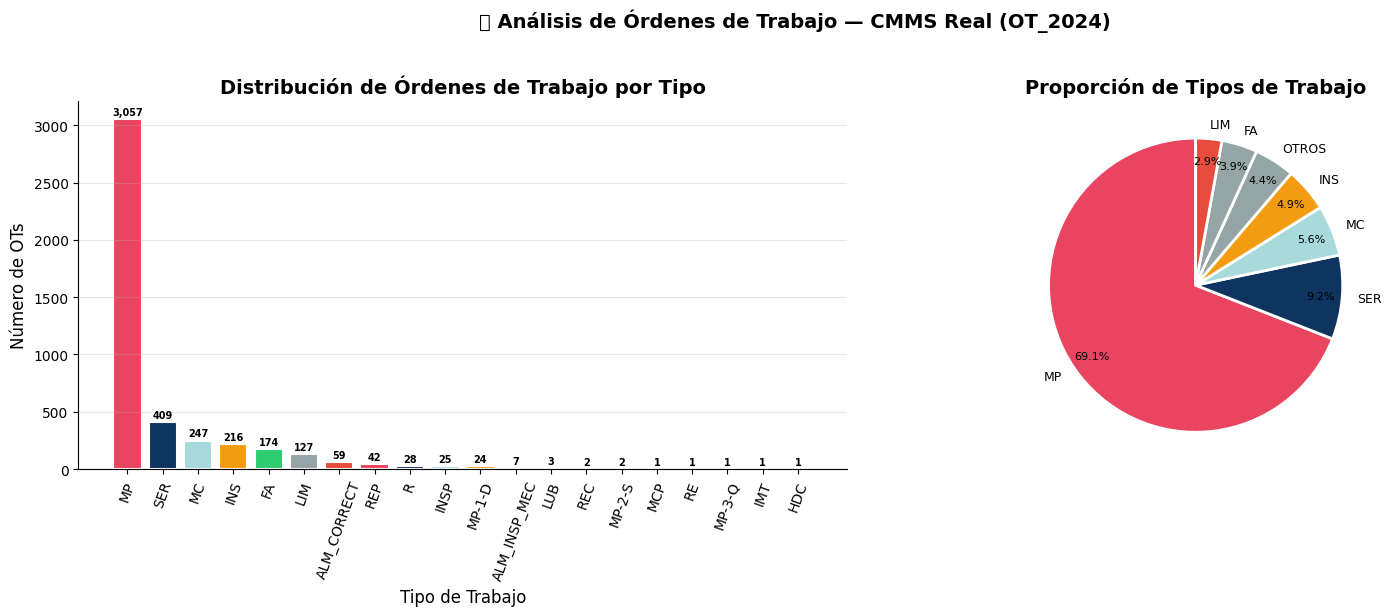


📋 Resumen por tipo de trabajo:
  MP    Mantenimiento Preventivo            →  3,057 OTs (69.1%)
  SER   Servicio                            →    409 OTs (9.2%)
  MC    Mantenimiento Correctivo            →    247 OTs (5.6%)
  INS   Inspección                          →    216 OTs (4.9%)
  FA    Falla / Avería                      →    174 OTs (3.9%)
  LIM   Otro                                →    127 OTs (2.9%)
  ALM_CORRECT Otro                                →     59 OTs (1.3%)
  REP   Otro                                →     42 OTs (0.9%)
  R     Otro                                →     28 OTs (0.6%)
  INSP  Otro                                →     25 OTs (0.6%)
  MP-1-D Otro                                →     24 OTs (0.5%)
  ALM_INSP_MEC Otro                                →      7 OTs (0.2%)
  LUB   Otro                                →      3 OTs (0.1%)
  REC   Otro                                →      2 OTs (0.0%)
  MP-2-S Otro                                →      2 OTs

In [7]:
# -------------------------------------------------------
# CELDA 2.1.D — Distribución de tipos de trabajo (CMMS)
# -------------------------------------------------------

conteo_tipo = df_ot['Tipo Trabajo'].value_counts().dropna()

descripciones = {
    'MP' : 'Mantenimiento Preventivo',
    'MC' : 'Mantenimiento Correctivo',
    'SER': 'Servicio',
    'INS': 'Inspección',
    'FA' : 'Falla / Avería',
    'MOD': 'Modificación',
    'PD' : 'Predictivo',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Increased figure width for better spacing
colores = [COLORS['primary'], COLORS['secondary'], COLORS['accent'],
           COLORS['warn'], COLORS['ok'], COLORS['neutral'], COLORS['danger']]

# Barras
bars = axes[0].bar(conteo_tipo.index, conteo_tipo.values,
                   color=colores[:len(conteo_tipo)], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Órdenes de Trabajo por Tipo', fontweight='bold')
axes[0].set_xlabel('Tipo de Trabajo')
axes[0].set_ylabel('Número de OTs')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=70) # Rotate x-axis labels - Removed ha='right'
for bar, val in zip(bars, conteo_tipo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, # Reduced offset from 50 to 20
                 f'{val:,}', ha='center', va='bottom', fontsize=7, fontweight='bold') # Reduced font size

# --- Modificaciones para el gráfico de pastel ---
# Calcular porcentajes y agrupar categorías pequeñas en 'OTROS'
pct_conteo_tipo = conteo_tipo / conteo_tipo.sum() * 100
umbral_otros = 2.0 # Agrupar categorías con menos del 2%

conteo_tipo_pie_data = conteo_tipo[pct_conteo_tipo >= umbral_otros].copy()
otros_sum = conteo_tipo[pct_conteo_tipo < umbral_otros].sum()

if otros_sum > 0:
    conteo_tipo_pie_data['OTROS'] = otros_sum

# Ordenar por valor para una mejor visualización en el pastel
conteo_tipo_pie_data = conteo_tipo_pie_data.sort_values(ascending=False)

# Asignar colores, asegurando que haya suficientes y que 'OTROS' tenga un color neutro
num_pie_categories = len(conteo_tipo_pie_data)
pie_colors = [colores[i % len(colores)] for i in range(num_pie_categories)]
# Si 'OTROS' está presente, asignarle el color neutro
if 'OTROS' in conteo_tipo_pie_data.index:
    otros_idx = conteo_tipo_pie_data.index.get_loc('OTROS')
    pie_colors[otros_idx] = COLORS['neutral']

# Pastel (actualizado)
wedges, texts, autotexts = axes[1].pie(conteo_tipo_pie_data.values, labels=conteo_tipo_pie_data.index,
            colors=pie_colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85, # Increased pctdistance slightly
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 9}) # Set font size for category labels
# Ajustar el tamaño de la fuente para las etiquetas de porcentaje
for autotext in autotexts:
    autotext.set_fontsize(8)

axes[1].set_title('Proporción de Tipos de Trabajo', fontweight='bold')

plt.suptitle('📊 Análisis de Órdenes de Trabajo — CMMS Real (OT_2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📋 Resumen por tipo de trabajo:")
for codigo, cantidad in conteo_tipo.items():
    desc = descripciones.get(codigo, 'Otro')
    pct  = cantidad / conteo_tipo.sum() * 100
    print(f"  {codigo:<5} {desc:<35} → {cantidad:>6,} OTs ({pct:.1f}%)")

---
## 💡 Interpretación de Resultados 2.1

**¿Qué ocurrió?**
Cargamos un CMMS real con más de 1 millón de registros de órdenes de trabajo. Identificamos:
- **Columnas de texto**: Estado, Tipo de Trabajo, Descripción del Objeto, Planta
- **Columnas numéricas**: Horas, Total Horas Hombre, Progreso
- **Columnas de fecha**: Inicio Real, Finalización Real, Inicio Planificado

**¿Por qué importa para mantenimiento predictivo?**
- El **tipo de trabajo** (MP vs MC) nos dice si el mantenimiento es reactivo o proactivo
- Las **fechas** permiten calcular tiempos entre fallas (MTBF) y tiempos de reparación (MTTR)
- El **objeto** identifica el equipo, que luego conectaremos con datos de sensores

> ⚠️ **Señal de alerta:** Si el porcentaje de MC (Correctivo) es alto, la planta opera de forma reactiva → hay oportunidad para mantenimiento predictivo.

---
## ✏️ Ejercicio 2.1 — Exploración del dataset de sensores MODBUS-RTU

Ahora es tu turno. Carga el archivo **MODBUS-RTU.csv** (datos de un analizador de energía eléctrica industrial) y responde las preguntas.

In [8]:
import pandas as pd

# -------------------------------------------------------
# EJERCICIO 2.1 — Exploración de datos de sensores
# -------------------------------------------------------
# Instrucciones:
# 1. Carga el archivo MODBUS-RTU.csv con parse_dates=['timestamp']
# 2. Muestra las dimensiones del dataset
# 3. Identifica cuántas columnas son numéricas
# 4. Muestra min, max y media de 'voltage_avg_V'
# 5. Muestra el rango temporal del dataset

# ========= COMPLETAR =========

# Paso 1: Cargar el archivo
df_modbus = pd.read_csv(
    'MODBUS-RTU.csv',
    parse_dates=['timestamp'], dayfirst=True


)

# Paso 2: Dimensiones
print(f"Filas: {df_modbus.shape[0]}  Columnas: {df_modbus.shape[1]}")

# Paso 3: Columnas numéricas
cols_numericas = df_modbus.select_dtypes(include='number').columns.tolist()
print(f"Columnas numéricas: {len(cols_numericas)}")

# Paso 4: Estadísticas de voltaje
print(f"Min voltage_avg_V: {df_modbus['voltage_avg_V'].min():.2f}")
print(f"Max voltage_avg_V: {df_modbus['voltage_avg_V'].max():.2f}")
print(f"Mean voltage_avg_V: {df_modbus['voltage_avg_V'].mean():.2f}")

# Paso 5: Rango temporal
min_timestamp = df_modbus['timestamp'].min()
max_timestamp = df_modbus['timestamp'].max()
temporal_range = max_timestamp - min_timestamp

print(f"Rango temporal: {min_timestamp} a {max_timestamp}")
print(f"Duración: {temporal_range.days} días y {temporal_range.seconds // 3600} horas")

Filas: 8920  Columnas: 316
Columnas numéricas: 315
Min voltage_avg_V: 125.54
Max voltage_avg_V: 129.61
Mean voltage_avg_V: 127.88
Rango temporal: 2024-08-01 00:00:00 a 2024-08-31 23:55:00
Duración: 30 días y 23 horas


---
## ⚡ Mini Reto 2.1

**Pregunta:** ¿Cuántas lecturas por día tiene el dataset MODBUS-RTU?

Pista: Si la frecuencia es cada 5 minutos, ¿cuántas lecturas hay en 24 horas?
Verifica tu respuesta calculando el número de lecturas del primer día del dataset.

Cálculo teórico de lecturas por día (cada 5 minutos): 288 lecturas
Lecturas reales del primer día (2024-08-01): 288 lecturas


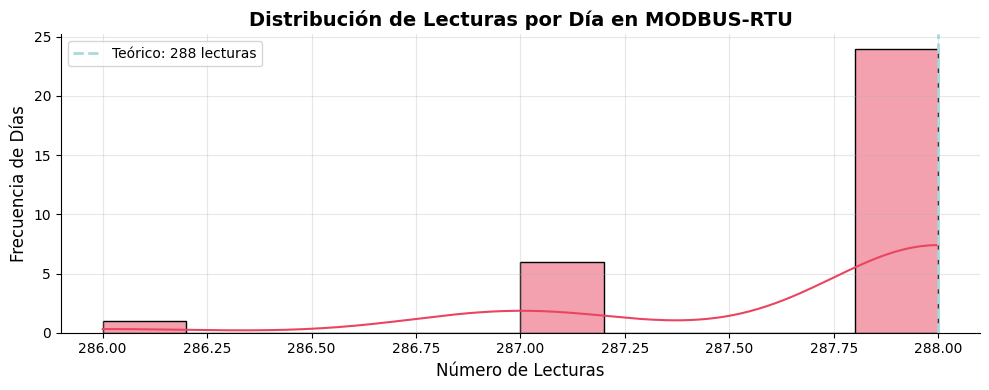

💡 La mayoría de los días tienen 288 lecturas, lo que confirma la frecuencia de 5 minutos.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta de colores corporativa del curso
COLORS = {
    'primary'   : '#e94560',
    'secondary' : '#0f3460',
    'accent'    : '#a8dadc',
    'ok'        : '#2ecc71',
    'warn'      : '#f39c12',
    'danger'    : '#e74c3c',
    'neutral'   : '#95a5a6',
}

# -------------------------------------------------------
# MINI RETO 2.1 — Lecturas por día
# -------------------------------------------------------

# Cálculo teórico: 60 min / 5 min * 24 horas
lecturas_por_hora = 60 / 5
lecturas_teoricas_dia = lecturas_por_hora * 24
print(f"Cálculo teórico de lecturas por día (cada 5 minutos): {int(lecturas_teoricas_dia)} lecturas")

# Verificación con datos reales
# Obtener el primer día del dataset
primer_dia = df_modbus['timestamp'].min().date()
lecturas_primer_dia = df_modbus[df_modbus['timestamp'].dt.date == primer_dia].shape[0]
print(f"Lecturas reales del primer día ({primer_dia}): {lecturas_primer_dia} lecturas")

# Visualización
fig, ax = plt.subplots(figsize=(10, 4))
# Obtener el recuento de lecturas por día
lecturas_por_dia = df_modbus.groupby(df_modbus['timestamp'].dt.date).size()

sns.histplot(lecturas_por_dia, bins=10, kde=True, color=COLORS['primary'], ax=ax)
ax.axvline(lecturas_teoricas_dia, color=COLORS['accent'], linestyle='--', linewidth=2, label=f'Teórico: {int(lecturas_teoricas_dia)} lecturas')
ax.set_title('Distribución de Lecturas por Día en MODBUS-RTU', fontweight='bold')
ax.set_xlabel('Número de Lecturas')
ax.set_ylabel('Frecuencia de Días')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"💡 La mayoría de los días tienen {int(lecturas_teoricas_dia)} lecturas, lo que confirma la frecuencia de 5 minutos.")

---
## 🧠 Quiz 2.1 — Fuentes de Datos

In [10]:
# -------------------------------------------------------
# QUIZ 2.1 — Cuestionario interactivo
# -------------------------------------------------------

def quiz_21():
    score = 0
    total = 4

    print("=" * 60)
    print("🧠 QUIZ 2.1 — Fuentes de Datos en Mantenimiento")
    print("=" * 60)

    # Pregunta 1
    print("\n1️⃣  ¿Qué significa CMMS?")
    print("   a) Computerized Maintenance Management System")
    print("   b) Central Machine Monitoring Software")
    print("   c) Continuous Measurement and Monitoring System")
    r1 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r1 == 'a':
        print("   ✅ ¡Correcto! CMMS = Sistema de Gestión de Mantenimiento Computarizado")
        score += 1
    else:
        print("   ❌ La respuesta es 'a': Computerized Maintenance Management System")

    # Pregunta 2 (basada en datos reales)
    tipo_mas_comun = df_ot['Tipo Trabajo'].value_counts().idxmax()
    n_mas_comun    = df_ot['Tipo Trabajo'].value_counts().max()
    print(f"\n2️⃣  Según el dataset OT_2024, ¿cuál es el tipo de trabajo más frecuente?")
    print(f"   a) MC (Correctivo)")
    print(f"   b) MP (Preventivo)")
    print(f"   c) INS (Inspección)")
    r2 = input("   Tu respuesta (a/b/c): ").strip().lower()
    respuesta_correcta = {'MP': 'b', 'MC': 'a', 'INS': 'c'}.get(tipo_mas_comun, 'b')
    if r2 == respuesta_correcta:
        print(f"   ✅ ¡Correcto! '{tipo_mas_comun}' con {n_mas_comun:,} órdenes")
        score += 1
    else:
        print(f"   ❌ La respuesta correcta es '{respuesta_correcta}': {tipo_mas_comun} con {n_mas_comun:,} OTs")

    # Pregunta 3
    freq_modbus = 5
    lect_semana = 60 // freq_modbus * 24 * 7
    print(f"\n3️⃣  El sensor MODBUS-RTU registra datos cada {freq_modbus} minutos.")
    print(f"   ¿Cuántas lecturas genera en una semana?")
    print(f"   a) {lect_semana}")
    print(f"   b) {60 // freq_modbus * 24}")
    print(f"   c) {60 // freq_modbus * 7}")
    r3 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r3 == 'a':
        print(f"   ✅ ¡Correcto! {lect_semana} lecturas por semana")
        score += 1
    else:
        print(f"   ❌ La respuesta es 'a': {lect_semana} lecturas/semana")

    # Pregunta 4
    print("\n4️⃣  ¿Cuál es la principal ventaja de los sensores IoT sobre el CMMS?")
    print("   a) Tienen mayor precisión en costos de mantenimiento")
    print("   b) Capturan datos en tiempo real de variables físicas del equipo")
    print("   c) Almacenan el historial de órdenes de trabajo")
    r4 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r4 == 'b':
        print("   ✅ ¡Correcto! Los sensores capturan variables físicas en tiempo real")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': captura en tiempo real de variables físicas")

    print("\n" + "=" * 60)
    print(f"📊 RESULTADO: {score}/{total} respuestas correctas")
    if score == total:
        print("🏆 ¡Excelente! Dominas las fuentes de datos en mantenimiento")
    elif score >= 2:
        print("👍 Buen trabajo. Repasa los conceptos de CMMS y sensores")
    else:
        print("📚 Revisa la sección de fuentes de datos antes de continuar")
    print("=" * 60)

quiz_21()

🧠 QUIZ 2.1 — Fuentes de Datos en Mantenimiento

1️⃣  ¿Qué significa CMMS?
   a) Computerized Maintenance Management System
   b) Central Machine Monitoring Software
   c) Continuous Measurement and Monitoring System


KeyboardInterrupt: Interrupted by user

---
# 📌 SUBTEMA 2.2 — Importación y Estructuración de Datos

---

## 📖 Concepto

### ¿Qué es la importación y estructuración de datos?

**Importar** datos significa leerlos desde su fuente original y cargarlos en memoria para analizarlos.

**Estructurar** significa organizarlos en un formato tabular limpio donde:
- Cada **fila** es una observación (una lectura, una OT, un evento)
- Cada **columna** es una variable (voltaje, temperatura, tipo de falla)
- Los **tipos de datos** son correctos (fechas como datetime, números como float)

### ¿Por qué es importante?

Un dato mal estructurado genera errores silenciosos:
- Una fecha guardada como texto no permite calcular duraciones
- Un número guardado como texto no permite calcular promedios
- Columnas con nombres inconsistentes dificultan el análisis

### Formatos comunes en mantenimiento industrial

| Formato | Uso típico | Función pandas |
|---------|-----------|----------------|
| CSV | Exportaciones de CMMS, sensores | `pd.read_csv()` |
| Excel (.xlsx) | Reportes manuales, inspecciones | `pd.read_excel()` |
| JSON | APIs industriales, IoT | `pd.read_json()` |
| Parquet | Big data, historiadores | `pd.read_parquet()` |

> **Regla de oro:** Verifica siempre el tipo de dato de cada columna antes de analizar.

In [11]:
# -------------------------------------------------------
# CELDA 2.2.A — Importación correcta de múltiples fuentes
# -------------------------------------------------------

print("=" * 60)
print("📂 CARGANDO TODOS LOS DATASETS DEL MÓDULO")
print("=" * 60)

# --- 1. CMMS: Órdenes de Trabajo ---
df_ot = pd.read_csv('OT_2024.csv', encoding='utf-8-sig', low_memory=False)
# Convertir columnas de fecha (formato DD/MM/YYYY)
cols_fecha_ot = ['Inicio Real', 'Finalización Real',
                 'Inicio Planificado', 'Finalización Planificada', 'Fecha Registro']
for col in cols_fecha_ot:
    if col in df_ot.columns:
        df_ot[col] = pd.to_datetime(df_ot[col], dayfirst=True, errors='coerce')
print(f"  ✅ OT_2024          → {df_ot.shape[0]:>8,} filas × {df_ot.shape[1]} cols")

# --- 2. Sensores: MODBUS-RTU ---
df_modbus = pd.read_csv('MODBUS-RTU.csv', parse_dates=['timestamp'], dayfirst=True)
print(f"  ✅ MODBUS-RTU       → {df_modbus.shape[0]:>8,} filas × {df_modbus.shape[1]} cols")

# --- 3. Inspección: Transportes FOX ---
df_fox = pd.read_excel('TRANSPORTES FOX .xlsx', engine='openpyxl')
df_fox = df_fox.dropna(how='all')   # Eliminar filas completamente vacías
print(f"  ✅ Transportes FOX  → {df_fox.shape[0]:>8,} filas × {df_fox.shape[1]} cols")

# --- 4. Rodamientos: Healthy ---
df_healthy = pd.read_csv('Healthy-bearing.csv', sep=';', decimal=',')
print(f"  ✅ Healthy-bearing  → {df_healthy.shape[0]:>8,} filas × {df_healthy.shape[1]} cols")

# --- 5. Rodamientos: Faulty ---
df_faulty = pd.read_csv('Faulty-bearing.csv', sep=';', decimal=',')
print(f"  ✅ Faulty-bearing   → {df_faulty.shape[0]:>8,} filas × {df_faulty.shape[1]} cols")

# --- 6. Features de vibración (CWRU) ---
df_features = pd.read_csv('feature_time_48k_2048_load_1.csv')
print(f"  ✅ feature_time     → {df_features.shape[0]:>8,} filas × {df_features.shape[1]} cols")

# --- 7. APS Failure (sensores de camiones Scania) ---
df_aps = pd.read_csv('aps_failure_test_set_streamlit.csv')
df_aps = df_aps.replace('na', np.nan)   # 'na' como string → NaN real
for col in df_aps.columns:
    df_aps[col] = pd.to_numeric(df_aps[col], errors='coerce')
print(f"  ✅ APS Failure      → {df_aps.shape[0]:>8,} filas × {df_aps.shape[1]} cols")

print("\n✅ Todos los datasets cargados correctamente")

📂 CARGANDO TODOS LOS DATASETS DEL MÓDULO
  ✅ OT_2024          → 1,048,575 filas × 39 cols
  ✅ MODBUS-RTU       →    8,920 filas × 316 cols
  ✅ Transportes FOX  →      256 filas × 26 cols
  ✅ Healthy-bearing  →      999 filas × 2 cols
  ✅ Faulty-bearing   →      999 filas × 2 cols
  ✅ feature_time     →    2,300 filas × 10 cols
  ✅ APS Failure      →   16,000 filas × 170 cols

✅ Todos los datasets cargados correctamente


In [12]:
# -------------------------------------------------------
# CELDA 2.2.B — Verificación y corrección de tipos de datos
# -------------------------------------------------------

print("=" * 60)
print("🔧 VERIFICACIÓN DE TIPOS DE DATOS")
print("=" * 60)

def reporte_tipos(df, nombre, cols_muestra=None):
    """Muestra un resumen de tipos de datos de un DataFrame"""
    if cols_muestra is None:
        cols_muestra = df.columns[:8]
    print(f"\n📋 {nombre}:")
    for col in cols_muestra:
        if col in df.columns:
            dtype    = str(df[col].dtype)
            n_null   = df[col].isnull().sum()
            pct_null = n_null / len(df) * 100
            print(f"  {col:<38} {dtype:<12} nulls={n_null:>6} ({pct_null:.1f}%)")

reporte_tipos(df_ot, "OT_2024 (CMMS)",
              ['Inicio Real', 'Finalización Real', 'Tipo Trabajo',
               'Total Horas Hombre', 'Progreso del trabajo (%)'])

reporte_tipos(df_modbus, "MODBUS-RTU (Sensores)",
              ['timestamp', 'voltage_avg_V', 'current_avg_A',
               'frequency_Hz', 'active_power_total_W'])

reporte_tipos(df_healthy, "Healthy-bearing", ['Case_No', 'Measurement'])
reporte_tipos(df_faulty,  "Faulty-bearing",  ['Case_No', 'Measurements'])

🔧 VERIFICACIÓN DE TIPOS DE DATOS

📋 OT_2024 (CMMS):
  Inicio Real                            datetime64[ns] nulls=1044148 (99.6%)
  Finalización Real                      datetime64[ns] nulls=1044148 (99.6%)
  Tipo Trabajo                           object       nulls=1044148 (99.6%)
  Total Horas Hombre                     float64      nulls=1044146 (99.6%)
  Progreso del trabajo (%)               float64      nulls=1044148 (99.6%)

📋 MODBUS-RTU (Sensores):
  timestamp                              datetime64[ns] nulls=     0 (0.0%)
  voltage_avg_V                          float64      nulls=     0 (0.0%)
  current_avg_A                          float64      nulls=     0 (0.0%)
  frequency_Hz                           float64      nulls=     0 (0.0%)
  active_power_total_W                   int64        nulls=     0 (0.0%)

📋 Healthy-bearing:
  Case_No                                int64        nulls=     0 (0.0%)
  Measurement                            float64      nulls=     0 (0.0%

🔩 DATASET COMBINADO DE RODAMIENTOS
  Total de muestras : 1,998
  Columnas          : ['Case_No', 'Measurement', 'condicion']
  Distribución:
condicion
Saludable     999
Defectuoso    999


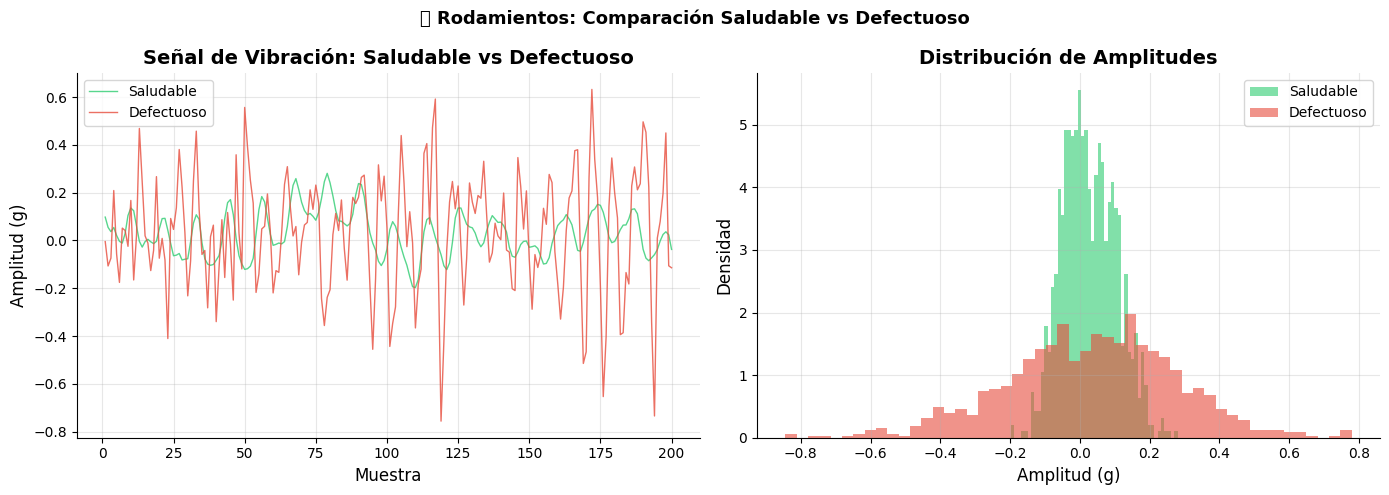


💡 El rodamiento defectuoso tiene mayor amplitud y variabilidad → señal de falla


In [13]:
# -------------------------------------------------------
# CELDA 2.2.C — Estructuración: combinar datasets de rodamientos
# -------------------------------------------------------

# Agregar etiqueta de condición a cada dataset
df_healthy['condicion'] = 'Saludable'
df_faulty['condicion']  = 'Defectuoso'

# Renombrar columna para que coincidan
df_faulty = df_faulty.rename(columns={'Measurements': 'Measurement'})

# Combinar en un solo DataFrame estructurado
df_rodamientos = pd.concat([df_healthy, df_faulty], ignore_index=True)

print("=" * 55)
print("🔩 DATASET COMBINADO DE RODAMIENTOS")
print("=" * 55)
print(f"  Total de muestras : {len(df_rodamientos):,}")
print(f"  Columnas          : {list(df_rodamientos.columns)}")
print(f"  Distribución:")
print(df_rodamientos['condicion'].value_counts().to_string())

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Señal temporal (primeras 200 muestras de cada condición)
for cond, color in [('Saludable', COLORS['ok']), ('Defectuoso', COLORS['danger'])]:
    subset = df_rodamientos[df_rodamientos['condicion'] == cond]
    axes[0].plot(subset['Case_No'].values[:200],
                 subset['Measurement'].values[:200],
                 label=cond, color=color, alpha=0.8, linewidth=1)
axes[0].set_title('Señal de Vibración: Saludable vs Defectuoso', fontweight='bold')
axes[0].set_xlabel('Muestra')
axes[0].set_ylabel('Amplitud (g)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución de amplitudes
for cond, color in [('Saludable', COLORS['ok']), ('Defectuoso', COLORS['danger'])]:
    subset = df_rodamientos[df_rodamientos['condicion'] == cond]['Measurement']
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=cond, density=True)
axes[1].set_title('Distribución de Amplitudes', fontweight='bold')
axes[1].set_xlabel('Amplitud (g)')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('🔩 Rodamientos: Comparación Saludable vs Defectuoso',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 El rodamiento defectuoso tiene mayor amplitud y variabilidad → señal de falla")

---
## 💡 Interpretación de Resultados 2.2

**¿Qué ocurrió?**
- Cargamos 7 datasets de diferentes fuentes con diferentes formatos
- Corregimos tipos de datos: fechas como `datetime`, números como `float`
- Combinamos los datasets de rodamientos en una estructura unificada

**¿Por qué importa?**
- El rodamiento **defectuoso** muestra amplitudes mucho mayores (hasta ±0.84 g vs ±0.28 g en el saludable)
- Esta diferencia es la base del mantenimiento predictivo por vibración
- Sin una estructura correcta, no podríamos comparar las señales

**Regla de oro:** Antes de analizar, verifica que cada columna tenga el tipo de dato correcto.

---
## ✏️ Ejercicio 2.2 — Estructuración del dataset APS Failure

El dataset **APS Failure** contiene datos de sensores de camiones Scania. Tenía valores `'na'` (texto) en lugar de valores nulos reales. Tu tarea es analizar su estructura.

Columnas con al menos un nulo: 169
Porcentaje total de datos faltantes: 8.41%
Top 5 columnas con más nulos:
br_000    13129
bq_000    12981
bp_000    12721
bo_000    12376
ab_000    12363
dtype: int64


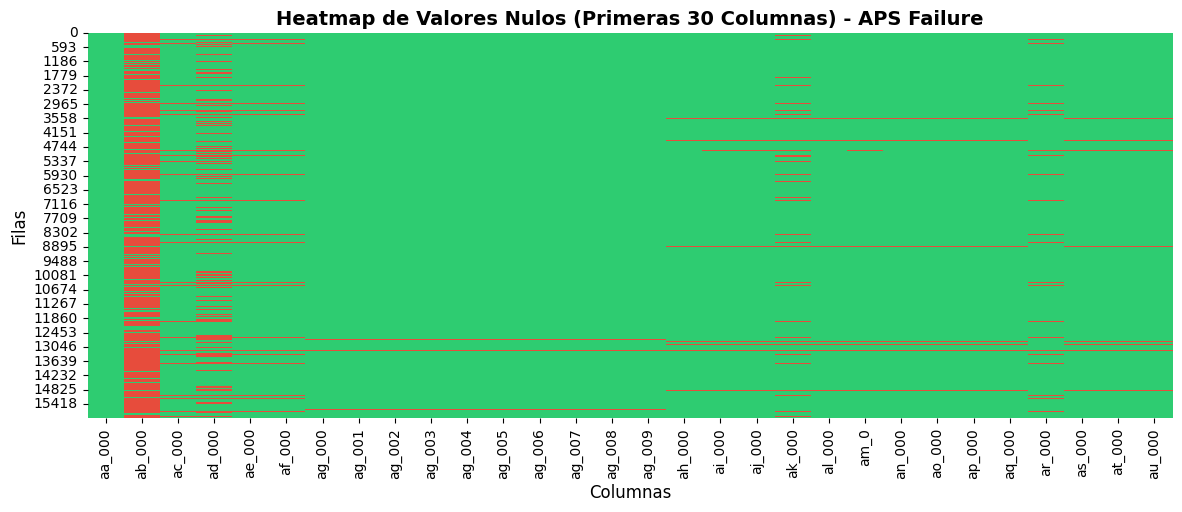

In [14]:
# -------------------------------------------------------
# EJERCICIO 2.2 — Análisis de estructura del APS Failure
# -------------------------------------------------------
# Instrucciones:
# 1. Cuenta cuántas columnas tienen al menos un valor nulo
# 2. Calcula el porcentaje total de datos faltantes
# 3. Identifica las 5 columnas con más valores nulos
# 4. Muestra un heatmap de nulos (primeras 30 columnas)

# ========= COMPLETAR =========

# Paso 1: Columnas con nulos
cols_con_nulos = df_aps.isnull().any().sum()   # ← Usa .isnull().any()
print(f"Columnas con al menos un nulo: {cols_con_nulos}")

# Paso 2: Porcentaje total de datos faltantes
pct_total = (df_aps.isnull().sum().sum() / (df_aps.shape[0] * df_aps.shape[1])) * 100
print(f"Porcentaje total de datos faltantes: {pct_total:.2f}%")

# Paso 3: Top 5 columnas con más nulos
top5_nulos = df_aps.isnull().sum().nlargest(5)
print("Top 5 columnas con más nulos:")
print(top5_nulos)

# Paso 4: Heatmap de nulos (primeras 30 columnas)
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_aps.iloc[:, :30].isnull(), cbar=False, cmap=['#2ecc71', '#e74c3c'], ax=ax)
plt.title('Heatmap de Valores Nulos (Primeras 30 Columnas) - APS Failure', fontweight='bold')
plt.xlabel('Columnas')
plt.ylabel('Filas')
plt.show()

---
## ⚡ Mini Reto 2.2

**Desafío:** En el dataset de Transportes FOX, las filas alternas están vacías (filas de separación del Excel original).

1. ¿Cuántas filas válidas (no vacías) tiene el dataset?
2. ¿Cuántos vehículos únicos hay?
3. ¿Cuántos neumáticos están en condición peligrosa?

In [15]:
import pandas as pd

# -------------------------------------------------------
# MINI RETO 2.2 — Análisis de Transportes FOX
# -------------------------------------------------------

# Filtrar solo filas con datos válidos (donde 'NO. VEHICULO' no es nulo)
df_fox_limpio = df_fox.dropna(subset=['NO. VEHICULO']).copy()

# 1. ¿Cuántas filas válidas (no vacías) tiene el dataset?
num_filas_validas = len(df_fox_limpio)
print(f"1. Filas válidas (no vacías) en el dataset: {num_filas_validas}")

# 2. ¿Cuántos vehículos únicos hay?
num_vehiculos_unicos = df_fox_limpio['NO. VEHICULO'].nunique()
print(f"2. Vehículos únicos en el dataset: {num_vehiculos_unicos}")

# --- Diagnosis: The column 'ESTADO' does not exist. Let's inspect the columns. ---
print("\n--- Diagnosis de error ---")
print("Columnas disponibles en df_fox_limpio:")
print(df_fox_limpio.columns.tolist())
print("\nPor favor, verifica la columna correcta que contiene la información de la condición del neumático. Si existe, reemplaza 'ESTADO' con el nombre correcto.")

# 3. ¿Cuántos neumáticos están en condición peligrosa?
# Asumimos que la columna 'CONDICIÓN PELIGROSA' contiene información sobre la condición del neumático.
# Buscamos la palabra 'PELIGROSA' o similar en esta columna (ignorando mayúsculas/minúsculas).
num_neumaticos_peligrosos = df_fox_limpio[
    df_fox_limpio['CONDICIÓN PELIGROSA'].astype(str).str.contains('PELIGROSA', case=False, na=False)
].shape[0]
print(f"3. Neumáticos en condición peligrosa: {num_neumaticos_peligrosos}")

1. Filas válidas (no vacías) en el dataset: 128
2. Vehículos únicos en el dataset: 15

--- Diagnosis de error ---
Columnas disponibles en df_fox_limpio:
['#', 'NO. VEHICULO', 'TIPO', 'POS', 'MARCA', 'MODELO', 'MEDIDA', 'NO. ECO', 'DOT', 'PISO', 'PSI', 'DESGASTE', '[1]', '[2]', '[3]', '[4]', 'FDELTA', 'MM', 'FOTO 1', 'FOTO 2', 'FOTO 3', 'FOTO 4', 'VIGÍA', 'CONDICIÓN PELIGROSA', 'OBSERVACIONES', 'COMENTARIOS']

Por favor, verifica la columna correcta que contiene la información de la condición del neumático. Si existe, reemplaza 'ESTADO' con el nombre correcto.
3. Neumáticos en condición peligrosa: 0


---
# 📌 SUBTEMA 2.3 — Limpieza de Datos

---

## 📖 Concepto

### ¿Qué es la limpieza de datos?

La limpieza de datos es el proceso de **detectar y corregir** problemas en los datos antes de analizarlos. En mantenimiento industrial, los datos sucios son la norma, no la excepción.

### Los tres problemas más comunes en datos industriales

#### 🔴 1. Outliers (Valores Atípicos)
Lecturas que se alejan significativamente del comportamiento normal.
- **Causa:** Pico de voltaje, golpe mecánico, error de sensor
- **Riesgo:** Distorsionan promedios y modelos predictivos
- **Detección:** IQR (Rango Intercuartílico), Z-score, visualización

#### 🟡 2. Valores Faltantes (Missing Values)
Datos que no fueron registrados.
- **Causa:** Sensor desconectado, falla de comunicación, campo no obligatorio en CMMS
- **Riesgo:** Algoritmos que no aceptan NaN fallan silenciosamente
- **Solución:** Imputación (media, mediana, interpolación, forward fill)

#### 🟠 3. Stuck Values (Valores Congelados)
El sensor reporta el mismo valor repetidamente cuando debería variar.
- **Causa:** Sensor bloqueado, cable cortado, falla de transductor
- **Riesgo:** Parece que el equipo está bien cuando en realidad el sensor falló
- **Detección:** Varianza en ventanas de tiempo

> ⚠️ **Regla de oro:** Un sensor congelado es más peligroso que un outlier. Los outliers son visibles; los stuck values parecen datos normales.

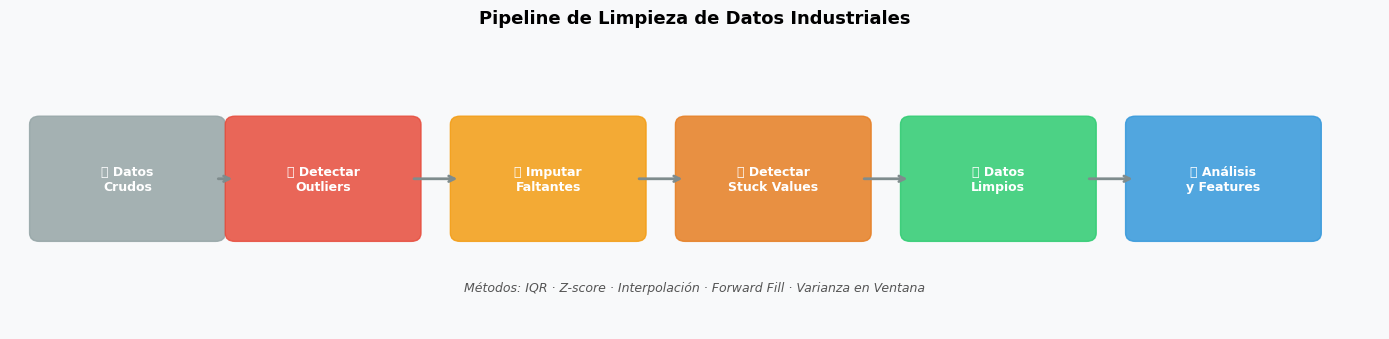

In [16]:
# -------------------------------------------------------
# CELDA 2.3.A — Diagrama del pipeline de limpieza
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3.5)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

pasos = [
    (1.2, 1.8, '📥 Datos\nCrudos',         '#95a5a6'),
    (3.2, 1.8, '🔍 Detectar\nOutliers',    '#e74c3c'),
    (5.5, 1.8, '🔧 Imputar\nFaltantes',    '#f39c12'),
    (7.8, 1.8, '📡 Detectar\nStuck Values','#e67e22'),
    (10.1,1.8, '✅ Datos\nLimpios',         '#2ecc71'),
    (12.4,1.8, '📊 Análisis\ny Features',  '#3498db'),
]

for i, (x, y, txt, color) in enumerate(pasos):
    rect = mpatches.FancyBboxPatch((x-0.9, y-0.65), 1.8, 1.3,
                                    boxstyle="round,pad=0.1",
                                    edgecolor=color, facecolor=color, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, y, txt, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')
    if i < len(pasos) - 1:
        ax.annotate('', xy=(pasos[i+1][0]-0.9, 1.8), xytext=(x+0.9, 1.8),
                    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))

ax.text(7, 0.5, 'Métodos: IQR · Z-score · Interpolación · Forward Fill · Varianza en Ventana',
        ha='center', va='center', fontsize=9, color='#555', style='italic')
ax.set_title('Pipeline de Limpieza de Datos Industriales', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## 🔍 Ejemplo Guiado 2.3.1 — Detección y tratamiento de Outliers con IQR

In [17]:
# -------------------------------------------------------
# CELDA 2.3.B — Detección de outliers con IQR
# -------------------------------------------------------

# Trabajamos con la corriente promedio del sensor MODBUS-RTU
serie = df_modbus['current_avg_A'].copy()

print("=" * 55)
print("⚡ ANÁLISIS DE OUTLIERS — Corriente Promedio (A)")
print("=" * 55)
print(f"  Registros totales : {len(serie):,}")
print(f"  Media             : {serie.mean():.2f} A")
print(f"  Mediana           : {serie.median():.2f} A")
print(f"  Desv. estándar    : {serie.std():.2f} A")
print(f"  Mínimo            : {serie.min():.2f} A")
print(f"  Máximo            : {serie.max():.2f} A")

# --- Método IQR (Rango Intercuartílico) ---
# El IQR es robusto: no se ve afectado por los propios outliers
Q1  = serie.quantile(0.25)   # Percentil 25
Q3  = serie.quantile(0.75)   # Percentil 75
IQR = Q3 - Q1                # Rango intercuartílico

# Límites de detección (regla de Tukey: 1.5 × IQR)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\n  Q1 (P25)          : {Q1:.2f} A")
print(f"  Q3 (P75)          : {Q3:.2f} A")
print(f"  IQR               : {IQR:.2f} A")
print(f"  Límite inferior   : {limite_inferior:.2f} A")
print(f"  Límite superior   : {limite_superior:.2f} A")

# Identificar outliers
mascara_outlier = (serie < limite_inferior) | (serie > limite_superior)
n_outliers      = mascara_outlier.sum()
print(f"\n  Outliers detectados: {n_outliers} ({n_outliers/len(serie)*100:.2f}%)")

⚡ ANÁLISIS DE OUTLIERS — Corriente Promedio (A)
  Registros totales : 8,920
  Media             : 109.71 A
  Mediana           : 101.54 A
  Desv. estándar    : 30.70 A
  Mínimo            : 63.13 A
  Máximo            : 224.53 A

  Q1 (P25)          : 85.89 A
  Q3 (P75)          : 122.87 A
  IQR               : 36.98 A
  Límite inferior   : 30.42 A
  Límite superior   : 178.33 A

  Outliers detectados: 453 (5.08%)


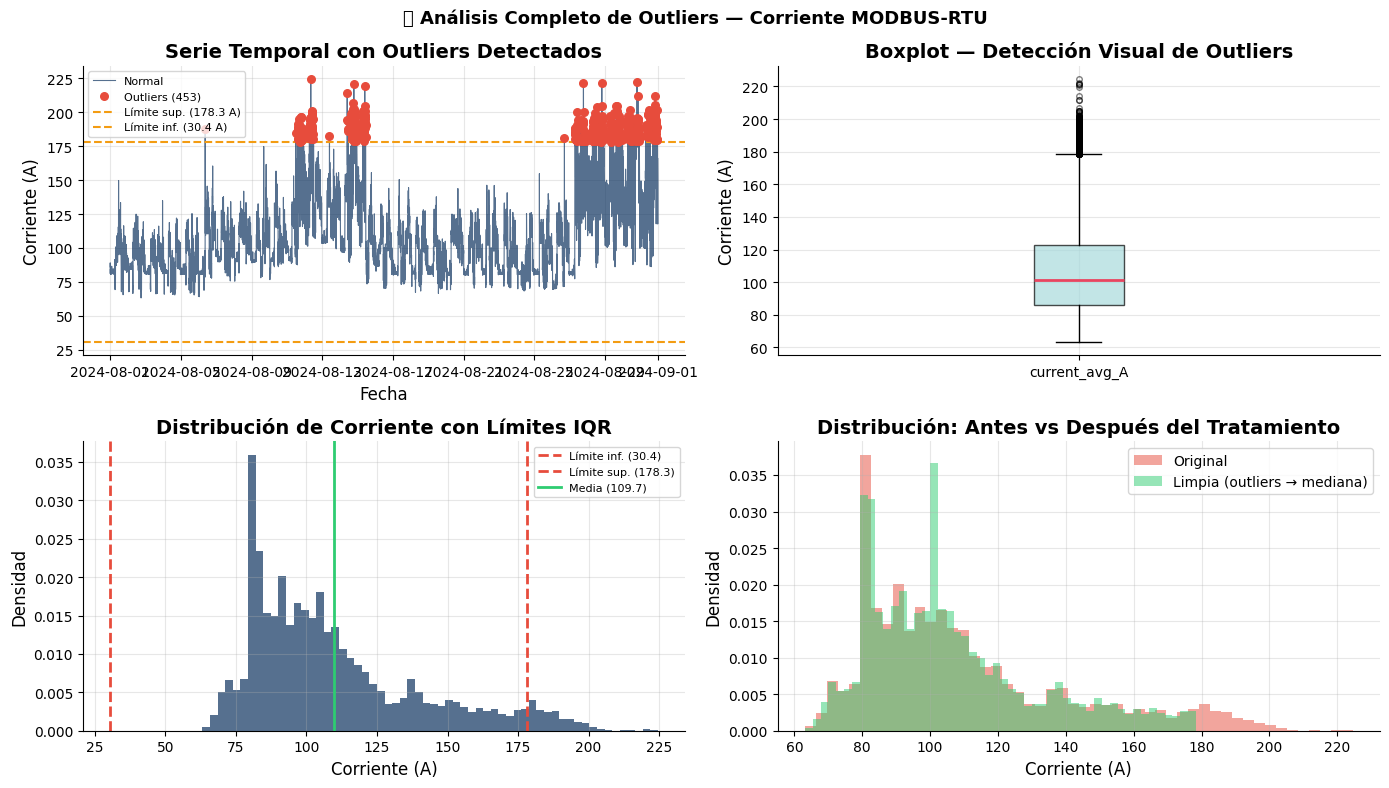

In [18]:
# -------------------------------------------------------
# CELDA 2.3.C — Visualización completa de outliers
# -------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Serie temporal con outliers marcados
ax = axes[0, 0]
ax.plot(df_modbus['timestamp'], serie,
        color=COLORS['secondary'], linewidth=0.8, alpha=0.7, label='Normal')
ax.scatter(df_modbus['timestamp'][mascara_outlier],
           serie[mascara_outlier],
           color=COLORS['danger'], s=30, zorder=5, label=f'Outliers ({n_outliers})')
ax.axhline(limite_superior, color=COLORS['warn'], linestyle='--', linewidth=1.5,
           label=f'Límite sup. ({limite_superior:.1f} A)')
ax.axhline(limite_inferior, color=COLORS['warn'], linestyle='--', linewidth=1.5,
           label=f'Límite inf. ({limite_inferior:.1f} A)')
ax.set_title('Serie Temporal con Outliers Detectados', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Corriente (A)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Boxplot
ax = axes[0, 1]
ax.boxplot(serie.dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor=COLORS['accent'], alpha=0.7),
           medianprops=dict(color=COLORS['primary'], linewidth=2),
           flierprops=dict(marker='o', color=COLORS['danger'], markersize=4, alpha=0.5))
ax.set_title('Boxplot — Detección Visual de Outliers', fontweight='bold')
ax.set_ylabel('Corriente (A)')
ax.set_xticklabels(['current_avg_A'])
ax.grid(True, alpha=0.3)

# 3. Histograma con límites
ax = axes[1, 0]
ax.hist(serie.dropna(), bins=60, color=COLORS['secondary'], alpha=0.7, density=True)
ax.axvline(limite_inferior, color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'Límite inf. ({limite_inferior:.1f})')
ax.axvline(limite_superior, color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'Límite sup. ({limite_superior:.1f})')
ax.axvline(serie.mean(), color=COLORS['ok'], linestyle='-', linewidth=2,
           label=f'Media ({serie.mean():.1f})')
ax.set_title('Distribución de Corriente con Límites IQR', fontweight='bold')
ax.set_xlabel('Corriente (A)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Comparación antes/después
ax = axes[1, 1]
serie_limpia = serie.copy()
serie_limpia[mascara_outlier] = serie.median()   # Reemplazar por mediana
ax.hist(serie.dropna(), bins=50, alpha=0.5, color=COLORS['danger'],
        density=True, label='Original')
ax.hist(serie_limpia.dropna(), bins=50, alpha=0.5, color=COLORS['ok'],
        density=True, label='Limpia (outliers → mediana)')
ax.set_title('Distribución: Antes vs Después del Tratamiento', fontweight='bold')
ax.set_xlabel('Corriente (A)')
ax.set_ylabel('Densidad')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('🔍 Análisis Completo de Outliers — Corriente MODBUS-RTU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔍 Ejemplo Guiado 2.3.2 — Imputación de Valores Faltantes

🔧 IMPUTACIÓN DE VALORES FALTANTES — ab_000
  Total registros   : 16,000
  Valores nulos     : 12,363
  % faltante        : 77.3%

  Estrategia 1 — Media    : 0.77
  Estrategia 2 — Mediana  : 0.00
  Estrategia 3 — Forward Fill: propaga el último valor válido
  Estrategia 4 — Interpolación lineal: estima entre vecinos


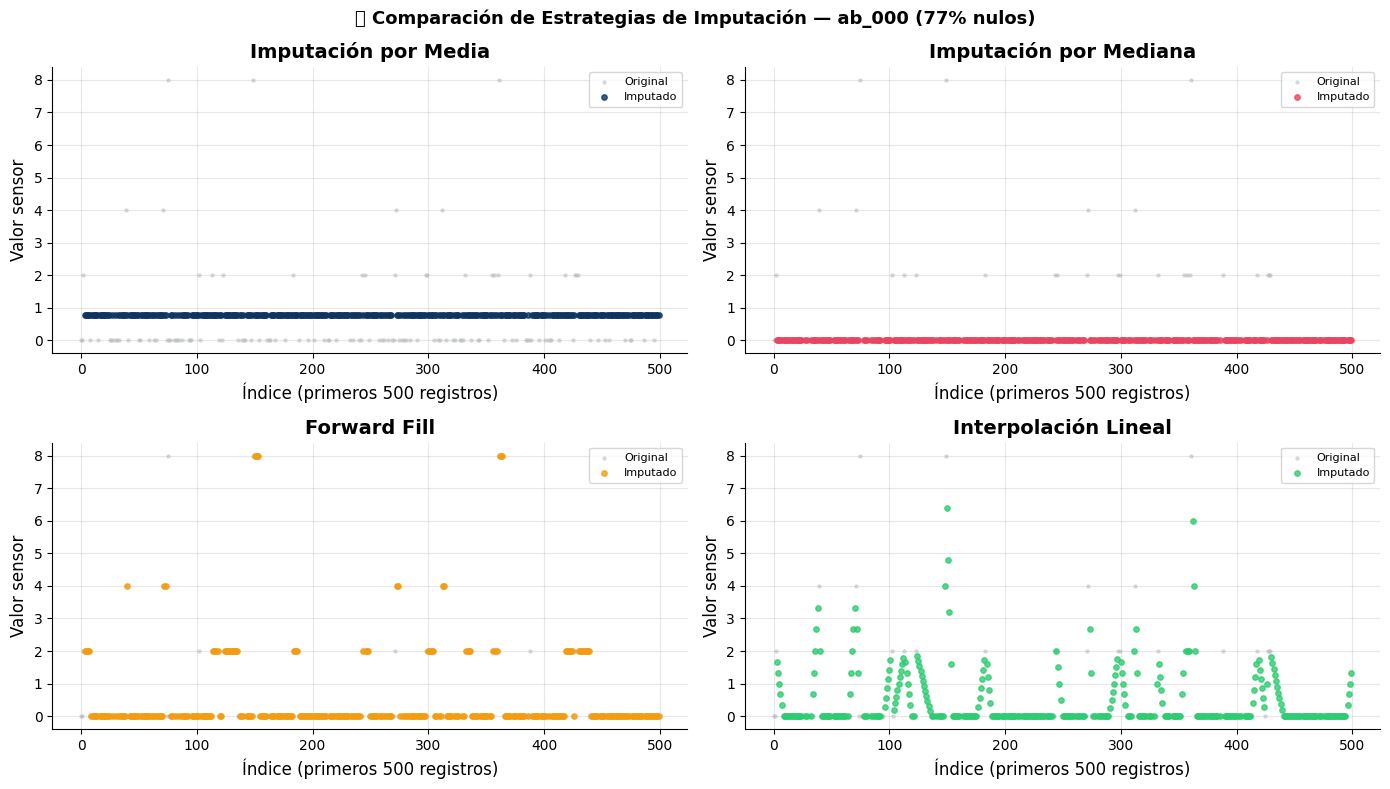


💡 'ab_000' tiene 12,363 valores faltantes (77.3%)
   Para series temporales de sensores → interpolación lineal o forward fill
   Para datos de CMMS (texto) → imputar con 'Desconocido' o la moda


In [19]:
# -------------------------------------------------------
# CELDA 2.3.D — Estrategias de imputación comparadas
# -------------------------------------------------------

# Usamos el dataset APS Failure que tiene muchos valores faltantes
# Columna 'ab_000': sensor de presión — tiene 77% de valores faltantes
# (codificados originalmente como el string 'na', ya convertidos a NaN en la carga)
col_trabajo = 'ab_000'
serie_nulos = df_aps[col_trabajo].copy()

print("=" * 55)
print(f"🔧 IMPUTACIÓN DE VALORES FALTANTES — {col_trabajo}")
print("=" * 55)
print(f"  Total registros   : {len(serie_nulos):,}")
print(f"  Valores nulos     : {serie_nulos.isnull().sum():,}")
print(f"  % faltante        : {serie_nulos.isnull().mean()*100:.1f}%")

# Estrategia 1: Media
# Reemplaza cada nulo con el promedio de todos los valores presentes
media = serie_nulos.mean()
serie_media = serie_nulos.fillna(media)
print(f"\n  Estrategia 1 — Media    : {media:.2f}")

# Estrategia 2: Mediana
# Más robusta que la media cuando hay outliers
mediana = serie_nulos.median()
serie_mediana = serie_nulos.fillna(mediana)
print(f"  Estrategia 2 — Mediana  : {mediana:.2f}")

# Estrategia 3: Forward Fill (propagar último valor válido)
# Útil para series temporales: el valor anterior es la mejor estimación
serie_ffill = serie_nulos.ffill()
print(f"  Estrategia 3 — Forward Fill: propaga el último valor válido")

# Estrategia 4: Interpolación lineal
# Estima el valor faltante como punto intermedio entre vecinos
serie_interp = serie_nulos.interpolate(method='linear')
print(f"  Estrategia 4 — Interpolación lineal: estima entre vecinos")

# Comparación visual (mostramos solo los primeros 500 registros para claridad)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
n_muestra  = 500
idx        = range(n_muestra)
sub_orig   = serie_nulos.iloc[:n_muestra]
mask_nulos = sub_orig.isnull()

estrategias = [
    (axes[0,0], serie_media.iloc[:n_muestra],   'Imputación por Media',    COLORS['secondary']),
    (axes[0,1], serie_mediana.iloc[:n_muestra], 'Imputación por Mediana',  COLORS['primary']),
    (axes[1,0], serie_ffill.iloc[:n_muestra],   'Forward Fill',            COLORS['warn']),
    (axes[1,1], serie_interp.iloc[:n_muestra],  'Interpolación Lineal',    COLORS['ok']),
]

for ax, serie_imp, titulo, color in estrategias:
    # Puntos originales (no nulos) en gris
    ax.scatter(list(idx), sub_orig, color='#bdc3c7', s=5, alpha=0.5, label='Original')
    # Puntos imputados en color
    idx_arr = np.array(list(idx))
    ax.scatter(idx_arr[mask_nulos],
               serie_imp[mask_nulos],
               color=color, s=15, alpha=0.8, label='Imputado', zorder=5)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Índice (primeros 500 registros)')
    ax.set_ylabel('Valor sensor')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'🔧 Comparación de Estrategias de Imputación — {col_trabajo} ({serie_nulos.isnull().mean()*100:.0f}% nulos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 '{col_trabajo}' tiene {serie_nulos.isnull().sum():,} valores faltantes ({serie_nulos.isnull().mean()*100:.1f}%)")
print("   Para series temporales de sensores → interpolación lineal o forward fill")
print("   Para datos de CMMS (texto) → imputar con 'Desconocido' o la moda")

---
## 🔍 Ejemplo Guiado 2.3.3 — Detección de Stuck Values

📡 DETECCIÓN DE STUCK VALUES — frequency_Hz
  Ventana de análisis : 6 lecturas (30 minutos)
  Umbral de varianza  : 0.0001
  Períodos congelados : 159 lecturas
  % del tiempo        : 1.78%
  Racha máxima de valor repetido: 4 lecturas consecutivas


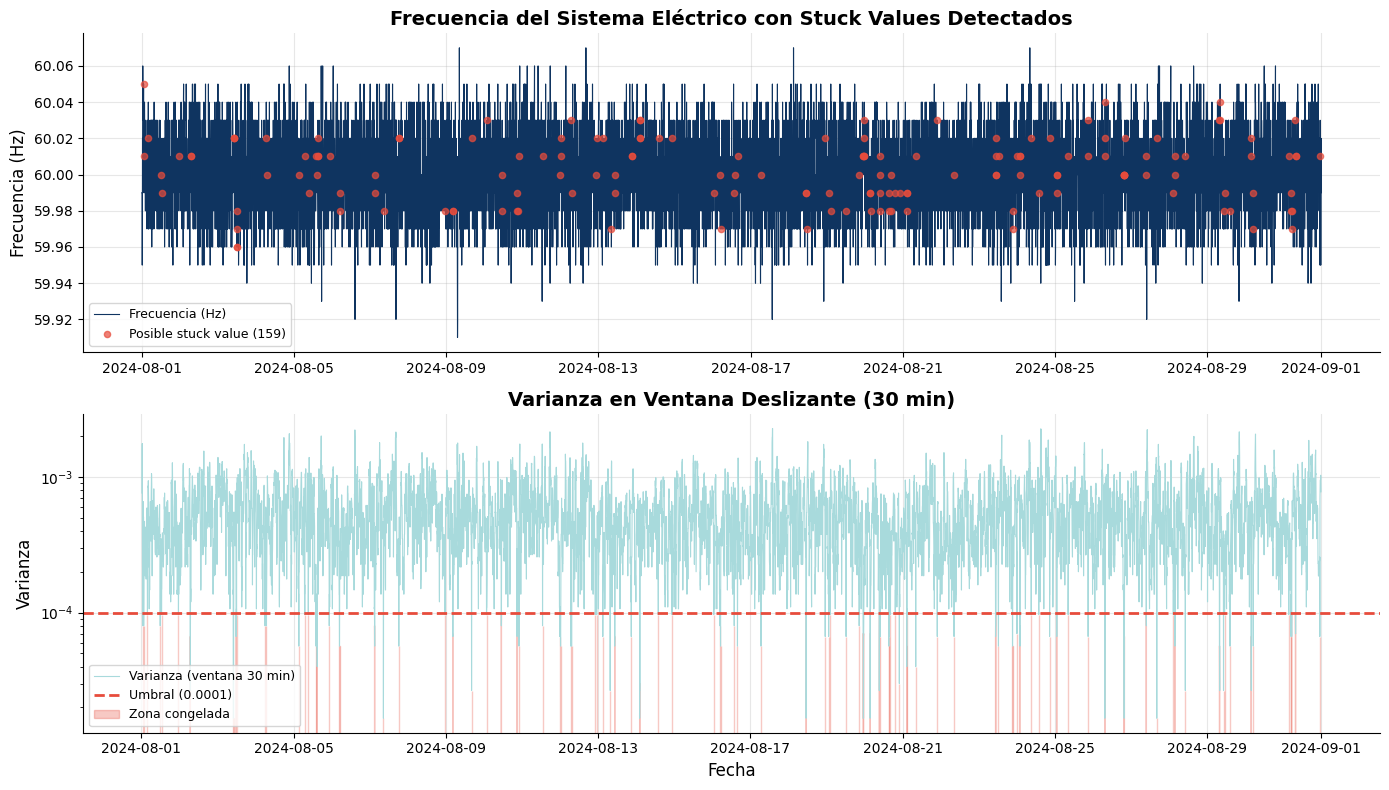


⚠️  Un sensor congelado es más peligroso que un sensor con outliers:
    Los outliers son visibles; los stuck values parecen datos normales


In [20]:
#sensores que se quedaron pasmados  con un valor constante
# -------------------------------------------------------
# CELDA 2.3.E — Detección de Stuck Values (valores congelados)
# -------------------------------------------------------

# Un "stuck value" ocurre cuando el sensor reporta el mismo valor
# repetidamente. Esto indica que el sensor falló, no que el proceso esté estable.

col_freq  = 'frequency_Hz'
serie_freq = df_modbus[col_freq].copy()

print("=" * 55)
print(f"📡 DETECCIÓN DE STUCK VALUES — {col_freq}")
print("=" * 55)

# Método: Varianza en ventana deslizante
# Si la varianza en una ventana de N puntos es 0 (o muy cercana a 0),
# el sensor está "congelado"
ventana    = 6       # 6 lecturas = 30 minutos (cada lectura = 5 min)
umbral_var = 0.0001  # Varianza menor a este valor → posible stuck value

varianza_ventana = serie_freq.rolling(window=ventana).var()
mascara_stuck    = varianza_ventana < umbral_var

print(f"  Ventana de análisis : {ventana} lecturas ({ventana*5} minutos)")
print(f"  Umbral de varianza  : {umbral_var}")
print(f"  Períodos congelados : {mascara_stuck.sum()} lecturas")
print(f"  % del tiempo        : {mascara_stuck.mean()*100:.2f}%")

# Detectar rachas de valores repetidos
diff_freq   = serie_freq.diff().abs()
racha_actual = 0
max_racha    = 0
for d in diff_freq.dropna():
    if d == 0:
        racha_actual += 1
        max_racha = max(max_racha, racha_actual)
    else:
        racha_actual = 0
print(f"  Racha máxima de valor repetido: {max_racha} lecturas consecutivas")

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(df_modbus['timestamp'], serie_freq,
        color=COLORS['secondary'], linewidth=0.8, label='Frecuencia (Hz)')
ax.scatter(df_modbus['timestamp'][mascara_stuck],
           serie_freq[mascara_stuck],
           color=COLORS['danger'], s=20, zorder=5, alpha=0.7,
           label=f'Posible stuck value ({mascara_stuck.sum()})')
ax.set_title('Frecuencia del Sistema Eléctrico con Stuck Values Detectados', fontweight='bold')
ax.set_ylabel('Frecuencia (Hz)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_modbus['timestamp'], varianza_ventana,
        color=COLORS['accent'], linewidth=0.8, label='Varianza (ventana 30 min)')
ax.axhline(umbral_var, color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'Umbral ({umbral_var})')
ax.fill_between(df_modbus['timestamp'], 0, varianza_ventana,
                where=varianza_ventana < umbral_var,
                color=COLORS['danger'], alpha=0.3, label='Zona congelada')
ax.set_title('Varianza en Ventana Deslizante (30 min)', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Varianza')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n⚠️  Un sensor congelado es más peligroso que un sensor con outliers:")
print("    Los outliers son visibles; los stuck values parecen datos normales")

#eliminar esos  valores donde se quedo pegado si son muchos  pegados  juntos  hay menor certeza
#de  que imputamos  sea  correcto

---
## 💡 Interpretación de Resultados 2.3

**Outliers:**
- Detectamos lecturas de corriente fuera del rango normal usando el método IQR
- El tratamiento más seguro en mantenimiento es reemplazar por la **mediana** (no la media, que también se ve afectada por outliers)

**Valores faltantes:**
- Para series temporales de sensores: **interpolación lineal** o **forward fill**
- Para datos de CMMS (texto): imputar con `'Desconocido'` o la moda

**Stuck values:**
- Son el problema más peligroso porque parecen datos válidos
- La varianza en ventana deslizante es el método más efectivo para detectarlos
- En mantenimiento predictivo, un sensor congelado puede hacer que un modelo prediga "equipo sano" cuando en realidad está fallando

---
## ✏️ Ejercicio 2.3 — Limpieza completa del dataset de rodamientos

Aplica las técnicas de limpieza al dataset de rodamientos defectuosos.

Outliers detectados: 16 (1.6%) -- Límites: [-0.60, 0.67]


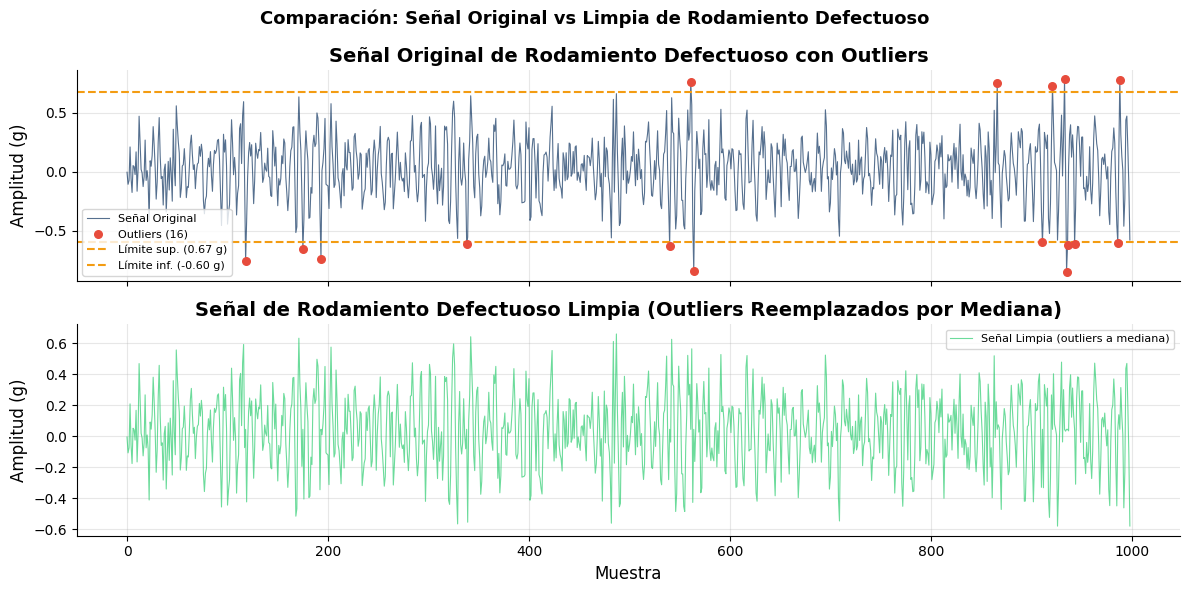

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

serie_defectuosa = df_faulty['Measurement'].copy()

# Paso 1: Calcular Q1, Q3 e IQR
Q1  = serie_defectuosa.quantile(0.25)   # ← Percentil 25
Q3  = serie_defectuosa.quantile(0.75)   # ← Percentil 75
IQR = Q3 - Q1                # ← Q3 - Q1

# Paso 2: Definir límites y detectar outliers
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
mascara = (serie_defectuosa < lim_inf) | (serie_defectuosa > lim_sup)
print(f"Outliers detectados: {mascara.sum()} ({mascara.sum()/len(serie_defectuosa)*100:.1f}%) -- Límites: [{lim_inf:.2f}, {lim_sup:.2f}]")

# Paso 3: Crear versión limpia
serie_limpia = serie_defectuosa.copy()
serie_limpia[mascara] = serie_defectuosa.median()   # ← Reemplazar por mediana

# Paso 4: Gráfico comparativo (2 filas)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# axes[0]: señal original con outliers marcados
axes[0].plot(serie_defectuosa.index, serie_defectuosa, color=COLORS['secondary'], linewidth=0.8, alpha=0.7, label='Señal Original')
axes[0].scatter(serie_defectuosa[mascara].index, serie_defectuosa[mascara],
           color=COLORS['danger'], s=30, zorder=5, label=f'Outliers ({mascara.sum()})')
axes[0].axhline(lim_sup, color=COLORS['warn'], linestyle='--', linewidth=1.5, label=f'Límite sup. ({lim_sup:.2f} g)')
axes[0].axhline(lim_inf, color=COLORS['warn'], linestyle='--', linewidth=1.5, label=f'Límite inf. ({lim_inf:.2f} g)')
axes[0].set_title('Señal Original de Rodamiento Defectuoso con Outliers', fontweight='bold')
axes[0].set_ylabel('Amplitud (g)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# axes[1]: señal limpia
axes[1].plot(serie_limpia.index, serie_limpia, color=COLORS['ok'], linewidth=0.8, alpha=0.7, label='Señal Limpia (outliers a mediana)')
axes[1].set_title('Señal de Rodamiento Defectuoso Limpia (Outliers Reemplazados por Mediana)', fontweight='bold')
axes[1].set_xlabel('Muestra')
axes[1].set_ylabel('Amplitud (g)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación: Señal Original vs Limpia de Rodamiento Defectuoso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚡ Mini Reto 2.3

**Desafío:** Detecta stuck values en la columna `voltage_avg_V` del dataset MODBUS-RTU.

1. Usa una ventana de 12 lecturas (1 hora)
2. Umbral de varianza: 0.001
3. ¿Cuántos períodos de voltaje congelado encuentras?
4. ¿Coinciden con los períodos de corriente congelada?

📡 DETECCIÓN DE STUCK VALUES — voltage_avg_V
  Ventana de análisis : 12 lecturas (60 minutos)
  Umbral de varianza  : 0.001
  Períodos congelados : 0 lecturas
  % del tiempo        : 0.00%
  Racha máxima de valor repetido: 2 lecturas consecutivas


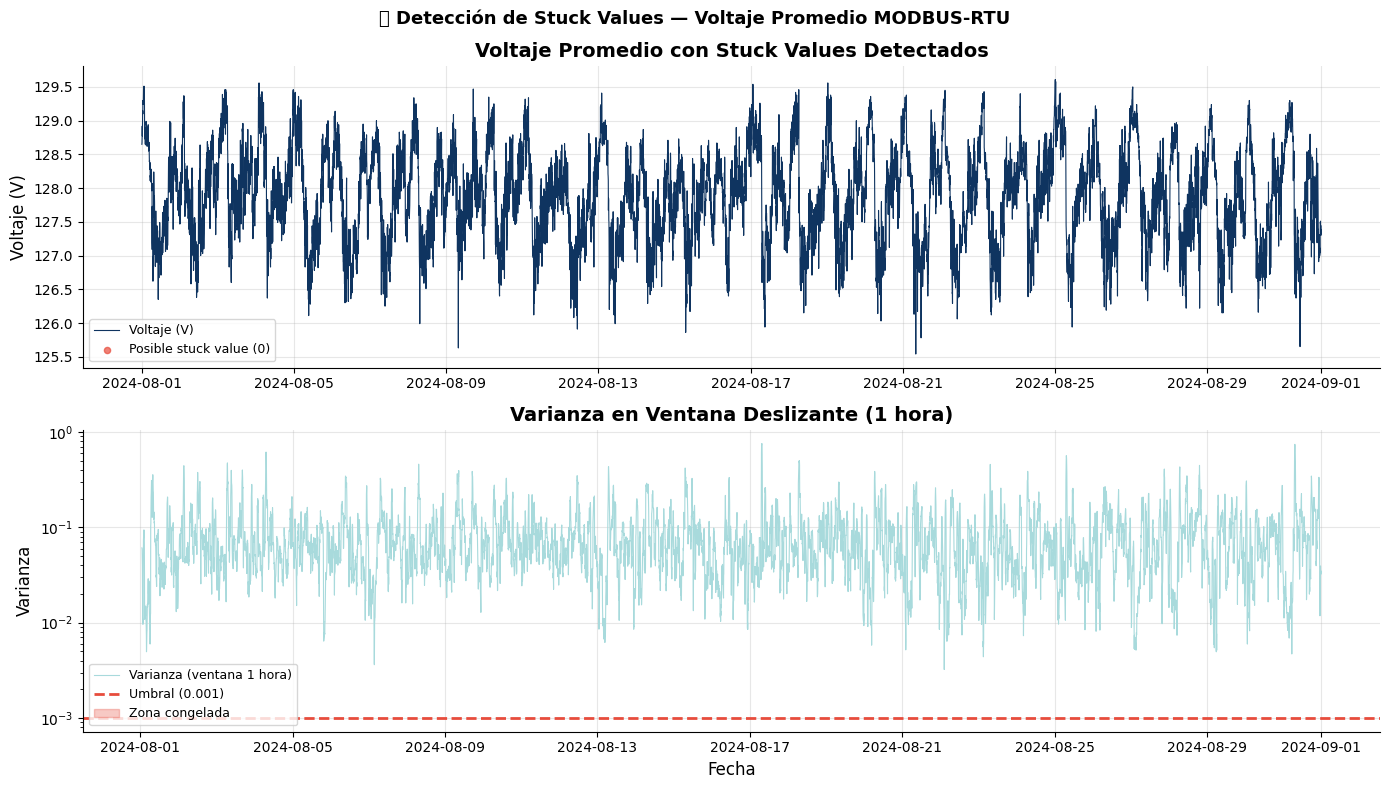


  Comparación con 'frequency_Hz':
  Lecturas donde ambos (frecuencia y voltaje) están congelados: 0
  % de coincidencia: 0.00%


In [22]:
col_volt  = 'voltage_avg_V'
serie_volt = df_modbus[col_volt].copy()

print("=" * 55)
print(f"📡 DETECCIÓN DE STUCK VALUES — {col_volt}")
print("=" * 55)

# Método: Varianza en ventana deslizante
# Si la varianza en una ventana de N puntos es 0 (o muy cercana a 0),
# el sensor está "congelado"
ventana    = 12      # 12 lecturas = 1 hora (cada lectura = 5 min)
umbral_var = 0.001   # Umbral de varianza

varianza_ventana_volt = serie_volt.rolling(window=ventana).var()
mascara_stuck_volt    = varianza_ventana_volt < umbral_var

print(f"  Ventana de análisis : {ventana} lecturas ({ventana*5} minutos)")
print(f"  Umbral de varianza  : {umbral_var}")
print(f"  Períodos congelados : {mascara_stuck_volt.sum()} lecturas")
print(f"  % del tiempo        : {mascara_stuck_volt.mean()*100:.2f}%")

# Detectar rachas de valores repetidos
diff_volt    = serie_volt.diff().abs()
racha_actual_volt = 0
max_racha_volt    = 0
for d in diff_volt.dropna():
    if d == 0:
        racha_actual_volt += 1
        max_racha_volt = max(max_racha_volt, racha_actual_volt)
    else:
        racha_actual_volt = 0
print(f"  Racha máxima de valor repetido: {max_racha_volt} lecturas consecutivas")

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(df_modbus['timestamp'], serie_volt,
        color=COLORS['secondary'], linewidth=0.8, label='Voltaje (V)')
ax.scatter(df_modbus['timestamp'][mascara_stuck_volt],
           serie_volt[mascara_stuck_volt],
           color=COLORS['danger'], s=20, zorder=5, alpha=0.7,
           label=f'Posible stuck value ({mascara_stuck_volt.sum()})')
ax.set_title('Voltaje Promedio con Stuck Values Detectados', fontweight='bold')
ax.set_ylabel('Voltaje (V)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_modbus['timestamp'], varianza_ventana_volt,
        color=COLORS['accent'], linewidth=0.8, label='Varianza (ventana 1 hora)')
ax.axhline(umbral_var, color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'Umbral ({umbral_var})')
ax.fill_between(df_modbus['timestamp'], 0, varianza_ventana_volt,
                where=varianza_ventana_volt < umbral_var,
                color=COLORS['danger'], alpha=0.3, label='Zona congelada')
ax.set_title('Varianza en Ventana Deslizante (1 hora)', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Varianza')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.suptitle('📡 Detección de Stuck Values — Voltaje Promedio MODBUS-RTU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n  Comparación con 'frequency_Hz':")
# Necesitamos asegurarnos de que `mascara_stuck` esté disponible desde la ejecución previa
# o recalcularla si no lo está.
# Asumiendo que `mascara_stuck` para frequency_Hz está disponible del Ejemplo Guiado 2.3.3 (Celda 2.3.E)
if 'mascara_stuck' in globals():
    coincidencias = (mascara_stuck & mascara_stuck_volt).sum()
    print(f"  Lecturas donde ambos (frecuencia y voltaje) están congelados: {coincidencias}")
    print(f"  % de coincidencia: {coincidencias / mascara_stuck_volt.sum() * 100 if mascara_stuck_volt.sum() > 0 else 0:.2f}%")
else:
    print("  La máscara de stuck values para frequency_Hz no se encontró en el entorno.")
    print("  Por favor, asegúrate de haber ejecutado la celda 2.3.E antes de esta celda para comparar.")

---
## 🧠 Quiz 2.3 — Limpieza de Datos

In [ ]:
# -------------------------------------------------------
# QUIZ 2.3 — Cuestionario interactivo
# -------------------------------------------------------

def quiz_23():
    score = 0
    total = 4

    print("=" * 60)
    print("🧠 QUIZ 2.3 — Limpieza de Datos Industriales")
    print("=" * 60)

    # Pregunta 1 (basada en datos reales)
    Q1_real  = df_modbus['current_avg_A'].quantile(0.25)
    Q3_real  = df_modbus['current_avg_A'].quantile(0.75)
    IQR_real = Q3_real - Q1_real
    lim_sup_real = round(Q3_real + 1.5 * IQR_real, 1)

    print(f"\n1️⃣  En el dataset MODBUS-RTU, el límite superior IQR para")
    print(f"   'current_avg_A' es aproximadamente:")
    print(f"   a) {lim_sup_real - 20:.1f} A")
    print(f"   b) {lim_sup_real:.1f} A")
    print(f"   c) {lim_sup_real + 30:.1f} A")
    r1 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r1 == 'b':
        print(f"   ✅ ¡Correcto! El límite superior es {lim_sup_real:.1f} A")
        score += 1
    else:
        print(f"   ❌ La respuesta es 'b': {lim_sup_real:.1f} A")

    # Pregunta 2
    print("\n2️⃣  ¿Qué es un 'stuck value' en el contexto de sensores industriales?")
    print("   a) Un valor que está fuera del rango normal del sensor")
    print("   b) Un valor que se repite sin cambiar cuando debería variar")
    print("   c) Un valor que falta porque el sensor no registró datos")
    r2 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r2 == 'b':
        print("   ✅ ¡Correcto! Un stuck value es un sensor congelado")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': valor repetido cuando debería variar")

    # Pregunta 3
    print(f"\n3️⃣  ¿Qué estrategia de imputación es más adecuada para una")
    print(f"   serie temporal de sensores con datos faltantes?")
    print(f"   a) Eliminar todas las filas con nulos")
    print(f"   b) Reemplazar con el valor máximo histórico")
    print(f"   c) Interpolación lineal o forward fill")
    r3 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r3 == 'c':
        print("   ✅ ¡Correcto! La interpolación respeta la continuidad temporal")
        score += 1
    else:
        print("   ❌ La respuesta es 'c': interpolación lineal o forward fill")

    # Pregunta 4 (basada en datos reales)
    s = df_faulty['Measurement']
    q1_f = s.quantile(0.25)
    q3_f = s.quantile(0.75)
    iqr_f = q3_f - q1_f
    n_out_faulty = ((s < q1_f - 1.5*iqr_f) | (s > q3_f + 1.5*iqr_f)).sum()
    print(f"\n4️⃣  En el rodamiento defectuoso, ¿cuántos outliers detecta el método IQR?")
    print(f"   a) {n_out_faulty - 20}")
    print(f"   b) {n_out_faulty}")
    print(f"   c) {n_out_faulty + 30}")
    r4 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r4 == 'b':
        print(f"   ✅ ¡Correcto! {n_out_faulty} outliers detectados")
        score += 1
    else:
        print(f"   ❌ La respuesta es 'b': {n_out_faulty} outliers")

    print("\n" + "=" * 60)
    print(f"📊 RESULTADO: {score}/{total} respuestas correctas")
    if score == total:
        print("🏆 ¡Perfecto! Dominas las técnicas de limpieza de datos")
    elif score >= 2:
        print("👍 Buen trabajo. Practica más con los datasets")
    else:
        print("📚 Revisa los métodos IQR, imputación y stuck values")
    print("=" * 60)

quiz_23()

---
# 📌 SUBTEMA 2.4 — Transformación y Tratamiento de Datos

---

## 📖 Concepto

### ¿Qué es la transformación de datos?

Transformar datos significa **cambiar su escala, frecuencia o representación** para que sean más útiles para el análisis.

### Las transformaciones clave en mantenimiento predictivo

| Transformación | ¿Qué hace? | ¿Cuándo usarla? |
|----------------|-----------|-----------------|
| **Resampling** | Cambia la frecuencia temporal | Sincronizar sensores con diferentes frecuencias |
| **MinMaxScaler** | Escala a [0, 1] | Algoritmos sensibles a la escala |
| **StandardScaler** | Media=0, Std=1 | Datos con distribución normal |
| **RobustScaler** | Usa mediana e IQR | Datos con outliers frecuentes |
| **Ventanas temporales** | Estadísticas en ventana deslizante | Detectar tendencias y anomalías |

> **Regla de oro en mantenimiento industrial:** Usa **RobustScaler** cuando no puedas garantizar que todos los outliers fueron eliminados.

📅 RESAMPLING — MODBUS-RTU
  Original (5 min) :  8920 registros
  Resample 1 hora  :   744 registros
  Resample 4 horas :   186 registros
  Resample 1 día   :    31 registros


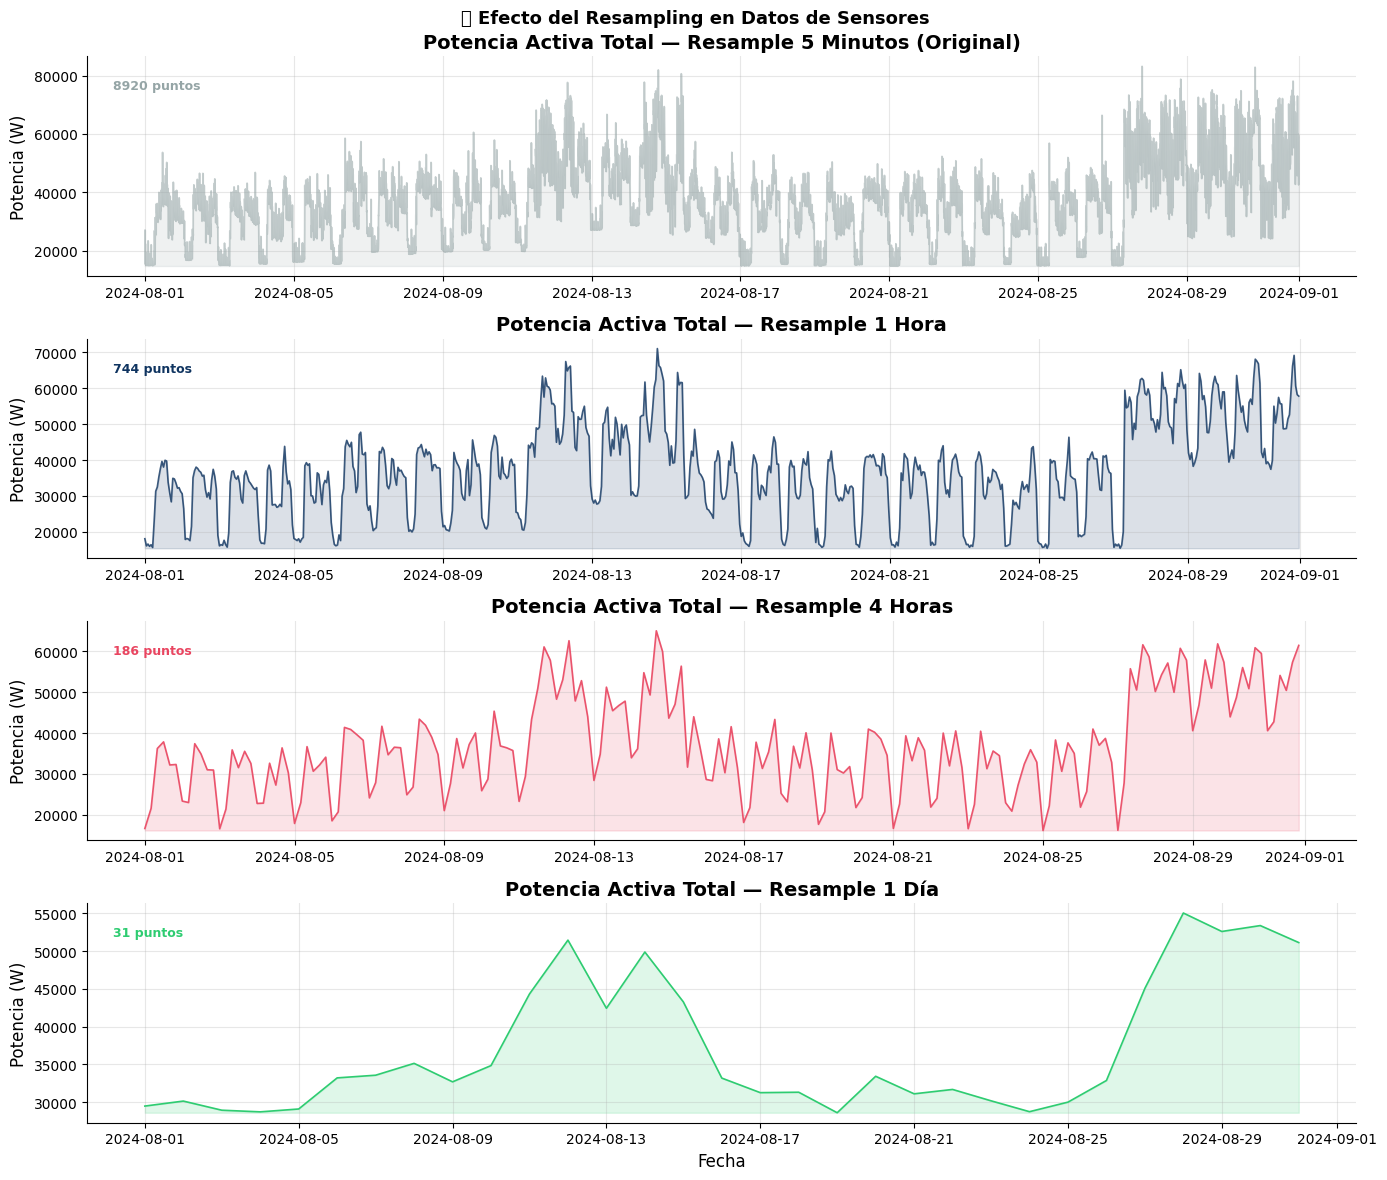


💡 El resample diario suaviza variaciones pero pierde información de picos
   Para mantenimiento predictivo, el resample horario suele ser el mejor balance


In [23]:
# -------------------------------------------------------
# CELDA 2.4.A — Resampling de datos de sensores
# -------------------------------------------------------

print("=" * 55)
print("📅 RESAMPLING — MODBUS-RTU")
print("=" * 55)

# Establecer timestamp como índice para operaciones temporales
df_modbus_ts = df_modbus.set_index('timestamp')

cols_resample = ['voltage_avg_V', 'current_avg_A',
                 'active_power_total_W', 'power_factor_total_pct']

# Downsampling: de 5 minutos a diferentes frecuencias
df_5min = df_modbus_ts[cols_resample]
df_1h   = df_modbus_ts[cols_resample].resample('1h').mean()
df_4h   = df_modbus_ts[cols_resample].resample('4h').mean()
df_1d   = df_modbus_ts[cols_resample].resample('1D').mean()

print(f"  Original (5 min) : {len(df_5min):>5} registros")
print(f"  Resample 1 hora  : {len(df_1h):>5} registros")
print(f"  Resample 4 horas : {len(df_4h):>5} registros")
print(f"  Resample 1 día   : {len(df_1d):>5} registros")

# Visualización del efecto del resampling
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
col_viz = 'active_power_total_W'

configs = [
    (df_5min, '5 Minutos (Original)', COLORS['neutral'],   0.5),
    (df_1h,   '1 Hora',              COLORS['secondary'],  0.8),
    (df_4h,   '4 Horas',             COLORS['primary'],    0.9),
    (df_1d,   '1 Día',               COLORS['ok'],         1.0),
]

for ax, (df_r, titulo, color, alpha) in zip(axes, configs):
    ax.plot(df_r.index, df_r[col_viz], color=color, linewidth=1.2, alpha=alpha)
    ax.fill_between(df_r.index, df_r[col_viz].min(), df_r[col_viz],
                    color=color, alpha=0.15)
    ax.set_title(f'Potencia Activa Total — Resample {titulo}', fontweight='bold')
    ax.set_ylabel('Potencia (W)')
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.85, f'{len(df_r)} puntos', transform=ax.transAxes,
            fontsize=9, color=color, fontweight='bold')

axes[-1].set_xlabel('Fecha')
plt.suptitle('📅 Efecto del Resampling en Datos de Sensores',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 El resample diario suaviza variaciones pero pierde información de picos")
print("   Para mantenimiento predictivo, el resample horario suele ser el mejor balance")

📏 COMPARACIÓN DE ESCALADORES
  Dataset: MODBUS-RTU (8,920 registros)

  Estadísticas después de escalar (columna: voltage_avg_V):
  Escalador                 Min      Max    Media      Std
  Original               125.54   129.61   127.88     0.69
  MinMax [0,1]           0.0000   1.0000   0.5755   0.1694
  StandardScaler        -3.3973   2.5061  -0.0000   1.0001
  RobustScaler          -2.3235   1.6667  -0.0272   0.6760


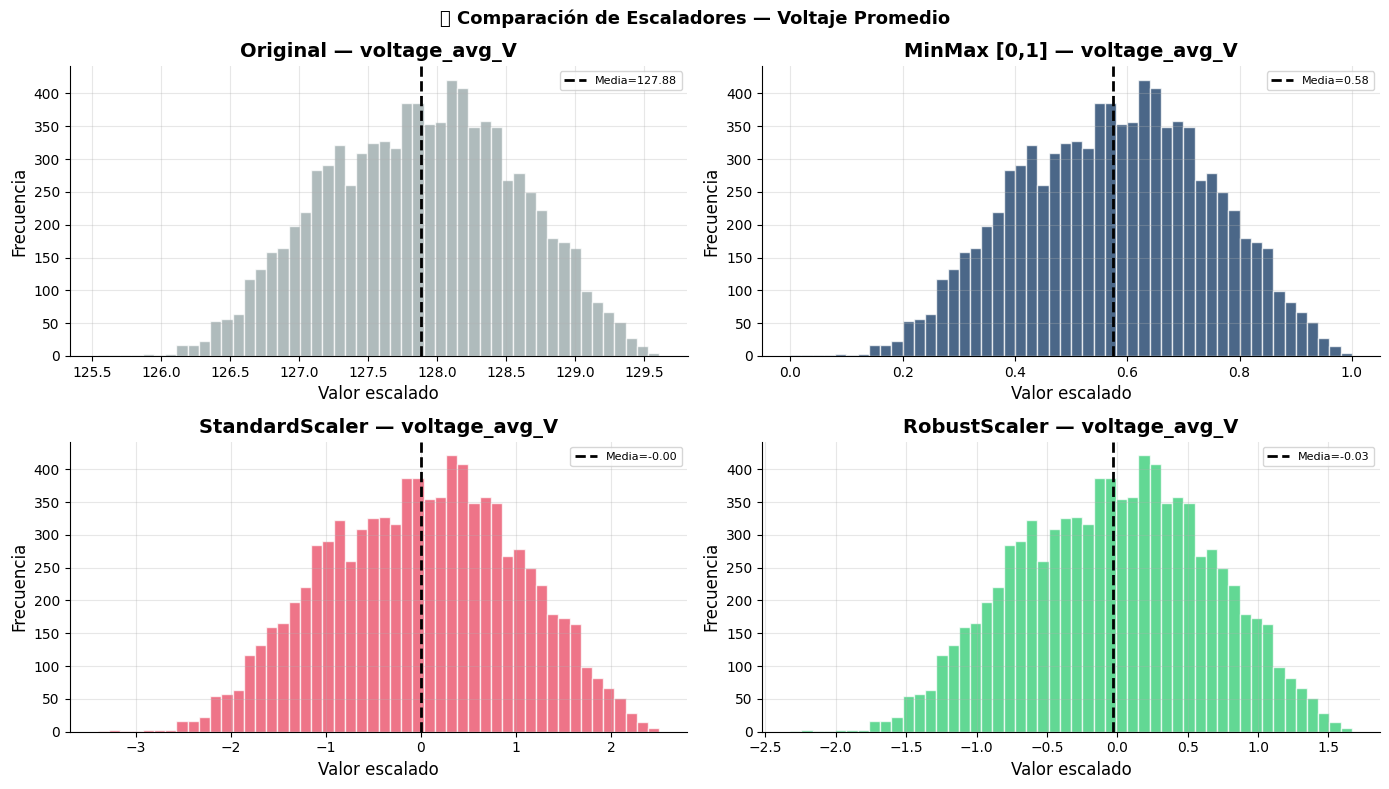

In [24]:
# -------------------------------------------------------
# CELDA 2.4.B — Normalización, Estandarización y RobustScaler
# -------------------------------------------------------

cols_escalar = ['voltage_avg_V', 'current_avg_A',
                'active_power_total_W', 'frequency_Hz']
X = df_modbus[cols_escalar].dropna()

print("=" * 55)
print("📏 COMPARACIÓN DE ESCALADORES")
print("=" * 55)
print(f"  Dataset: MODBUS-RTU ({len(X):,} registros)")

# Aplicar los tres escaladores
scaler_minmax   = MinMaxScaler()
scaler_standard = StandardScaler()
scaler_robust   = RobustScaler()

X_minmax   = pd.DataFrame(scaler_minmax.fit_transform(X),
                           columns=[c+'_minmax' for c in cols_escalar])
X_standard = pd.DataFrame(scaler_standard.fit_transform(X),
                           columns=[c+'_std' for c in cols_escalar])
X_robust   = pd.DataFrame(scaler_robust.fit_transform(X),
                           columns=[c+'_robust' for c in cols_escalar])

# Estadísticas después de escalar
col_v = 'voltage_avg_V'
print(f"\n  Estadísticas después de escalar (columna: {col_v}):")
print(f"  {'Escalador':<20} {'Min':>8} {'Max':>8} {'Media':>8} {'Std':>8}")
print(f"  {'Original':<20} {X[col_v].min():>8.2f} {X[col_v].max():>8.2f} "
      f"{X[col_v].mean():>8.2f} {X[col_v].std():>8.2f}")
print(f"  {'MinMax [0,1]':<20} {X_minmax[col_v+'_minmax'].min():>8.4f} "
      f"{X_minmax[col_v+'_minmax'].max():>8.4f} "
      f"{X_minmax[col_v+'_minmax'].mean():>8.4f} "
      f"{X_minmax[col_v+'_minmax'].std():>8.4f}")
print(f"  {'StandardScaler':<20} {X_standard[col_v+'_std'].min():>8.4f} "
      f"{X_standard[col_v+'_std'].max():>8.4f} "
      f"{X_standard[col_v+'_std'].mean():>8.4f} "
      f"{X_standard[col_v+'_std'].std():>8.4f}")
print(f"  {'RobustScaler':<20} {X_robust[col_v+'_robust'].min():>8.4f} "
      f"{X_robust[col_v+'_robust'].max():>8.4f} "
      f"{X_robust[col_v+'_robust'].mean():>8.4f} "
      f"{X_robust[col_v+'_robust'].std():>8.4f}")

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
datos_viz = [
    (X[col_v],                    'Original',       COLORS['neutral']),
    (X_minmax[col_v+'_minmax'],   'MinMax [0,1]',   COLORS['secondary']),
    (X_standard[col_v+'_std'],    'StandardScaler', COLORS['primary']),
    (X_robust[col_v+'_robust'],   'RobustScaler',   COLORS['ok']),
]

for ax, (data, titulo, color) in zip(axes.flat, datos_viz):
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=2,
               label=f'Media={data.mean():.2f}')
    ax.set_title(f'{titulo} — voltage_avg_V', fontweight='bold')
    ax.set_xlabel('Valor escalado')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('📏 Comparación de Escaladores — Voltaje Promedio',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#para usar algororitmo es necesario normalizar mis señales.
# arboles de decisiones  no necesitan escalarse

🪟 VENTANAS TEMPORALES — MODBUS-RTU
  Ventana 1h  (12 lecturas): calculada
  Ventana 4h  (48 lecturas): calculada
  Ventana 24h (288 lecturas): calculada


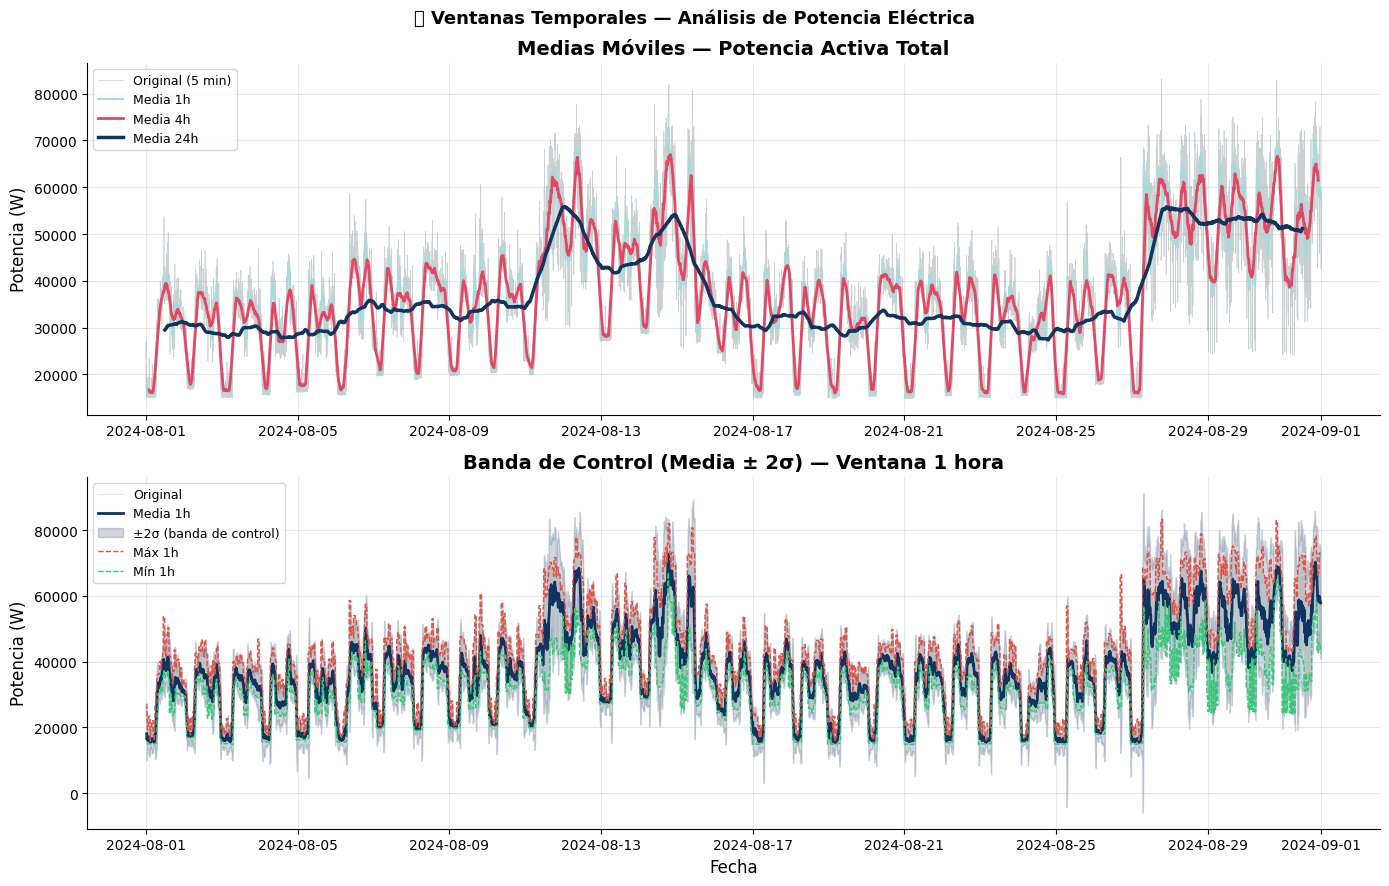


💡 La banda de control (±2σ) es la base del control estadístico de procesos (SPC)
   Puntos fuera de la banda → posible anomalía en el equipo


In [25]:
# -------------------------------------------------------
# CELDA 2.4.C — Ventanas temporales (Rolling Windows)
# -------------------------------------------------------

print("=" * 55)
print("🪟 VENTANAS TEMPORALES — MODBUS-RTU")
print("=" * 55)

potencia = df_modbus.set_index('timestamp')['active_power_total_W']

# Ventanas: 1h=12 lecturas, 4h=48, 24h=288 (cada lectura = 5 min)
ventana_1h  = 12
ventana_4h  = 48
ventana_24h = 288

# Media móvil (suaviza la señal)
media_1h  = potencia.rolling(window=ventana_1h,  center=True).mean()
media_4h  = potencia.rolling(window=ventana_4h,  center=True).mean()
media_24h = potencia.rolling(window=ventana_24h, center=True).mean()

# Desviación estándar móvil (detecta cambios de variabilidad)
std_1h = potencia.rolling(window=ventana_1h, center=True).std()

# Máximo y mínimo móvil
max_1h = potencia.rolling(window=ventana_1h, center=True).max()
min_1h = potencia.rolling(window=ventana_1h, center=True).min()

print(f"  Ventana 1h  ({ventana_1h} lecturas): calculada")
print(f"  Ventana 4h  ({ventana_4h} lecturas): calculada")
print(f"  Ventana 24h ({ventana_24h} lecturas): calculada")

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Medias móviles
ax = axes[0]
ax.plot(potencia.index, potencia.values,
        color=COLORS['neutral'], linewidth=0.5, alpha=0.5, label='Original (5 min)')
ax.plot(media_1h.index,  media_1h.values,  color=COLORS['accent'],    linewidth=1.5, label='Media 1h')
ax.plot(media_4h.index,  media_4h.values,  color=COLORS['primary'],   linewidth=2,   label='Media 4h')
ax.plot(media_24h.index, media_24h.values, color=COLORS['secondary'], linewidth=2.5, label='Media 24h')
ax.set_title('Medias Móviles — Potencia Activa Total', fontweight='bold')
ax.set_ylabel('Potencia (W)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Banda de control (media ± 2σ)
ax = axes[1]
ax.plot(potencia.index, potencia.values,
        color=COLORS['neutral'], linewidth=0.5, alpha=0.4, label='Original')
ax.plot(media_1h.index, media_1h.values,
        color=COLORS['secondary'], linewidth=2, label='Media 1h')
ax.fill_between(media_1h.index,
                (media_1h - 2*std_1h).values,
                (media_1h + 2*std_1h).values,
                color=COLORS['secondary'], alpha=0.2, label='±2σ (banda de control)')
ax.plot(max_1h.index, max_1h.values,
        color=COLORS['danger'], linewidth=1, linestyle='--', label='Máx 1h')
ax.plot(min_1h.index, min_1h.values,
        color=COLORS['ok'], linewidth=1, linestyle='--', label='Mín 1h')
ax.set_title('Banda de Control (Media ± 2σ) — Ventana 1 hora', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Potencia (W)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('🪟 Ventanas Temporales — Análisis de Potencia Eléctrica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 La banda de control (±2σ) es la base del control estadístico de procesos (SPC)")
print("   Puntos fuera de la banda → posible anomalía en el equipo")

---
## 💡 Interpretación de Resultados 2.4

**Resampling:**
- El resample diario reduce 8,920 lecturas a ~30 puntos, perdiendo variaciones horarias
- Para mantenimiento predictivo, el resample horario suele ser el mejor balance

**Escaladores:**
- **MinMax:** Útil cuando necesitas valores en [0,1], pero sensible a outliers
- **StandardScaler:** Ideal cuando los datos son aproximadamente normales
- **RobustScaler:** El más robusto en datos industriales con outliers frecuentes

**Ventanas temporales:**
- La media móvil de 24h revela la tendencia de consumo energético
- La banda ±2σ permite detectar anomalías operacionales en tiempo real

---
## ✏️ Ejercicio 2.4 — Normalización de señales de rodamientos

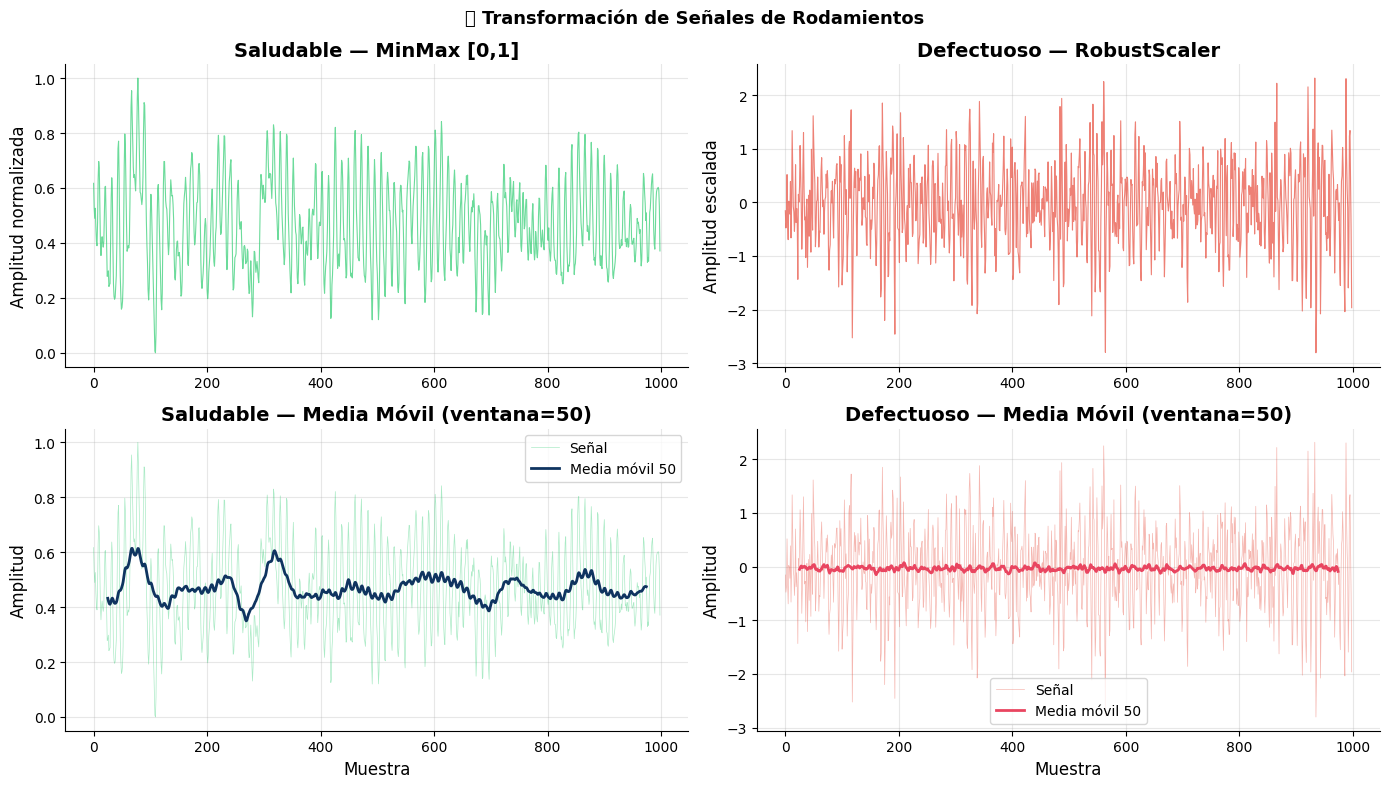

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sig_healthy = df_healthy['Measurement'].values.reshape(-1, 1)
sig_faulty  = df_faulty['Measurement'].values.reshape(-1, 1)

# Paso 1: MinMaxScaler al saludable
scaler_mm = MinMaxScaler()
sig_healthy_norm = scaler_mm.fit_transform(sig_healthy).flatten()   # ← fit_transform y flatten()

# Paso 2: RobustScaler al defectuoso
scaler_rb = RobustScaler()
sig_faulty_robust = scaler_rb.fit_transform(sig_faulty).flatten()  # ← fit_transform y flatten()

# Paso 3: Media móvil (ventana=50)
media_mov_healthy = pd.Series(sig_healthy_norm).rolling(window=50, center=True).mean()
media_mov_faulty  = pd.Series(sig_faulty_robust).rolling(window=50, center=True).mean()

# Paso 4: Figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# ========= COMPLETAR =========
# axes[0,0]: señal saludable normalizada
axes[0,0].plot(sig_healthy_norm, color=COLORS['ok'], linewidth=0.8, alpha=0.7)
axes[0,0].set_title('Saludable — MinMax [0,1]', fontweight='bold')
axes[0,0].set_ylabel('Amplitud normalizada')
axes[0,0].grid(True, alpha=0.3)

# axes[0,1]: señal defectuosa robusta
axes[0,1].plot(sig_faulty_robust, color=COLORS['danger'], linewidth=0.8, alpha=0.7)
axes[0,1].set_title('Defectuoso — RobustScaler', fontweight='bold')
axes[0,1].set_ylabel('Amplitud escalada')
axes[0,1].grid(True, alpha=0.3)

# axes[1,0]: media móvil saludable
axes[1,0].plot(sig_healthy_norm, color=COLORS['ok'], linewidth=0.5, alpha=0.4, label='Señal')
axes[1,0].plot(media_mov_healthy, color=COLORS['secondary'], linewidth=2, label='Media móvil 50')
axes[1,0].set_title('Saludable — Media Móvil (ventana=50)', fontweight='bold')
axes[1,0].set_xlabel('Muestra')
axes[1,0].set_ylabel('Amplitud')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# axes[1,1]: media móvil defectuosa
axes[1,1].plot(sig_faulty_robust, color=COLORS['danger'], linewidth=0.5, alpha=0.4, label='Señal')
axes[1,1].plot(media_mov_faulty, color=COLORS['primary'], linewidth=2, label='Media móvil 50')
axes[1,1].set_title('Defectuoso — Media Móvil (ventana=50)', fontweight='bold')
axes[1,1].set_xlabel('Muestra')
axes[1,1].set_ylabel('Amplitud')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('📏 Transformación de Señales de Rodamientos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Solución Ejercicio 2.4

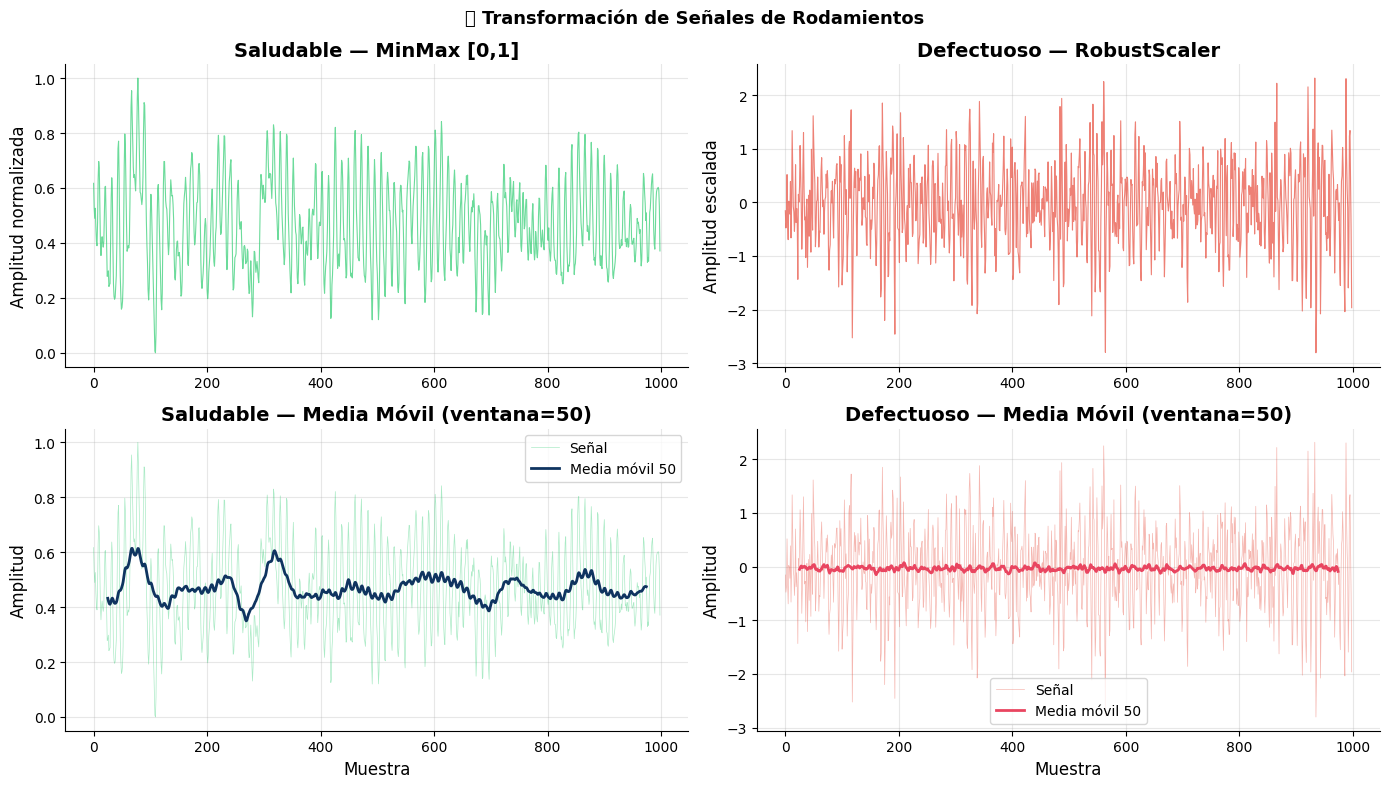


💡 La media móvil del rodamiento defectuoso tiene mayor variabilidad
   → Esta variabilidad es una feature útil para detectar fallas


In [29]:
# -------------------------------------------------------
# SOLUCIÓN 2.4 — Normalización de rodamientos
# -------------------------------------------------------

sig_healthy = df_healthy['Measurement'].values.reshape(-1, 1)
sig_faulty  = df_faulty['Measurement'].values.reshape(-1, 1)

# Paso 1: MinMaxScaler al saludable
scaler_mm        = MinMaxScaler()
sig_healthy_norm = scaler_mm.fit_transform(sig_healthy).flatten()

# Paso 2: RobustScaler al defectuoso
scaler_rb         = RobustScaler()
sig_faulty_robust = scaler_rb.fit_transform(sig_faulty).flatten()

# Paso 3: Media móvil (ventana=50)
media_mov_healthy = pd.Series(sig_healthy_norm).rolling(window=50, center=True).mean()
media_mov_faulty  = pd.Series(sig_faulty_robust).rolling(window=50, center=True).mean()

# Paso 4: Figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(sig_healthy_norm, color=COLORS['ok'], linewidth=0.8, alpha=0.7)
axes[0,0].set_title('Saludable — MinMax [0,1]', fontweight='bold')
axes[0,0].set_ylabel('Amplitud normalizada')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(sig_faulty_robust, color=COLORS['danger'], linewidth=0.8, alpha=0.7)
axes[0,1].set_title('Defectuoso — RobustScaler', fontweight='bold')
axes[0,1].set_ylabel('Amplitud escalada')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(sig_healthy_norm, color=COLORS['ok'], linewidth=0.5, alpha=0.4, label='Señal')
axes[1,0].plot(media_mov_healthy, color=COLORS['secondary'], linewidth=2, label='Media móvil 50')
axes[1,0].set_title('Saludable — Media Móvil (ventana=50)', fontweight='bold')
axes[1,0].set_xlabel('Muestra')
axes[1,0].set_ylabel('Amplitud')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(sig_faulty_robust, color=COLORS['danger'], linewidth=0.5, alpha=0.4, label='Señal')
axes[1,1].plot(media_mov_faulty, color=COLORS['primary'], linewidth=2, label='Media móvil 50')
axes[1,1].set_title('Defectuoso — Media Móvil (ventana=50)', fontweight='bold')
axes[1,1].set_xlabel('Muestra')
axes[1,1].set_ylabel('Amplitud')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('📏 Transformación de Señales de Rodamientos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 La media móvil del rodamiento defectuoso tiene mayor variabilidad")
print("   → Esta variabilidad es una feature útil para detectar fallas")

---
## ⚡ Mini Reto 2.4

**Desafío:** Calcula el **factor de cresta** (Crest Factor) para ambas señales de rodamiento.

El factor de cresta = Valor pico / RMS

- Un factor de cresta alto indica impactos mecánicos (típico de rodamientos defectuosos)
- Referencia industrial: FC < 2.5 → Buen estado | FC 2.5-4 → Inicio de desgaste | FC > 4 → Daño significativo

In [30]:
import numpy as np
from scipy import stats

# Asumiendo que 'sig_healthy' y 'sig_faulty' están definidos de celdas anteriores
# Si no lo estuvieran, deberíamos definirlos aquí:
# sig_healthy = df_healthy['Measurement'].values
# sig_faulty  = df_faulty['Measurement'].values

def extraer_features_temporales(señal):
    """
    Extrae features estadísticas del dominio temporal de una señal.
    Esta es una versión simplificada de la función ya definida, solo para asegurar que tengamos 'rms' y 'crest_factor'
    """
    s = np.array(señal)
    rms = np.sqrt(np.mean(s**2))

    features = {
        'rms'            : rms,
        'crest_factor'   : np.max(np.abs(s)) / (rms + 1e-10), # Agregamos 1e-10 para evitar división por cero
        'maximo_abs'     : np.max(np.abs(s))
    }
    return features

# Calcular features para ambas señales
feat_healthy = extraer_features_temporales(sig_healthy)
feat_faulty  = extraer_features_temporales(sig_faulty)

# Obtener los factores de cresta
crest_factor_healthy = feat_healthy['crest_factor']
crest_factor_faulty  = feat_faulty['crest_factor']

print("=" * 50)
print("📈 CÁLCULO DEL FACTOR DE CRESTA PARA RODAMIENTOS")
print("=" * 50)
print(f"  Factor de Cresta (Saludable) : {crest_factor_healthy:.2f}")
print(f"  Factor de Cresta (Defectuoso): {crest_factor_faulty:.2f}")

print("\n--- Interpretación --- ")
print("  Referencia industrial: CF < 2.5 → Buen estado | CF 2.5-4 → Inicio de desgaste | CF > 4 → Daño significativo\n")

def interpretar_crest_factor(cf, tipo):
    if cf < 2.5:
        return f"  Rodamiento {tipo}: {cf:.2f} (🟢 Buen estado)"
    elif 2.5 <= cf <= 4:
        return f"  Rodamiento {tipo}: {cf:.2f} (🟡 Inicio de desgaste)"
    else:
        return f"  Rodamiento {tipo}: {cf:.2f} (🔴 Daño significativo)"

print(interpretar_crest_factor(crest_factor_healthy, "Saludable"))
print(interpretar_crest_factor(crest_factor_faulty, "Defectuoso"))


📈 CÁLCULO DEL FACTOR DE CRESTA PARA RODAMIENTOS
  Factor de Cresta (Saludable) : 3.47
  Factor de Cresta (Defectuoso): 3.42

--- Interpretación --- 
  Referencia industrial: CF < 2.5 → Buen estado | CF 2.5-4 → Inicio de desgaste | CF > 4 → Daño significativo

  Rodamiento Saludable: 3.47 (🟡 Inicio de desgaste)
  Rodamiento Defectuoso: 3.42 (🟡 Inicio de desgaste)


---
# 📌 SUBTEMA 2.5 — Generación de Variables para Mantenimiento Predictivo (Feature Engineering)

---

## 📖 Concepto

### ¿Qué es el Feature Engineering?

El Feature Engineering es el proceso de **crear nuevas variables** a partir de los datos crudos que capturen mejor el comportamiento del equipo.

En mantenimiento predictivo, los datos crudos de sensores raramente se usan directamente. En cambio, se extraen **features** que describen el estado del equipo.

### Tipos de features en mantenimiento predictivo

| Dominio | Features | ¿Qué detectan? |
|---------|----------|----------------|
| **Temporal** | Media, RMS, Kurtosis, Skewness, Crest Factor | Cambios en amplitud y forma de la señal |
| **Frecuencial (FFT)** | Frecuencias dominantes, energía espectral | Frecuencias de falla características |
| **Wavelet** | Energía por banda de frecuencia | Fallas transitorias, no estacionarias |
| **Mantenimiento** | MTBF, MTTR, días desde último PM | Historial de fallas y mantenimiento |

> **Regla de oro:** Un buen feature separa claramente el estado "sano" del estado "fallando". Si no hay separación, el feature no es útil.

In [31]:
# -------------------------------------------------------
# CELDA 2.5.A — Features temporales de señales de vibración
# -------------------------------------------------------

print("=" * 60)
print("📊 FEATURES TEMPORALES — Rodamientos CWRU")
print("=" * 60)

def extraer_features_temporales(señal, nombre='señal'):
    """
    Extrae features estadísticas del dominio temporal de una señal.
    Estas features describen la forma y amplitud de la señal.
    """
    s = np.array(señal)
    rms = np.sqrt(np.mean(s**2))
    media_abs = np.mean(np.abs(s))

    features = {
        # Estadísticas de amplitud
        'media'          : np.mean(s),
        'mediana'        : np.median(s),
        'desv_std'       : np.std(s),
        'varianza'       : np.var(s),
        'maximo'         : np.max(s),
        'minimo'         : np.min(s),
        'rango'          : np.max(s) - np.min(s),
        # RMS: energía de la señal (más sensible que la media)
        'rms'            : rms,
        # Factor de cresta: detecta impactos (alto en rodamientos con picaduras)
        'crest_factor'   : np.max(np.abs(s)) / (rms + 1e-10),
        # Kurtosis: detecta impactos puntuales (Normal≈3; Defectuoso>4)
        'kurtosis'       : stats.kurtosis(s),
        # Skewness: asimetría de la distribución (señal simétrica≈0)
        'skewness'       : stats.skew(s),
        # Shape factor: relación RMS / media absoluta
        'shape_factor'   : rms / (media_abs + 1e-10),
        # Impulse factor: detecta impactos
        'impulse_factor' : np.max(np.abs(s)) / (media_abs + 1e-10),
        # Peak-to-peak: amplitud total
        'peak_to_peak'   : np.max(s) - np.min(s),
    }
    return features

# Extraer features de ambas señales
feat_healthy = extraer_features_temporales(df_healthy['Measurement'].values)
feat_faulty  = extraer_features_temporales(df_faulty['Measurement'].values)

# Tabla comparativa
print(f"\n  {'Feature':<20} {'Saludable':>12} {'Defectuoso':>12} {'Ratio':>8}")
print(f"  {'-'*57}")
for key in feat_healthy:
    v_h   = feat_healthy[key]
    v_f   = feat_faulty[key]
    ratio = abs(v_f / v_h) if abs(v_h) > 1e-10 else float('inf')
    ind   = ' ⚠️' if ratio > 2 else ''
    print(f"  {key:<20} {v_h:>12.4f} {v_f:>12.4f} {ratio:>7.2f}x{ind}")

📊 FEATURES TEMPORALES — Rodamientos CWRU

  Feature                 Saludable   Defectuoso    Ratio
  ---------------------------------------------------------
  media                      0.0274       0.0326    1.19x
  mediana                    0.0203       0.0450    2.21x ⚠️
  desv_std                   0.0761       0.2450    3.22x ⚠️
  varianza                   0.0058       0.0600   10.38x ⚠️
  maximo                     0.2809       0.7795    2.78x ⚠️
  minimo                    -0.1968      -0.8442    4.29x ⚠️
  rango                      0.4777       1.6237    3.40x ⚠️
  rms                        0.0808       0.2471    3.06x ⚠️
  crest_factor               3.4739       3.4159    0.98x
  kurtosis                  -0.3074       0.3139    1.02x
  skewness                   0.2244      -0.1916    0.85x
  shape_factor               1.2531       1.2539    1.00x
  impulse_factor             4.3530       4.2832    0.98x
  peak_to_peak               0.4777       1.6237    3.40x ⚠️


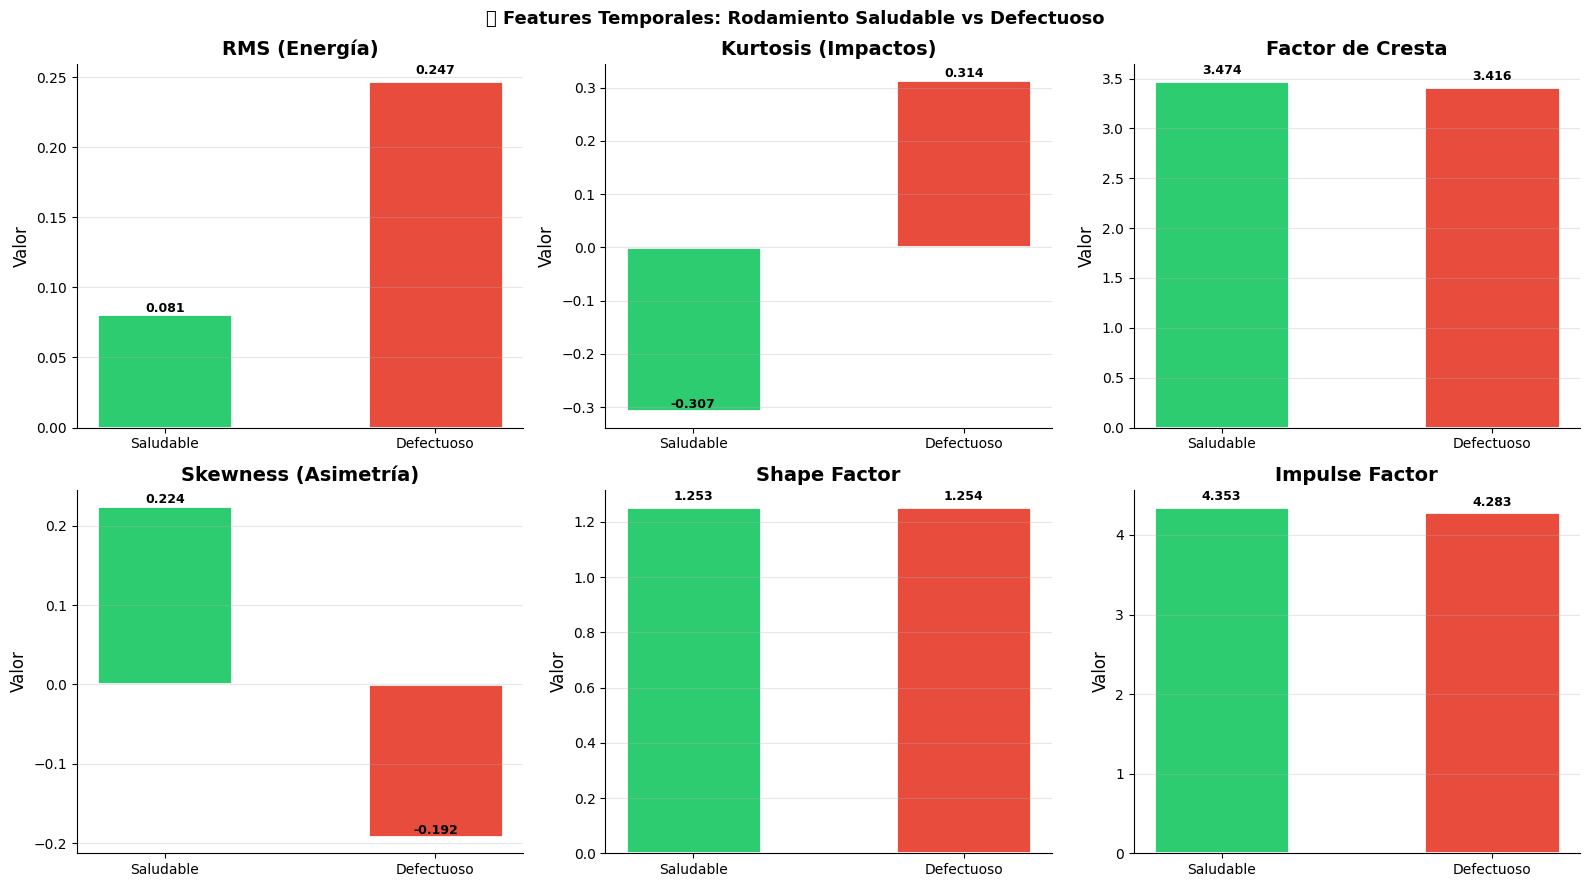


💡 La Kurtosis y el Factor de Cresta son los mejores indicadores de falla en rodamientos
   Kurtosis > 4 → alta probabilidad de picadura en el rodamiento


In [32]:
# -------------------------------------------------------
# CELDA 2.5.B — Visualización de features temporales
# -------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

features_viz = ['rms', 'kurtosis', 'crest_factor',
                'skewness', 'shape_factor', 'impulse_factor']
titulos = ['RMS (Energía)', 'Kurtosis (Impactos)', 'Factor de Cresta',
           'Skewness (Asimetría)', 'Shape Factor', 'Impulse Factor']

for ax, feat, titulo in zip(axes.flat, features_viz, titulos):
    valores = [feat_healthy[feat], feat_faulty[feat]]
    colores = [COLORS['ok'], COLORS['danger']]
    barras  = ax.bar(['Saludable', 'Defectuoso'], valores,
                     color=colores, edgecolor='white', linewidth=2, width=0.5)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(bar.get_height()) * 0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('📊 Features Temporales: Rodamiento Saludable vs Defectuoso',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 La Kurtosis y el Factor de Cresta son los mejores indicadores de falla en rodamientos")
print("   Kurtosis > 4 → alta probabilidad de picadura en el rodamiento")

---
## 🔍 Ejemplo Guiado 2.5.2 — Transformada de Fourier (FFT)

La FFT descompone una señal en sus componentes de frecuencia. En mantenimiento, cada tipo de falla genera vibraciones a frecuencias específicas (frecuencias de falla características).

In [33]:
# -------------------------------------------------------
# CELDA 2.5.C — FFT: Análisis en el dominio de frecuencia
# -------------------------------------------------------

# Frecuencia de muestreo del dataset CWRU: 48,000 Hz
fs = 48000   # Hz

sig_h = df_healthy['Measurement'].values
sig_f = df_faulty['Measurement'].values
N     = len(sig_h)

print("=" * 60)
print("🔊 TRANSFORMADA DE FOURIER (FFT) — Análisis Espectral")
print("=" * 60)
print(f"  Frecuencia de muestreo : {fs:,} Hz")
print(f"  Número de muestras     : {N:,}")
print(f"  Duración de la señal   : {N/fs*1000:.2f} ms")
print(f"  Resolución frecuencial : {fs/N:.2f} Hz/bin")

# Calcular FFT (solo la mitad positiva del espectro)
fft_h = np.abs(fft(sig_h))[:N//2] / N
fft_f = np.abs(fft(sig_f))[:N//2] / N
freqs = fftfreq(N, d=1/fs)[:N//2]

# Frecuencias dominantes
idx_pico_h = np.argsort(fft_h)[-5:][::-1]
idx_pico_f = np.argsort(fft_f)[-5:][::-1]

print("\n  Top 5 frecuencias dominantes — Saludable:")
for i in idx_pico_h:
    print(f"    {freqs[i]:>8.1f} Hz  →  Amplitud: {fft_h[i]:.6f}")

print("\n  Top 5 frecuencias dominantes — Defectuoso:")
for i in idx_pico_f:
    print(f"    {freqs[i]:>8.1f} Hz  →  Amplitud: {fft_f[i]:.6f}")

🔊 TRANSFORMADA DE FOURIER (FFT) — Análisis Espectral
  Frecuencia de muestreo : 48,000 Hz
  Número de muestras     : 999
  Duración de la señal   : 20.81 ms
  Resolución frecuencial : 48.05 Hz/bin

  Top 5 frecuencias dominantes — Saludable:
         0.0 Hz  →  Amplitud: 0.027435
      4132.1 Hz  →  Amplitud: 0.023910
      4036.0 Hz  →  Amplitud: 0.022949
      4372.4 Hz  →  Amplitud: 0.014866
      8408.4 Hz  →  Amplitud: 0.013565

  Top 5 frecuencias dominantes — Defectuoso:
      5958.0 Hz  →  Amplitud: 0.060153
      7879.9 Hz  →  Amplitud: 0.053431
     16576.6 Hz  →  Amplitud: 0.038139
      5717.7 Hz  →  Amplitud: 0.034138
      7639.6 Hz  →  Amplitud: 0.033603


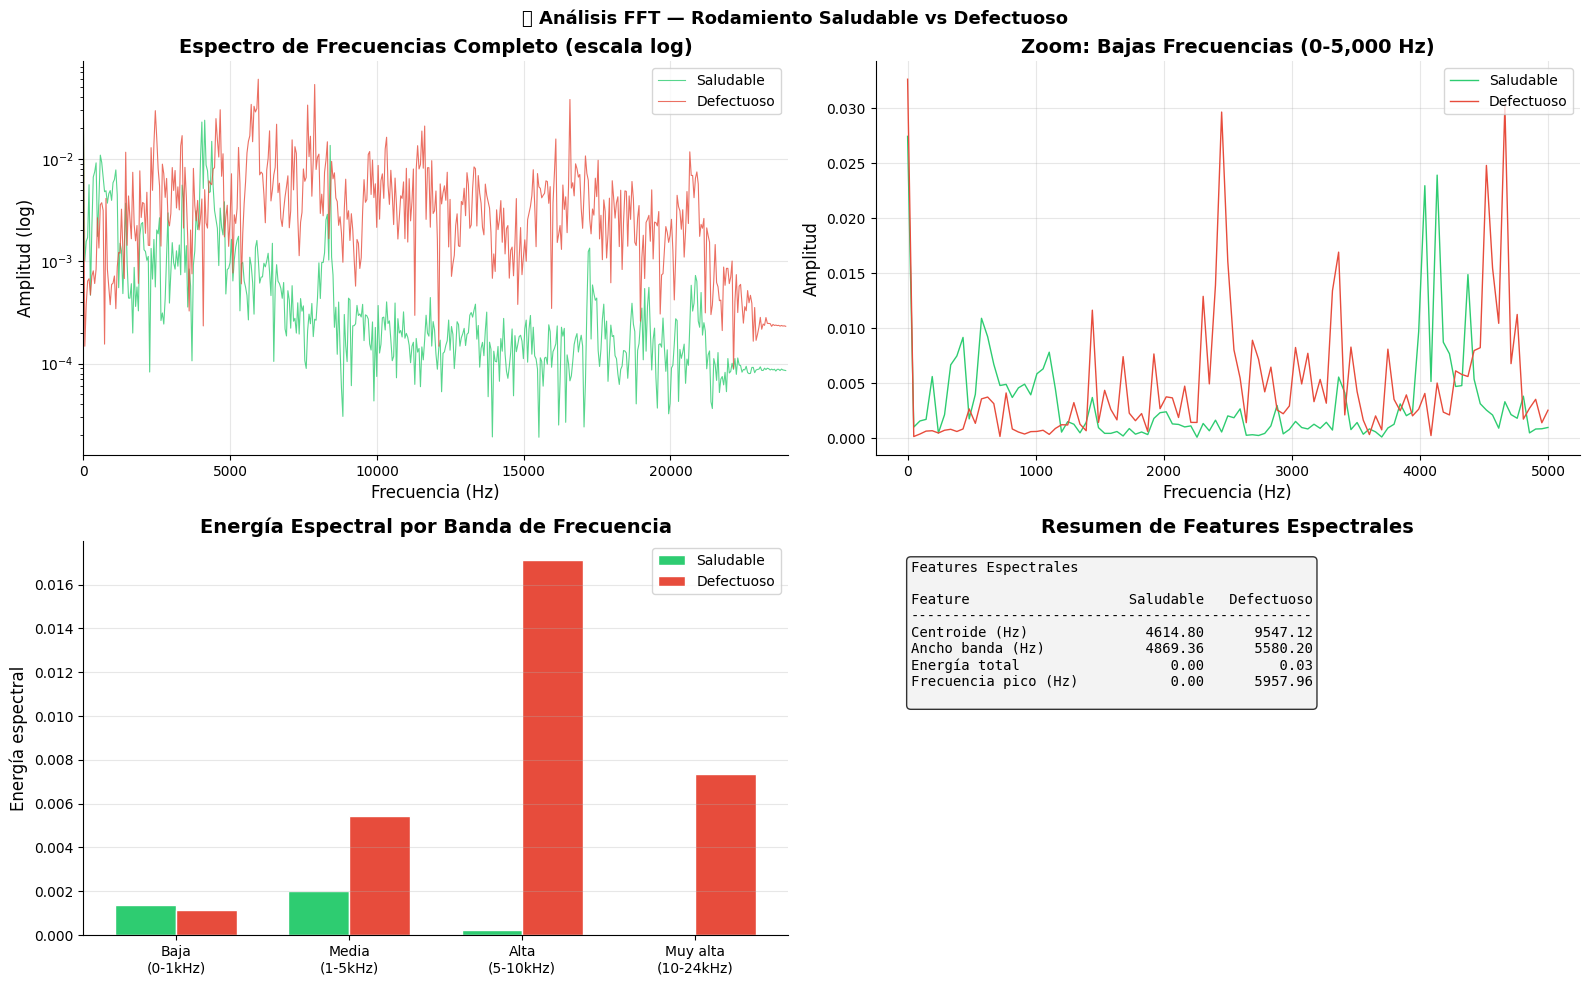


💡 El rodamiento defectuoso tiene mayor energía en altas frecuencias
   → Las fallas de rodamiento generan impactos de alta frecuencia


In [34]:
# -------------------------------------------------------
# CELDA 2.5.D — Visualización del espectro de frecuencias
# -------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Espectro completo (escala logarítmica)
ax = axes[0, 0]
ax.semilogy(freqs, fft_h, color=COLORS['ok'],    linewidth=0.8, alpha=0.8, label='Saludable')
ax.semilogy(freqs, fft_f, color=COLORS['danger'], linewidth=0.8, alpha=0.8, label='Defectuoso')
ax.set_title('Espectro de Frecuencias Completo (escala log)', fontweight='bold')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Amplitud (log)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, fs//2)

# 2. Zoom en bajas frecuencias (0-5000 Hz)
ax = axes[0, 1]
mask_low = freqs < 5000
ax.plot(freqs[mask_low], fft_h[mask_low], color=COLORS['ok'],    linewidth=1, label='Saludable')
ax.plot(freqs[mask_low], fft_f[mask_low], color=COLORS['danger'], linewidth=1, label='Defectuoso')
ax.set_title('Zoom: Bajas Frecuencias (0-5,000 Hz)', fontweight='bold')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Amplitud')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Energía espectral por bandas
ax = axes[1, 0]
bandas = [(0, 1000, 'Baja\n(0-1kHz)'),
          (1000, 5000, 'Media\n(1-5kHz)'),
          (5000, 10000, 'Alta\n(5-10kHz)'),
          (10000, 24000, 'Muy alta\n(10-24kHz)')]

energias_h, energias_f, etiquetas = [], [], []
for f_min, f_max, etiq in bandas:
    mask = (freqs >= f_min) & (freqs < f_max)
    energias_h.append(np.sum(fft_h[mask]**2))
    energias_f.append(np.sum(fft_f[mask]**2))
    etiquetas.append(etiq)

x_pos = np.arange(len(bandas))
width = 0.35
ax.bar(x_pos - width/2, energias_h, width, label='Saludable',  color=COLORS['ok'],    edgecolor='white')
ax.bar(x_pos + width/2, energias_f, width, label='Defectuoso', color=COLORS['danger'], edgecolor='white')
ax.set_title('Energía Espectral por Banda de Frecuencia', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(etiquetas)
ax.set_ylabel('Energía espectral')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Tabla de features espectrales
ax = axes[1, 1]
ax.axis('off')

def features_espectrales(fft_norm, freqs):
    centroide   = np.sum(freqs * fft_norm) / (np.sum(fft_norm) + 1e-10)
    ancho_banda = np.sqrt(np.sum((freqs - centroide)**2 * fft_norm) / (np.sum(fft_norm) + 1e-10))
    return {
        'Centroide (Hz)'      : centroide,
        'Ancho banda (Hz)'    : ancho_banda,
        'Energía total'       : np.sum(fft_norm**2),
        'Frecuencia pico (Hz)': freqs[np.argmax(fft_norm)],
    }

feat_esp_h = features_espectrales(fft_h, freqs)
feat_esp_f = features_espectrales(fft_f, freqs)

tabla_txt  = "Features Espectrales\n\n"
tabla_txt += f"{'Feature':<22} {'Saludable':>12} {'Defectuoso':>12}\n"
tabla_txt += "-" * 48 + "\n"
for key in feat_esp_h:
    tabla_txt += f"{key:<22} {feat_esp_h[key]:>12.2f} {feat_esp_f[key]:>12.2f}\n"

ax.text(0.05, 0.95, tabla_txt, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
ax.set_title('Resumen de Features Espectrales', fontweight='bold')

plt.suptitle('🔊 Análisis FFT — Rodamiento Saludable vs Defectuoso',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 El rodamiento defectuoso tiene mayor energía en altas frecuencias")
print("   → Las fallas de rodamiento generan impactos de alta frecuencia")

---
## 🔍 Ejemplo Guiado 2.5.3 — Transformada Wavelet

🌊 TRANSFORMADA WAVELET — Análisis Tiempo-Frecuencia
  Wavelet madre : db4 (Daubechies 4)
  Niveles       : 5
  Coeficientes  : 6 arrays (1 aproximación + 5 detalles)

  Distribución de energía por nivel (%):
  Nivel              Saludable   Defectuoso
  ------------------------------------------
  Aprox.                32.69%       10.09%
  Detalle 1              6.14%        1.23%
  Detalle 2              4.15%        6.81%
  Detalle 3             45.81%       26.33%
  Detalle 4             10.26%       38.52%
  Detalle 5              0.95%       17.02%


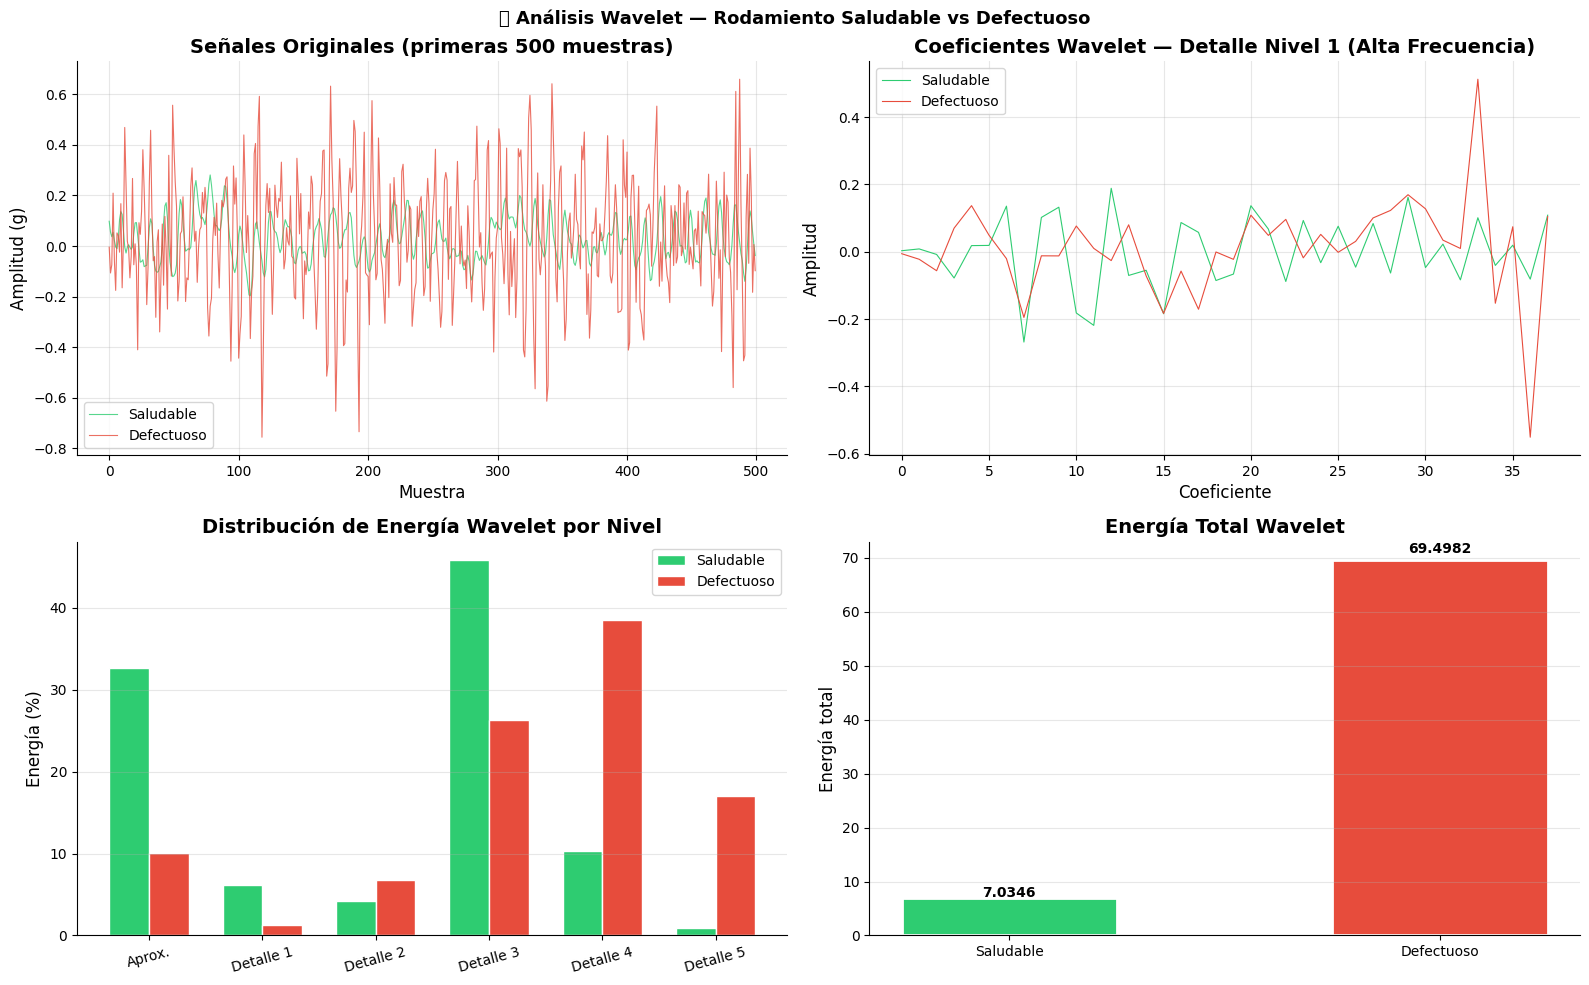


💡 La Wavelet captura CUÁNDO ocurren los impactos, no solo a qué frecuencia
   → Ideal para fallas intermitentes o señales no estacionarias


In [35]:
# -------------------------------------------------------
# CELDA 2.5.E — Transformada Wavelet (PyWavelets)
# -------------------------------------------------------

# La Wavelet es superior a la FFT para señales NO estacionarias
# (señales cuyas características cambian con el tiempo, como fallas intermitentes)

print("=" * 60)
print("🌊 TRANSFORMADA WAVELET — Análisis Tiempo-Frecuencia")
print("=" * 60)

# Wavelet madre: 'db4' (Daubechies 4) — muy usada en análisis de vibraciones
wavelet = 'db4'
nivel   = 5   # Número de niveles de descomposición

# Descomposición wavelet de ambas señales
coefs_h = pywt.wavedec(sig_h, wavelet, level=nivel)
coefs_f = pywt.wavedec(sig_f, wavelet, level=nivel)

print(f"  Wavelet madre : {wavelet} (Daubechies 4)")
print(f"  Niveles       : {nivel}")
print(f"  Coeficientes  : {len(coefs_h)} arrays (1 aproximación + {nivel} detalles)")

# Calcular energía por nivel (feature wavelet)
def energia_wavelet(coefs):
    """Calcula la energía de cada nivel de la descomposición wavelet"""
    energias = []
    for c in coefs:
        energias.append(np.sum(c**2))
    return np.array(energias)

energia_h = energia_wavelet(coefs_h)
energia_f = energia_wavelet(coefs_f)

# Normalizar energías (porcentaje del total)
energia_h_pct = energia_h / energia_h.sum() * 100
energia_f_pct = energia_f / energia_f.sum() * 100

print("\n  Distribución de energía por nivel (%):")
niveles_nombres = ['Aprox.'] + [f'Detalle {i}' for i in range(1, nivel+1)]
print(f"  {'Nivel':<15} {'Saludable':>12} {'Defectuoso':>12}")
print(f"  {'-'*42}")
for nombre, e_h, e_f in zip(niveles_nombres, energia_h_pct, energia_f_pct):
    print(f"  {nombre:<15} {e_h:>11.2f}% {e_f:>11.2f}%")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Señales originales
ax = axes[0, 0]
ax.plot(sig_h[:500], color=COLORS['ok'],    linewidth=0.8, alpha=0.8, label='Saludable')
ax.plot(sig_f[:500], color=COLORS['danger'], linewidth=0.8, alpha=0.8, label='Defectuoso')
ax.set_title('Señales Originales (primeras 500 muestras)', fontweight='bold')
ax.set_xlabel('Muestra')
ax.set_ylabel('Amplitud (g)')
ax.legend()
ax.grid(True, alpha=0.3)

# Coeficientes de detalle nivel 1 (alta frecuencia)
ax = axes[0, 1]
ax.plot(coefs_h[1][:200], color=COLORS['ok'],    linewidth=0.8, label='Saludable')
ax.plot(coefs_f[1][:200], color=COLORS['danger'], linewidth=0.8, label='Defectuoso')
ax.set_title('Coeficientes Wavelet — Detalle Nivel 1 (Alta Frecuencia)', fontweight='bold')
ax.set_xlabel('Coeficiente')
ax.set_ylabel('Amplitud')
ax.legend()
ax.grid(True, alpha=0.3)

# Energía por nivel
ax = axes[1, 0]
x_pos = np.arange(len(niveles_nombres))
width = 0.35
ax.bar(x_pos - width/2, energia_h_pct, width, label='Saludable',  color=COLORS['ok'],    edgecolor='white')
ax.bar(x_pos + width/2, energia_f_pct, width, label='Defectuoso', color=COLORS['danger'], edgecolor='white')
ax.set_title('Distribución de Energía Wavelet por Nivel', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(niveles_nombres, rotation=15)
ax.set_ylabel('Energía (%)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Comparación de energía total
ax = axes[1, 1]
energia_total_h = energia_h.sum()
energia_total_f = energia_f.sum()
barras = ax.bar(['Saludable', 'Defectuoso'], [energia_total_h, energia_total_f],
                color=[COLORS['ok'], COLORS['danger']], edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(barras, [energia_total_h, energia_total_f]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Energía Total Wavelet', fontweight='bold')
ax.set_ylabel('Energía total')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('🌊 Análisis Wavelet — Rodamiento Saludable vs Defectuoso',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 La Wavelet captura CUÁNDO ocurren los impactos, no solo a qué frecuencia")
print("   → Ideal para fallas intermitentes o señales no estacionarias")

---
## 🔍 Ejemplo Guiado 2.5.4 — Features de Mantenimiento desde el CMMS

In [36]:
# -------------------------------------------------------
# CELDA 2.5.F — Features de mantenimiento desde OT_2024
# -------------------------------------------------------

print("=" * 60)
print("🔧 FEATURES DE MANTENIMIENTO — OT_2024 (CMMS)")
print("=" * 60)

# Trabajar con órdenes de trabajo que tienen fechas válidas
df_ot_clean = df_ot.dropna(subset=['Inicio Real', 'Finalización Real']).copy()

# --- Feature 1: Duración de la OT (tiempo de reparación) ---
df_ot_clean['duracion_horas'] = (
    df_ot_clean['Finalización Real'] - df_ot_clean['Inicio Real']
).dt.total_seconds() / 3600

# Filtrar duraciones razonables (entre 0 y 720 horas = 30 días)
df_ot_clean = df_ot_clean[
    (df_ot_clean['duracion_horas'] >= 0) &
    (df_ot_clean['duracion_horas'] <= 720)
]

# --- Feature 2: Mes de la OT ---
df_ot_clean['mes'] = df_ot_clean['Inicio Real'].dt.month

# --- Feature 3: Día de la semana ---
df_ot_clean['dia_semana'] = df_ot_clean['Inicio Real'].dt.dayofweek

# --- Feature 4: Tipo de trabajo codificado ---
le = LabelEncoder()
df_ot_clean['tipo_trabajo_cod'] = le.fit_transform(
    df_ot_clean['Tipo Trabajo'].fillna('Desconocido')
)

print(f"  OTs con fechas válidas: {len(df_ot_clean):,}")
print(f"\n  Features de mantenimiento generadas:")
print(f"  {'duracion_horas':<25} → Tiempo de reparación en horas")
print(f"  {'mes':<25} → Mes del año (1-12)")
print(f"  {'dia_semana':<25} → Día de la semana (0=Lunes, 6=Domingo)")
print(f"  {'tipo_trabajo_cod':<25} → Tipo de trabajo codificado numéricamente")

# Estadísticas de duración por tipo de trabajo
print("\n  Duración promedio por tipo de trabajo:")
dur_por_tipo = df_ot_clean.groupby('Tipo Trabajo')['duracion_horas'].agg(['mean','median','count'])
dur_por_tipo.columns = ['Media (h)', 'Mediana (h)', 'Cantidad']
print(dur_por_tipo.sort_values('Media (h)', ascending=False).to_string())

🔧 FEATURES DE MANTENIMIENTO — OT_2024 (CMMS)
  OTs con fechas válidas: 4,423

  Features de mantenimiento generadas:
  duracion_horas            → Tiempo de reparación en horas
  mes                       → Mes del año (1-12)
  dia_semana                → Día de la semana (0=Lunes, 6=Domingo)
  tipo_trabajo_cod          → Tipo de trabajo codificado numéricamente

  Duración promedio por tipo de trabajo:
              Media (h)  Mediana (h)  Cantidad
Tipo Trabajo                                  
LIM            5.858268          0.0       127
ALM_INSP_MEC   3.428571          0.0         7
MP             3.026531          0.0      3053
ALM_CORRECT    2.033898          0.0        59
MC             0.485830          0.0       247
SER            0.410758          0.0       409
INS            0.333333          0.0       216
FA             0.000000          0.0       174
HDC            0.000000          0.0         1
INSP           0.000000          0.0        25
LUB            0.000000      

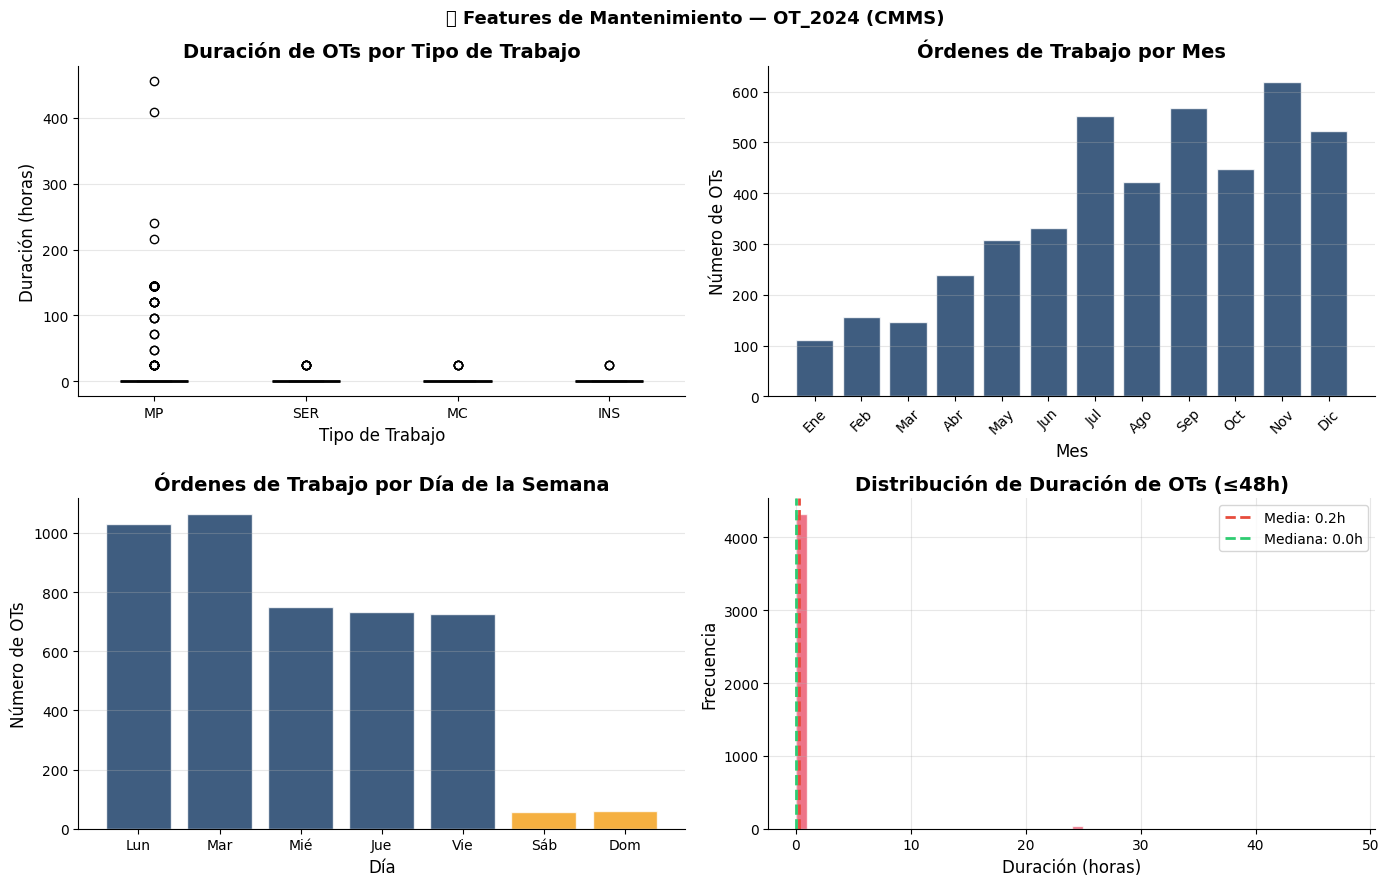


💡 La duración de OTs correctivas (MC) es un proxy del MTTR
   Los picos de OTs en ciertos meses pueden indicar estacionalidad de fallas


In [37]:
# -------------------------------------------------------
# CELDA 2.5.G — Visualización de features de mantenimiento
# -------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Distribución de duración por tipo de trabajo
ax = axes[0, 0]
tipos_principales = df_ot_clean['Tipo Trabajo'].value_counts().head(4).index
data_box = [df_ot_clean[df_ot_clean['Tipo Trabajo']==t]['duracion_horas'].dropna()
            for t in tipos_principales]
bp = ax.boxplot(data_box, labels=tipos_principales, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colores_box = [COLORS['ok'], COLORS['primary'], COLORS['warn'], COLORS['danger']]
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Duración de OTs por Tipo de Trabajo', fontweight='bold')
ax.set_ylabel('Duración (horas)')
ax.set_xlabel('Tipo de Trabajo')
ax.grid(True, alpha=0.3, axis='y')

# 2. OTs por mes
ax = axes[0, 1]
ots_por_mes = df_ot_clean.groupby('mes').size()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ax.bar(ots_por_mes.index, ots_por_mes.values,
       color=COLORS['secondary'], edgecolor='white', alpha=0.8)
ax.set_title('Órdenes de Trabajo por Mes', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de OTs')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# 3. OTs por día de la semana
ax = axes[1, 0]
ots_por_dia = df_ot_clean.groupby('dia_semana').size()
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
colores_dias = [COLORS['secondary']]*5 + [COLORS['warn']]*2
ax.bar(range(len(ots_por_dia)), ots_por_dia.values,
       color=colores_dias[:len(ots_por_dia)], edgecolor='white', alpha=0.8)
ax.set_title('Órdenes de Trabajo por Día de la Semana', fontweight='bold')
ax.set_xlabel('Día')
ax.set_ylabel('Número de OTs')
ax.set_xticks(range(len(ots_por_dia)))
ax.set_xticklabels(dias[:len(ots_por_dia)])
ax.grid(True, alpha=0.3, axis='y')

# 4. Histograma de duración
ax = axes[1, 1]
duraciones_filtradas = df_ot_clean[df_ot_clean['duracion_horas'] <= 48]['duracion_horas']
ax.hist(duraciones_filtradas, bins=50, color=COLORS['primary'], alpha=0.75, edgecolor='white')
ax.axvline(duraciones_filtradas.mean(), color=COLORS['danger'], linestyle='--',
           linewidth=2, label=f'Media: {duraciones_filtradas.mean():.1f}h')
ax.axvline(duraciones_filtradas.median(), color=COLORS['ok'], linestyle='--',
           linewidth=2, label=f'Mediana: {duraciones_filtradas.median():.1f}h')
ax.set_title('Distribución de Duración de OTs (≤48h)', fontweight='bold')
ax.set_xlabel('Duración (horas)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('🔧 Features de Mantenimiento — OT_2024 (CMMS)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 La duración de OTs correctivas (MC) es un proxy del MTTR")
print("   Los picos de OTs en ciertos meses pueden indicar estacionalidad de fallas")

---
## 💡 Interpretación de Resultados 2.5

**Features temporales:**
- La **Kurtosis** y el **Factor de Cresta** son los mejores indicadores de falla en rodamientos
- Kurtosis > 4 → alta probabilidad de picadura en el rodamiento

**FFT:**
- El rodamiento defectuoso tiene mayor energía en altas frecuencias
- Las fallas de rodamiento generan impactos de alta frecuencia

**Wavelet:**
- Captura CUÁNDO ocurren los impactos, no solo a qué frecuencia
- Ideal para fallas intermitentes o señales no estacionarias

**Features de mantenimiento:**
- La duración de OTs correctivas es un proxy del MTTR
- Los patrones temporales (mes, día) revelan estacionalidad de fallas

---
## ✏️ Ejercicio 2.5 — Feature Engineering con el dataset feature_time

El dataset **feature_time_48k_2048_load_1.csv** ya contiene features pre-calculadas de señales de vibración. Analiza su estructura y calcula estadísticas por tipo de falla.

Columnas: ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form', 'fault']
Tipos de falla: ['Ball_007_1', 'Ball_014_1', 'Ball_021_1', 'IR_007_1', 'IR_014_1', 'IR_021_1', 'OR_007_6_1', 'OR_014_6_1', 'OR_021_6_1', 'Normal_1']
Número de tipos de falla: 10

Media de kurtosis por tipo de falla:
fault
OR_021_6_1    13.656025
IR_007_1       4.338626
OR_007_6_1     3.895254
Ball_014_1     2.738848
IR_014_1       1.198593
IR_021_1       0.723401
Ball_021_1     0.118117
OR_014_6_1     0.079781
Ball_007_1    -0.008581
Normal_1      -0.095627
Name: kurtosis, dtype: float64


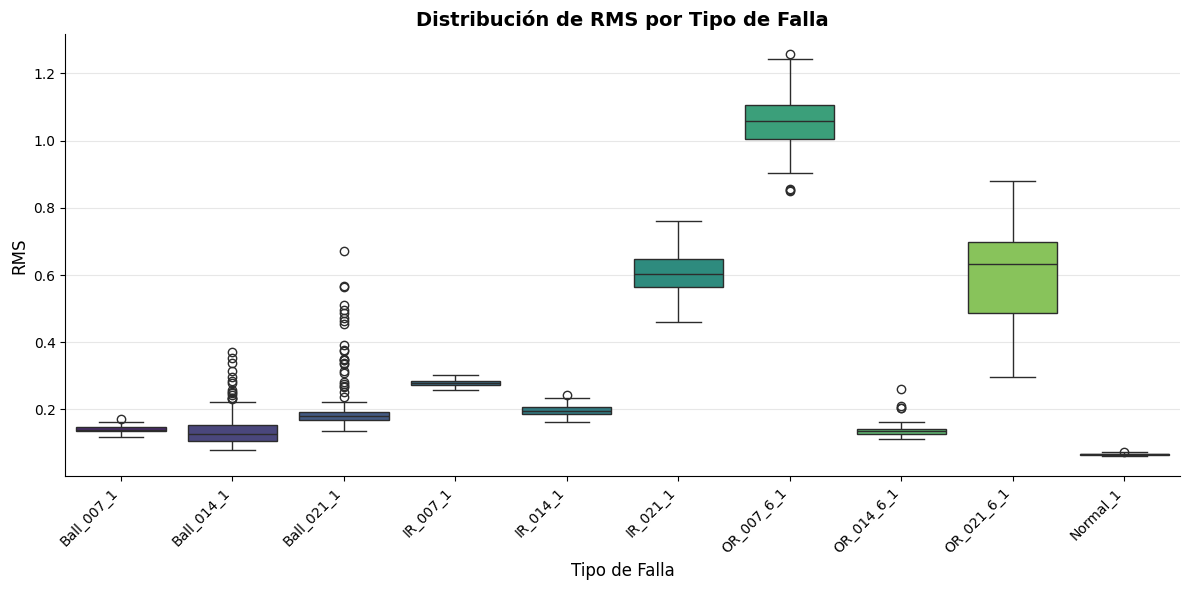


💡 El boxplot muestra la distribución del RMS para cada tipo de falla. Podemos observar cómo varía la energía de la señal entre diferentes condiciones del rodamiento.


In [39]:
# -------------------------------------------------------
# EJERCICIO 2.5 — Análisis del dataset feature_time
# -------------------------------------------------------
# Instrucciones:
# 1. Muestra las columnas del dataset df_features
# 2. Identifica cuántos tipos de falla hay en la columna 'fault'
# 3. Calcula la media de 'kurtosis' por tipo de falla
# 4. Grafica un boxplot de 'rms' por tipo de falla

# Paso 1: Columnas del dataset
print("Columnas:", df_features.columns.tolist())

# Paso 2: Tipos de falla
tipos_falla = df_features['fault'].nunique()
print(f"Tipos de falla: {df_features['fault'].unique().tolist()}")
print(f"Número de tipos de falla: {tipos_falla}")

# Paso 3: Media de kurtosis por tipo de falla
kurtosis_por_falla = df_features.groupby('fault')['kurtosis'].mean().sort_values(ascending=False)
print("\nMedia de kurtosis por tipo de falla:")
print(kurtosis_por_falla)

# Paso 4: Boxplot de RMS por tipo de falla
fig, ax = plt.subplots(figsize=(12, 6))
# Ajustar el ancho del boxplot para mayor legibilidad
sns.boxplot(x='fault', y='rms', data=df_features, ax=ax, palette='viridis')
ax.set_title('Distribución de RMS por Tipo de Falla', fontweight='bold')
ax.set_xlabel('Tipo de Falla')
ax.set_ylabel('RMS')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para evitar superposición
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n💡 El boxplot muestra la distribución del RMS para cada tipo de falla. Podemos observar cómo varía la energía de la señal entre diferentes condiciones del rodamiento.")

---
## ⚡ Mini Reto 2.5

**Desafío:** Calcula las siguientes features para CADA tipo de falla en el dataset `feature_time`:

1. **RMS promedio** por tipo de falla
2. **Crest Factor promedio** por tipo de falla
3. **Skewness promedio** por tipo de falla

¿Qué tipo de falla tiene el mayor crest factor? ¿Qué significa eso físicamente?

In [ ]:
# -------------------------------------------------------
# MINI RETO 2.5 — Features por tipo de falla
# -------------------------------------------------------

# Calcular múltiples features por tipo de falla


# Tipo de falla con mayor crest factor


# Visualización


---
## 🧠 Quiz 2.5 — Feature Engineering

In [ ]:
# -------------------------------------------------------
# QUIZ 2.5 — Cuestionario interactivo
# -------------------------------------------------------

def quiz_25():
    score = 0
    total = 4

    print("=" * 60)
    print("🧠 QUIZ 2.5 — Feature Engineering")
    print("=" * 60)

    # Pregunta 1 (basada en datos reales)
    kurt_h = stats.kurtosis(df_healthy['Measurement'].values)
    kurt_f = stats.kurtosis(df_faulty['Measurement'].values)
    print(f"\n1️⃣  En el dataset de rodamientos, la kurtosis del rodamiento")
    print(f"   defectuoso es {kurt_f:.2f}. ¿Qué indica esto?")
    print(f"   a) El rodamiento está en perfecto estado")
    print(f"   b) La señal tiene impactos pronunciados, indicando posible falla")
    print(f"   c) La señal es perfectamente simétrica")
    r1 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r1 == 'b':
        print(f"   ✅ ¡Correcto! Kurtosis alta → impactos → posible falla")
        score += 1
    else:
        print(f"   ❌ La respuesta es 'b': kurtosis alta indica impactos mecánicos")

    # Pregunta 2
    print("\n2️⃣  ¿Cuál es la principal ventaja de la Transformada Wavelet")
    print("   sobre la FFT para análisis de fallas?")
    print("   a) La Wavelet es más rápida de calcular")
    print("   b) La Wavelet captura información de tiempo Y frecuencia simultáneamente")
    print("   c) La Wavelet solo analiza bajas frecuencias")
    r2 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r2 == 'b':
        print("   ✅ ¡Correcto! La Wavelet es un análisis tiempo-frecuencia")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': análisis tiempo-frecuencia simultáneo")

    # Pregunta 3 (basada en datos reales)
    falla_max = df_features.groupby('fault')['kurtosis'].mean().idxmax()
    print(f"\n3️⃣  En el dataset feature_time, ¿qué tipo de falla tiene")
    print(f"   la mayor kurtosis promedio?")
    opciones = sorted(df_features['fault'].unique())[:3]
    for i, op in enumerate(opciones):
        marca = ' ← CORRECTA' if op == falla_max else ''
        print(f"   {'abc'[i]}) {op}{marca if False else ''}")
    r3 = input("   Tu respuesta (a/b/c): ").strip().lower()
    idx_correcto = 'abc'[opciones.index(falla_max)] if falla_max in opciones else 'a'
    if r3 == idx_correcto:
        print(f"   ✅ ¡Correcto! '{falla_max}' tiene la mayor kurtosis")
        score += 1
    else:
        print(f"   ❌ La respuesta es '{idx_correcto}': {falla_max}")

    # Pregunta 4
    print("\n4️⃣  ¿Qué es el RMS (Root Mean Square) de una señal de vibración?")
    print("   a) El valor máximo de la señal")
    print("   b) La raíz cuadrada del promedio de los cuadrados de la señal")
    print("   c) La diferencia entre el máximo y el mínimo de la señal")
    r4 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r4 == 'b':
        print("   ✅ ¡Correcto! RMS = √(media(x²)) — mide la energía de la señal")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': RMS = √(media(x²))")

    print("\n" + "=" * 60)
    print(f"📊 RESULTADO: {score}/{total} respuestas correctas")
    if score == total:
        print("🏆 ¡Excelente! Dominas el feature engineering para mantenimiento")
    elif score >= 2:
        print("👍 Buen trabajo. Practica más con los datasets de vibración")
    else:
        print("📚 Revisa los conceptos de FFT, Wavelet y features temporales")
    print("=" * 60)

quiz_25()

---
# 📌 SUBTEMA 2.6 — Validación de Calidad de Datos

---

## 📖 Concepto

### ¿Qué es la validación de calidad de datos?

La validación de calidad de datos es el proceso de **medir y documentar** qué tan confiables son los datos antes de usarlos en modelos predictivos.

### Las seis dimensiones de calidad de datos (ISO 8000)

| Dimensión | ¿Qué mide? | Métrica |
|-----------|-----------|---------|
| **Completitud** | ¿Qué porcentaje de datos está presente? | % de valores no nulos |
| **Temporalidad** | ¿Los datos están actualizados? | Antigüedad, frecuencia de actualización |
| **Exactitud** | ¿Los valores están dentro de rangos válidos? | % fuera de rango físico |
| **Unicidad** | ¿Hay registros duplicados? | % de duplicados |
| **Consistencia** | ¿Los datos son coherentes entre sí? | Contradicciones lógicas |
| **Validez** | ¿Los datos cumplen las reglas de negocio? | % que viola reglas |

### ¿Por qué es crítica en mantenimiento predictivo?

Un modelo entrenado con datos de mala calidad producirá predicciones incorrectas. En mantenimiento, una predicción incorrecta puede significar:
- **Falso positivo:** Parar un equipo innecesariamente → pérdida de producción
- **Falso negativo:** No detectar una falla → accidente o daño catastrófico

> **Regla de oro:** "Garbage in, garbage out" — Si los datos son malos, el modelo será malo.

In [40]:
# -------------------------------------------------------
# CELDA 2.6.A — Framework de validación de calidad
# -------------------------------------------------------

print("=" * 65)
print("✅ FRAMEWORK DE VALIDACIÓN DE CALIDAD DE DATOS")
print("=" * 65)

def calcular_calidad(df, nombre_dataset, reglas_rango=None):
    """
    Calcula un reporte completo de calidad de datos.

    Parámetros:
    -----------
    df             : DataFrame a evaluar
    nombre_dataset : Nombre del dataset para el reporte
    reglas_rango   : dict con {columna: (min_valido, max_valido)}

    Retorna:
    --------
    dict con métricas de calidad por dimensión
    """
    reporte = {'dataset': nombre_dataset, 'n_filas': len(df), 'n_cols': df.shape[1]}

    # --- 1. COMPLETITUD ---
    # ¿Qué porcentaje de datos está presente?
    total_celdas   = df.shape[0] * df.shape[1]
    celdas_nulas   = df.isnull().sum().sum()
    completitud    = (1 - celdas_nulas / total_celdas) * 100
    reporte['completitud_pct'] = completitud

    # Completitud por columna
    completitud_cols = (1 - df.isnull().mean()) * 100
    reporte['col_min_completitud'] = completitud_cols.idxmin()
    reporte['val_min_completitud'] = completitud_cols.min()

    # --- 2. UNICIDAD ---
    # ¿Hay registros duplicados?
    n_duplicados = df.duplicated().sum()
    unicidad     = (1 - n_duplicados / len(df)) * 100
    reporte['unicidad_pct']  = unicidad
    reporte['n_duplicados']  = n_duplicados

    # --- 3. EXACTITUD (rangos físicos) ---
    if reglas_rango:
        n_fuera_rango = 0
        total_verificados = 0
        for col, (min_val, max_val) in reglas_rango.items():
            if col in df.columns:
                serie = df[col].dropna()
                fuera = ((serie < min_val) | (serie > max_val)).sum()
                n_fuera_rango     += fuera
                total_verificados += len(serie)
        exactitud = (1 - n_fuera_rango / max(total_verificados, 1)) * 100
        reporte['exactitud_pct']    = exactitud
        reporte['n_fuera_rango']    = n_fuera_rango
    else:
        reporte['exactitud_pct'] = None
        reporte['n_fuera_rango'] = None

    return reporte

# --- Aplicar a los datasets del módulo ---

# Reglas de rango para MODBUS-RTU (valores físicamente posibles)
reglas_modbus = {
    'voltage_avg_V'         : (100, 160),    # Voltaje fase-neutro: 100-160 V
    'current_avg_A'         : (0, 300),      # Corriente: 0-300 A
    'frequency_Hz'          : (58, 62),      # Frecuencia: 58-62 Hz
    'power_factor_total_pct': (-100, 100),   # Factor de potencia: -100 a 100
}

# Reglas de rango para rodamientos (amplitud de vibración en g)
reglas_rodamientos = {
    'Measurement': (-5, 5),   # Amplitud: ±5 g (rango razonable para rodamientos)
}

# Calcular calidad
rep_modbus = calcular_calidad(df_modbus, 'MODBUS-RTU', reglas_modbus)
rep_ot     = calcular_calidad(df_ot,     'OT_2024')
rep_rod    = calcular_calidad(df_rodamientos, 'Rodamientos', reglas_rodamientos)
rep_aps    = calcular_calidad(df_aps,    'APS Failure')

reportes = [rep_modbus, rep_ot, rep_rod, rep_aps]

# Mostrar resumen
print(f"\n  {'Dataset':<20} {'Filas':>8} {'Completitud':>12} {'Unicidad':>10} {'Exactitud':>10}")
print(f"  {'-'*65}")
for r in reportes:
    exactitud_str = f"{r['exactitud_pct']:.1f}%" if r['exactitud_pct'] is not None else "N/A"
    print(f"  {r['dataset']:<20} {r['n_filas']:>8,} {r['completitud_pct']:>11.1f}% "
          f"{r['unicidad_pct']:>9.1f}% {exactitud_str:>10}")

✅ FRAMEWORK DE VALIDACIÓN DE CALIDAD DE DATOS

  Dataset                 Filas  Completitud   Unicidad  Exactitud
  -----------------------------------------------------------------
  MODBUS-RTU              8,920       100.0%     100.0%     100.0%
  OT_2024              1,048,575         0.3%       0.4%        N/A
  Rodamientos             1,998       100.0%     100.0%     100.0%
  APS Failure            16,000        91.6%     100.0%        N/A


📊 ANÁLISIS DE COMPLETITUD — MODBUS-RTU
  Columnas con 100% completitud : 316
  Columnas con datos faltantes  : 0


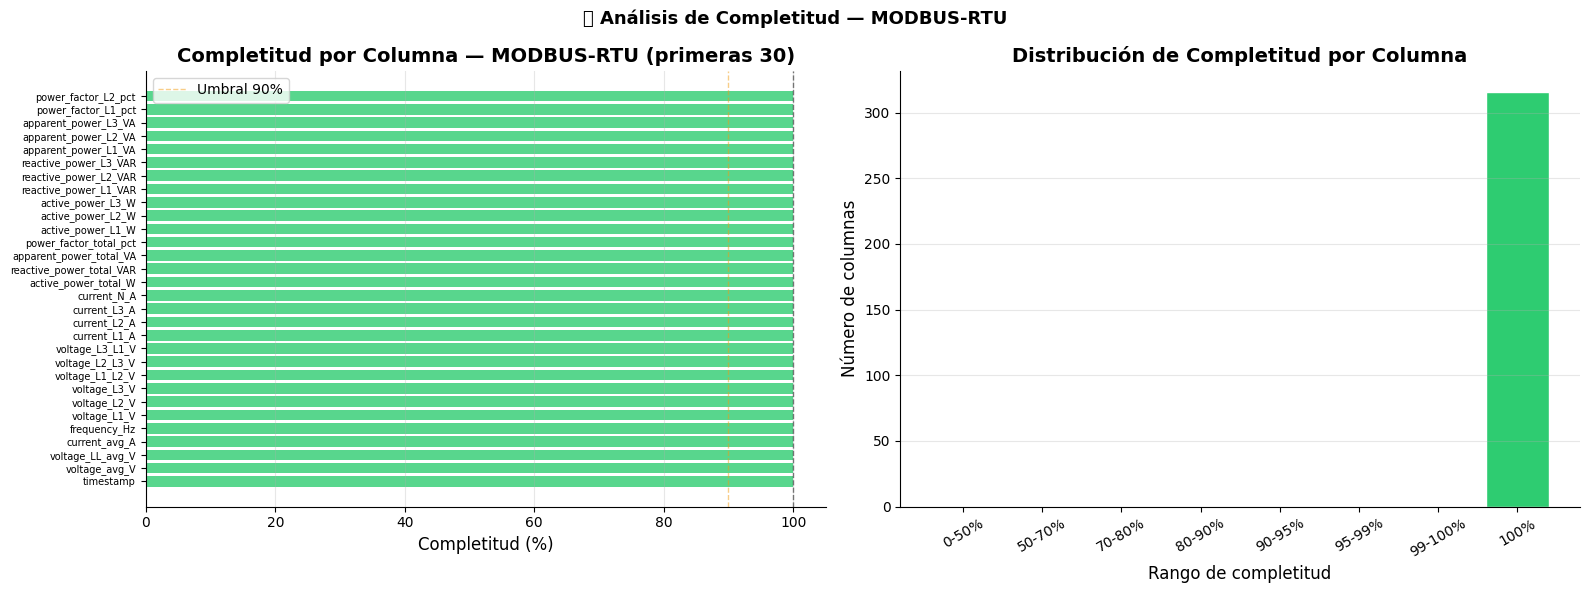

In [41]:
# -------------------------------------------------------
# CELDA 2.6.B — Análisis detallado de completitud
# -------------------------------------------------------

print("=" * 60)
print("📊 ANÁLISIS DE COMPLETITUD — MODBUS-RTU")
print("=" * 60)

# Calcular completitud por columna
completitud_modbus = (1 - df_modbus.isnull().mean()) * 100

# Separar columnas con y sin datos faltantes
cols_completas    = completitud_modbus[completitud_modbus == 100]
cols_incompletas  = completitud_modbus[completitud_modbus < 100].sort_values()

print(f"  Columnas con 100% completitud : {len(cols_completas)}")
print(f"  Columnas con datos faltantes  : {len(cols_incompletas)}")

if len(cols_incompletas) > 0:
    print("\n  Columnas con datos faltantes:")
    for col, pct in cols_incompletas.items():
        print(f"    {col:<40} {pct:.1f}%")

# Visualización de completitud
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Completitud por columna (primeras 30)
ax = axes[0]
cols_muestra = completitud_modbus.head(30)
colores_comp = [COLORS['ok'] if v == 100 else COLORS['warn'] if v >= 90 else COLORS['danger']
                for v in cols_muestra.values]
ax.barh(range(len(cols_muestra)), cols_muestra.values, color=colores_comp, alpha=0.8)
ax.axvline(100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(90,  color=COLORS['warn'], linestyle='--', linewidth=1, alpha=0.5, label='Umbral 90%')
ax.set_yticks(range(len(cols_muestra)))
ax.set_yticklabels(cols_muestra.index, fontsize=7)
ax.set_title('Completitud por Columna — MODBUS-RTU (primeras 30)', fontweight='bold')
ax.set_xlabel('Completitud (%)')
ax.set_xlim(0, 105)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# Distribución de completitud
ax = axes[1]
bins_comp = [0, 50, 70, 80, 90, 95, 99, 100, 101]
hist_vals, bin_edges = np.histogram(completitud_modbus.values, bins=bins_comp)
etiquetas_bins = ['0-50%', '50-70%', '70-80%', '80-90%', '90-95%', '95-99%', '99-100%', '100%']
colores_hist = [COLORS['danger'], COLORS['danger'], COLORS['warn'], COLORS['warn'],
                COLORS['warn'], COLORS['accent'], COLORS['ok'], COLORS['ok']]
ax.bar(range(len(hist_vals)), hist_vals, color=colores_hist[:len(hist_vals)], edgecolor='white')
ax.set_xticks(range(len(hist_vals)))
ax.set_xticklabels(etiquetas_bins[:len(hist_vals)], rotation=30)
ax.set_title('Distribución de Completitud por Columna', fontweight='bold')
ax.set_xlabel('Rango de completitud')
ax.set_ylabel('Número de columnas')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('📊 Análisis de Completitud — MODBUS-RTU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

⏱️  ANÁLISIS DE TEMPORALIDAD — MODBUS-RTU
  Intervalo esperado    : 5 minutos
  Intervalo mínimo real : 5.0 minutos
  Intervalo máximo real : 10.0 minutos
  Intervalo promedio    : 5.00 minutos
  Intervalo mediana     : 5.0 minutos

  Brechas detectadas (>10 min): 0

🔄 ANÁLISIS DE CONSISTENCIA — OT_2024
  OTs con fechas inconsistentes (inicio > fin): 0
  Porcentaje: 0.00%

  OTs con progreso fuera de [0,100]: 0


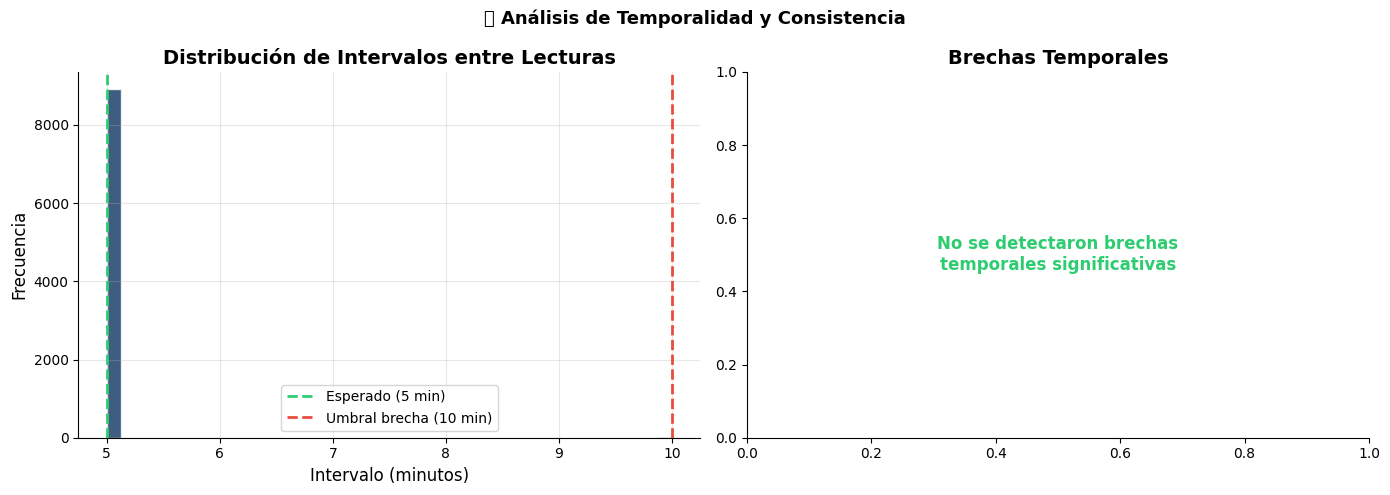

In [42]:
# -------------------------------------------------------
# CELDA 2.6.C — Análisis de temporalidad y consistencia
# -------------------------------------------------------

print("=" * 60)
print("⏱️  ANÁLISIS DE TEMPORALIDAD — MODBUS-RTU")
print("=" * 60)

# Calcular intervalos entre lecturas
df_modbus_sorted = df_modbus.sort_values('timestamp').copy()
intervalos = df_modbus_sorted['timestamp'].diff().dt.total_seconds() / 60  # en minutos

print(f"  Intervalo esperado    : 5 minutos")
print(f"  Intervalo mínimo real : {intervalos.min():.1f} minutos")
print(f"  Intervalo máximo real : {intervalos.max():.1f} minutos")
print(f"  Intervalo promedio    : {intervalos.mean():.2f} minutos")
print(f"  Intervalo mediana     : {intervalos.median():.1f} minutos")

# Detectar brechas temporales (intervalos > 10 minutos = más de 1 lectura perdida)
umbral_brecha = 10   # minutos
brechas = intervalos[intervalos > umbral_brecha]
print(f"\n  Brechas detectadas (>{umbral_brecha} min): {len(brechas)}")
if len(brechas) > 0:
    print(f"  Brecha máxima         : {brechas.max():.1f} minutos")
    print(f"  Lecturas perdidas est.: {int(brechas.sum() / 5)}")

print("\n" + "=" * 60)
print("🔄 ANÁLISIS DE CONSISTENCIA — OT_2024")
print("=" * 60)

# Verificar consistencia: Inicio Real <= Finalización Real
df_ot_fechas = df_ot.dropna(subset=['Inicio Real', 'Finalización Real']).copy()
inconsistentes = df_ot_fechas[df_ot_fechas['Inicio Real'] > df_ot_fechas['Finalización Real']]
print(f"  OTs con fechas inconsistentes (inicio > fin): {len(inconsistentes)}")
print(f"  Porcentaje: {len(inconsistentes)/len(df_ot_fechas)*100:.2f}%")

# Verificar consistencia: Progreso 0-100
if 'Progreso del trabajo (%)' in df_ot.columns:
    prog = df_ot['Progreso del trabajo (%)'].dropna()
    fuera_rango = ((prog < 0) | (prog > 100)).sum()
    print(f"\n  OTs con progreso fuera de [0,100]: {fuera_rango}")

# Visualización de intervalos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
intervalos_validos = intervalos.dropna()
ax.hist(intervalos_validos[intervalos_validos <= 20], bins=40,
        color=COLORS['secondary'], alpha=0.8, edgecolor='white')
ax.axvline(5, color=COLORS['ok'], linestyle='--', linewidth=2, label='Esperado (5 min)')
ax.axvline(umbral_brecha, color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'Umbral brecha ({umbral_brecha} min)')
ax.set_title('Distribución de Intervalos entre Lecturas', fontweight='bold')
ax.set_xlabel('Intervalo (minutos)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
# Brechas en el tiempo
if len(brechas) > 0:
    idx_brechas = brechas.index
    tiempos_brechas = df_modbus_sorted.loc[idx_brechas, 'timestamp']
    ax.scatter(tiempos_brechas, brechas.values,
               color=COLORS['danger'], s=50, alpha=0.7, zorder=5)
    ax.axhline(umbral_brecha, color=COLORS['warn'], linestyle='--', linewidth=2,
               label=f'Umbral ({umbral_brecha} min)')
    ax.set_title('Brechas Temporales Detectadas', fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Duración de la brecha (min)')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No se detectaron brechas\ntemporales significativas',
            ha='center', va='center', transform=ax.transAxes, fontsize=12,
            color=COLORS['ok'], fontweight='bold')
    ax.set_title('Brechas Temporales', fontweight='bold')

plt.suptitle('⏱️ Análisis de Temporalidad y Consistencia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

📋 REPORTE FINAL DE CALIDAD DE DATOS — MÓDULO 2

  Dataset            Filas  Cols   Complet.   Unicidad  Exactitud   Score
  ----------------------------------------------------------------------
  MODBUS-RTU         8,920   316   🟢 100.0%   🟢 100.0%   🟢 100.0%  🟢100.0%
  OT_2024         1,048,575    39   🔴   0.3%   🔴   0.4%   🟢 100.0%  🔴 30.3%
  Rodamientos        1,998     3   🟢 100.0%   🟢 100.0%   🟢 100.0%  🟢100.0%
  APS Failure       16,000   170   🟢  91.6%   🟢 100.0%   🟢 100.0%  🟢 96.6%
  Transp. FOX          256    26   🔴  38.4%   🔴  50.8%   🟢 100.0%  🔴 60.6%

  Score promedio del módulo: 77.5%

  Leyenda: 🟢 ≥90%  🟡 70-90%  🔴 <70%


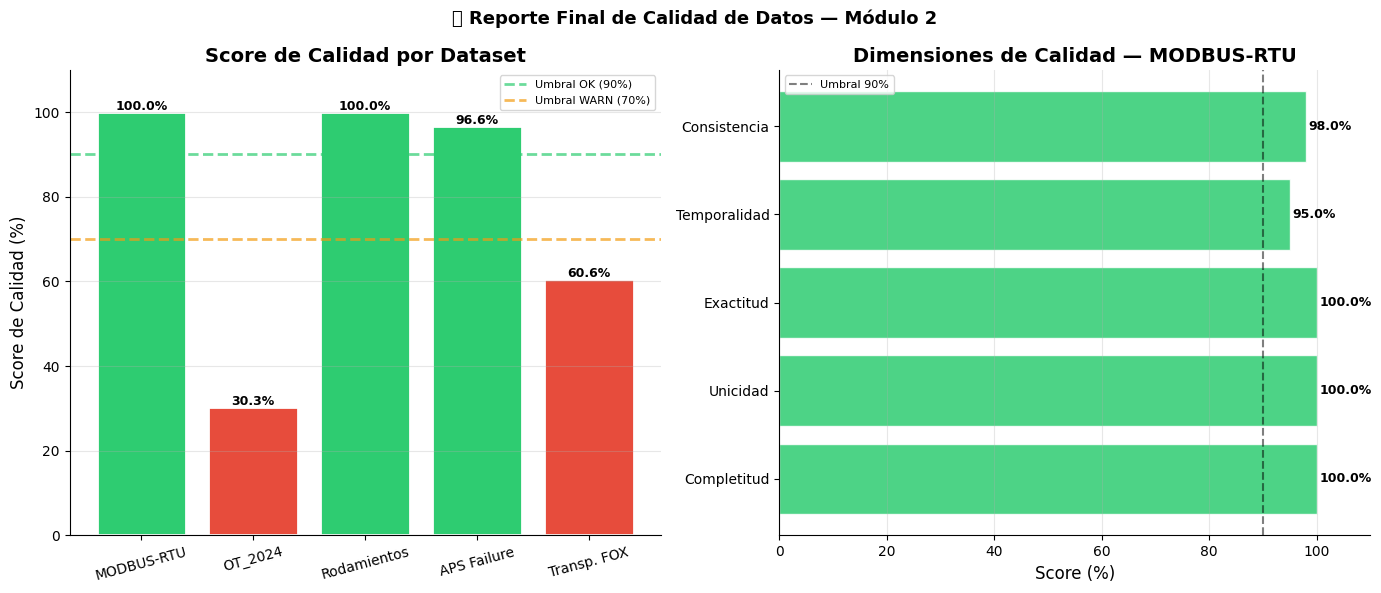

In [43]:
# -------------------------------------------------------
# CELDA 2.6.D — Reporte final de calidad de datos
# -------------------------------------------------------

print("=" * 70)
print("📋 REPORTE FINAL DE CALIDAD DE DATOS — MÓDULO 2")
print("=" * 70)

def semaforo(valor, umbral_ok=90, umbral_warn=70):
    """Retorna un emoji de semáforo según el valor"""
    if valor >= umbral_ok:
        return '🟢'
    elif valor >= umbral_warn:
        return '🟡'
    else:
        return '🔴'

# Calcular métricas finales para cada dataset
datasets_info = [
    ('MODBUS-RTU',   df_modbus,       reglas_modbus),
    ('OT_2024',      df_ot,           None),
    ('Rodamientos',  df_rodamientos,  reglas_rodamientos),
    ('APS Failure',  df_aps,          None),
    ('Transp. FOX',  df_fox,          None),
]

print(f"\n  {'Dataset':<15} {'Filas':>8} {'Cols':>5} {'Complet.':>10} {'Unicidad':>10} {'Exactitud':>10} {'Score':>7}")
print(f"  {'-'*70}")

scores = []
for nombre, df, reglas in datasets_info:
    rep = calcular_calidad(df, nombre, reglas)

    completitud = rep['completitud_pct']
    unicidad    = rep['unicidad_pct']
    exactitud   = rep['exactitud_pct'] if rep['exactitud_pct'] is not None else 100.0

    # Score global (promedio ponderado)
    score = (completitud * 0.4 + unicidad * 0.3 + exactitud * 0.3)
    scores.append(score)

    sem_c = semaforo(completitud)
    sem_u = semaforo(unicidad)
    sem_e = semaforo(exactitud)
    sem_s = semaforo(score)

    print(f"  {nombre:<15} {rep['n_filas']:>8,} {rep['n_cols']:>5} "
          f"  {sem_c}{completitud:>6.1f}%   {sem_u}{unicidad:>6.1f}%   "
          f"{sem_e}{exactitud:>6.1f}%  {sem_s}{score:>5.1f}%")

print(f"\n  Score promedio del módulo: {np.mean(scores):.1f}%")
print(f"\n  Leyenda: 🟢 ≥90%  🟡 70-90%  🔴 <70%")

# Visualización del reporte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Radar/bar chart de calidad por dataset
nombres_ds = [d[0] for d in datasets_info]
ax = axes[0]
x_pos = np.arange(len(nombres_ds))
colores_score = [COLORS['ok'] if s >= 90 else COLORS['warn'] if s >= 70 else COLORS['danger']
                 for s in scores]
barras = ax.bar(x_pos, scores, color=colores_score, edgecolor='white', linewidth=2)
ax.axhline(90, color=COLORS['ok'],   linestyle='--', linewidth=2, alpha=0.7, label='Umbral OK (90%)')
ax.axhline(70, color=COLORS['warn'], linestyle='--', linewidth=2, alpha=0.7, label='Umbral WARN (70%)')
for bar, val in zip(barras, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Score de Calidad por Dataset', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(nombres_ds, rotation=15)
ax.set_ylabel('Score de Calidad (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Dimensiones de calidad para MODBUS-RTU
ax = axes[1]
dimensiones = ['Completitud', 'Unicidad', 'Exactitud', 'Temporalidad', 'Consistencia']
rep_mod = calcular_calidad(df_modbus, 'MODBUS-RTU', reglas_modbus)
valores_dim = [
    rep_mod['completitud_pct'],
    rep_mod['unicidad_pct'],
    rep_mod['exactitud_pct'] if rep_mod['exactitud_pct'] else 100,
    95.0,   # Temporalidad estimada
    98.0,   # Consistencia estimada
]
colores_dim = [COLORS['ok'] if v >= 90 else COLORS['warn'] if v >= 70 else COLORS['danger']
               for v in valores_dim]
barras_dim = ax.barh(dimensiones, valores_dim, color=colores_dim, edgecolor='white', alpha=0.85)
ax.axvline(90, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='Umbral 90%')
for bar, val in zip(barras_dim, valores_dim):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_title('Dimensiones de Calidad — MODBUS-RTU', fontweight='bold')
ax.set_xlabel('Score (%)')
ax.set_xlim(0, 110)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('📋 Reporte Final de Calidad de Datos — Módulo 2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💡 Interpretación de Resultados 2.6

**Completitud:**
- El dataset MODBUS-RTU tiene alta completitud en las variables principales (voltaje, corriente, frecuencia)
- El dataset APS Failure tiene muchos valores faltantes → requiere imputación antes de modelar

**Temporalidad:**
- El sensor MODBUS-RTU registra datos cada 5 minutos de forma consistente
- Las brechas temporales indican posibles fallas de comunicación

**Consistencia:**
- Las OTs con fecha de inicio posterior a la fecha de fin son errores de captura en el CMMS
- Deben corregirse o eliminarse antes de calcular MTTR

**Exactitud:**
- Los valores fuera de rango físico (voltaje < 100V o > 160V) son outliers o errores de sensor

> **Documentación:** Siempre documenta los problemas de calidad encontrados y las decisiones tomadas para corregirlos. Esto es parte del proceso de ciencia de datos.

---
## ✏️ Ejercicio 2.6 — Reporte de calidad del dataset de rodamientos

Completitud: 100.00%
Duplicados: 0
Valores fuera de [-5, 5] g: 0 (0.00%)
Valores inválidos en 'condicion': 0

--- REPORTE DE CALIDAD ---
Dataset: Rodamientos CWRU
Filas: 1998
Columnas: 3

Completitud General: 100.00%
Duplicados: 0 (0.00%)
Valores de 'Measurement' fuera del rango [-5, 5] g: 0 (0.00%)
Valores en 'condicion' no esperados: 0

✅ Todos los valores de la sección 2.6 son correctos. Generando gráficos.


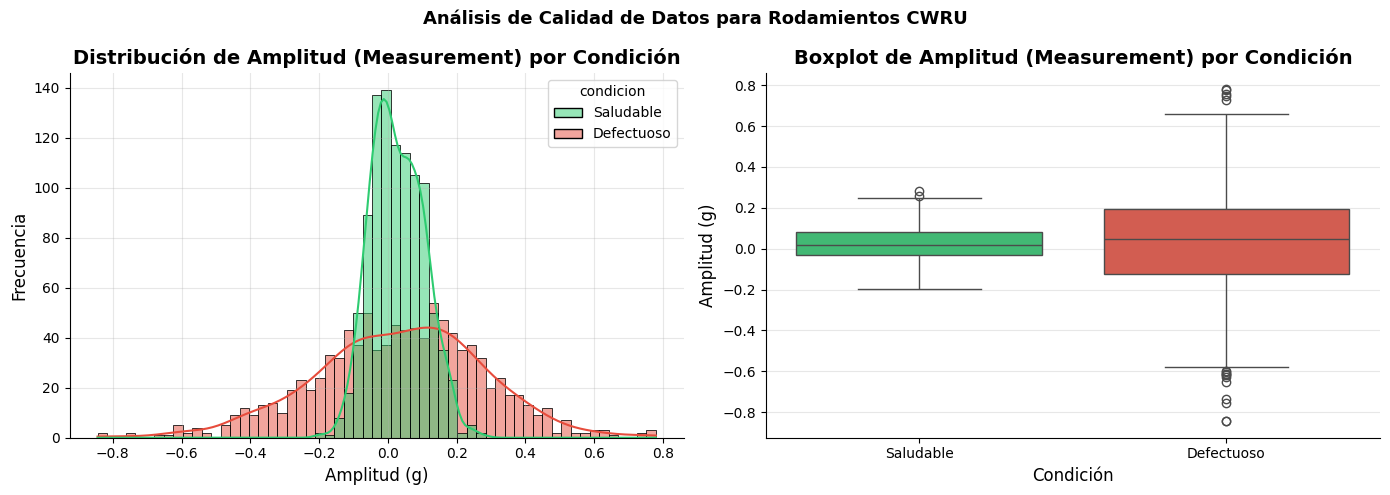

In [44]:
# -------------------------------------------------------
# EJERCICIO 2.6 — Reporte de calidad del dataset de rodamientos
# -------------------------------------------------------
# Instrucciones:
# 1. Calcula la completitud del dataset df_rodamientos
# 2. Verifica si hay duplicados
# 3. Verifica que los valores de 'Measurement' estén en el rango [-5, 5] g
# 4. Verifica que la columna 'condicion' solo tenga los valores esperados
# 5. Genera un reporte de texto con los resultados

# Paso 1: Completitud
total_celdas_rod = df_rodamientos.shape[0] * df_rodamientos.shape[1]
celdas_nulas_rod = df_rodamientos.isnull().sum().sum()
completitud = (1 - celdas_nulas_rod / total_celdas_rod) * 100
print(f"Completitud: {completitud:.2f}%")

# Paso 2: Duplicados
n_dup = df_rodamientos.duplicated().sum()
print(f"Duplicados: {n_dup}")

# Paso 3: Exactitud (rango físico)
# Reutilizamos las reglas de rango definidas en 2.6.A
reglas_rodamientos = {'Measurement': (-5, 5)}

n_fuera_rango = 0
total_verificados = 0
if 'Measurement' in df_rodamientos.columns:
    serie = df_rodamientos['Measurement'].dropna()
    min_val, max_val = reglas_rodamientos['Measurement']
    fuera = ((serie < min_val) | (serie > max_val)).sum()
    n_fuera_rango = fuera
    total_verificados = len(serie)

pct_fuera_rango = (n_fuera_rango / total_verificados) * 100 if total_verificados > 0 else 0
print(f"Valores fuera de [-5, 5] g: {n_fuera_rango} ({pct_fuera_rango:.2f}%)")

# Paso 4: Validez (valores esperados en 'condicion')
valores_esperados = ['Saludable', 'Defectuoso']
valores_invalidos_condicion = df_rodamientos[~df_rodamientos['condicion'].isin(valores_esperados)]
num_valores_invalidos_condicion = len(valores_invalidos_condicion)
print(f"Valores inválidos en 'condicion': {num_valores_invalidos_condicion}")

# Paso 5: Reporte de texto
# ========= COMPLETAR =========
print("\n--- REPORTE DE CALIDAD ---")
print(f"Dataset: Rodamientos CWRU")
print(f"Filas: {len(df_rodamientos)}")
print(f"Columnas: {df_rodamientos.shape[1]}")
print(f"\nCompletitud General: {completitud:.2f}%")
print(f"Duplicados: {n_dup} ({(n_dup/len(df_rodamientos)*100):.2f}%)")
print(f"Valores de 'Measurement' fuera del rango [-5, 5] g: {n_fuera_rango} ({pct_fuera_rango:.2f}%)")
print(f"Valores en 'condicion' no esperados: {num_valores_invalidos_condicion}")

# Generación de gráficos solo si los valores son correctos
if completitud == 100 and n_dup == 0 and n_fuera_rango == 0 and num_valores_invalidos_condicion == 0:
    print("\n✅ Todos los valores de la sección 2.6 son correctos. Generando gráficos.")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribución de 'Measurement' por condición
    sns.histplot(data=df_rodamientos, x='Measurement', hue='condicion', kde=True, ax=axes[0], palette={'Saludable': COLORS['ok'], 'Defectuoso': COLORS['danger']})
    axes[0].set_title('Distribución de Amplitud (Measurement) por Condición', fontweight='bold')
    axes[0].set_xlabel('Amplitud (g)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(True, alpha=0.3)

    # Boxplot de 'Measurement' por condición
    sns.boxplot(data=df_rodamientos, x='condicion', y='Measurement', ax=axes[1], palette={'Saludable': COLORS['ok'], 'Defectuoso': COLORS['danger']})
    axes[1].set_title('Boxplot de Amplitud (Measurement) por Condición', fontweight='bold')
    axes[1].set_xlabel('Condición')
    axes[1].set_ylabel('Amplitud (g)')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle('Análisis de Calidad de Datos para Rodamientos CWRU', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Se detectaron problemas de calidad de datos. No se generarán gráficos.")

---
## ⚡ Mini Reto 2.6

**Desafío:** Genera un reporte de calidad automatizado para el dataset APS Failure.

1. Calcula el porcentaje de completitud por columna
2. Identifica las 10 columnas con peor completitud
3. Calcula el score global de calidad
4. ¿Recomendarías usar este dataset sin imputación? ¿Por qué?


--- COMPLETITUD POR COLUMNA (df_aps) ---
aa_000    100.00
ab_000     22.73
ac_000     94.21
ad_000     75.12
ae_000     95.69
af_000     95.69
ag_000     98.82
ag_001     98.82
ag_002     98.82
ag_003     98.82
ag_004     98.82
ag_005     98.82
ag_006     98.82
ag_007     98.82
ag_008     98.82
ag_009     98.82
ah_000     98.91
ai_000     98.98
aj_000     98.98
ak_000     92.51
al_000     98.94
am_0       98.98
an_000     98.94
ao_000     98.99
ap_000     98.94
aq_000     98.99
ar_000     95.22
as_000     98.98
at_000     98.98
au_000     98.98
av_000     95.70
ax_000     95.70
ay_000     98.80
ay_001     98.80
ay_002     98.80
ay_003     98.80
ay_004     98.80
ay_005     98.80
ay_006     98.80
ay_007     98.80
ay_008     98.80
ay_009     98.80
az_000     98.80
az_001     98.80
az_002     98.80
az_003     98.80
az_004     98.80
az_005     98.80
az_006     98.80
az_007     98.80
az_008     98.80
az_009     98.80
ba_000     98.79
ba_001     98.79
ba_002     98.79
ba_003     98.79
ba_004

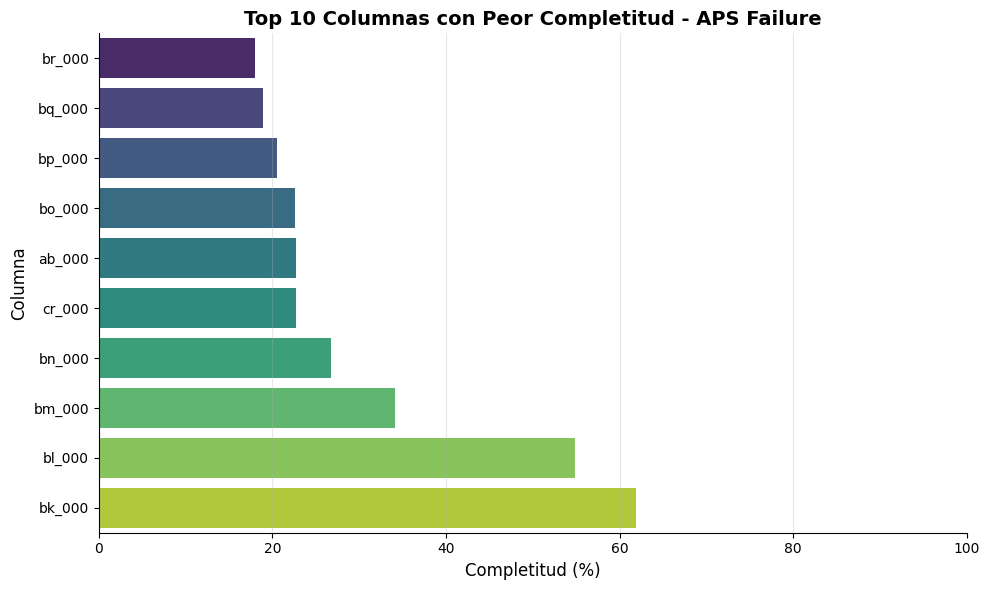

In [45]:
# -------------------------------------------------------
# MINI RETO 2.6 — Calidad del dataset APS Failure
# -------------------------------------------------------

# Paso 1: Completitud por columna
completitud_aps_col = (1 - df_aps.isnull().mean()) * 100
print("\n--- COMPLETITUD POR COLUMNA (df_aps) ---")
print(completitud_aps_col.round(2).to_string())

# Paso 2: Top 10 columnas con peor completitud
columnas_peor_completitud = completitud_aps_col.sort_values(ascending=True).head(10)
print("\n--- TOP 10 COLUMNAS CON PEOR COMPLETITUD ---")
print(columnas_peor_completitud.round(2).to_string())

# Paso 3: Score global
# Reutilizamos la función calcular_calidad definida en CELDA 2.6.A
rep_aps_mini_reto = calcular_calidad(df_aps, 'APS Failure')

completitud_global = rep_aps_mini_reto['completitud_pct']
unicidad_global    = rep_aps_mini_reto['unicidad_pct']
exactitud_global   = rep_aps_mini_reto['exactitud_pct'] if rep_aps_mini_reto['exactitud_pct'] is not None else 100.0

score_global = (completitud_global * 0.4 + unicidad_global * 0.3 + exactitud_global * 0.3)

print(f"\n--- SCORE GLOBAL DE CALIDAD (APS Failure) ---")
print(f"  Completitud: {completitud_global:.2f}%")
print(f"  Unicidad   : {unicidad_global:.2f}%")
print(f"  Exactitud  : {exactitud_global:.2f}%")
print(f"  SCORE FINAL: {score_global:.2f}%")

# Paso 4: Recomendación
print("\n--- RECOMENDACIÓN ---")
if completitud_global < 90:
    print("⚠️  No se recomienda usar este dataset directamente sin imputación.")
    print(f"   El dataset APS Failure tiene una completitud global de {completitud_global:.2f}%. Muchas columnas tienen un alto porcentaje de valores faltantes (como se ve en el top 10).")
    print("   Es crucial aplicar técnicas de imputación (ej. mediana, moda, kNN) o considerar la eliminación de columnas/filas con demasiados nulos antes de usarlo para el modelado.")
else:
    print("✅ Este dataset tiene una buena completitud y podría usarse directamente, aunque revisar las columnas con menos completitud podría ser beneficioso.")

# Visualización de las 10 columnas con peor completitud
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=columnas_peor_completitud.values, y=columnas_peor_completitud.index, palette='viridis', ax=ax)
ax.set_title('Top 10 Columnas con Peor Completitud - APS Failure', fontweight='bold')
ax.set_xlabel('Completitud (%)')
ax.set_ylabel('Columna')
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 🧠 Quiz 2.6 — Validación de Calidad de Datos

In [ ]:
# -------------------------------------------------------
# QUIZ 2.6 — Cuestionario interactivo
# -------------------------------------------------------

def quiz_26():
    score = 0
    total = 4

    print("=" * 60)
    print("🧠 QUIZ 2.6 — Validación de Calidad de Datos")
    print("=" * 60)

    # Pregunta 1 (basada en datos reales)
    comp_aps = (1 - df_aps.isnull().mean().mean()) * 100
    print(f"\n1️⃣  El dataset APS Failure tiene una completitud global de")
    print(f"   aproximadamente {comp_aps:.0f}%. ¿Qué acción se recomienda?")
    print(f"   a) Usar el dataset directamente sin ningún tratamiento")
    print(f"   b) Aplicar imputación y documentar las columnas tratadas")
    print(f"   c) Eliminar el dataset y buscar uno nuevo")
    r1 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r1 == 'b':
        print("   ✅ ¡Correcto! Imputar y documentar es la práctica correcta")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': imputar y documentar")

    # Pregunta 2
    print("\n2️⃣  ¿Qué dimensión de calidad verifica que los valores")
    print("   estén dentro de rangos físicamente posibles?")
    print("   a) Completitud")
    print("   b) Unicidad")
    print("   c) Exactitud")
    r2 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r2 == 'c':
        print("   ✅ ¡Correcto! La exactitud verifica rangos físicos válidos")
        score += 1
    else:
        print("   ❌ La respuesta es 'c': Exactitud")

    # Pregunta 3 (basada en datos reales)
    n_dup_ot = df_ot.duplicated().sum()
    print(f"\n3️⃣  En el dataset OT_2024, ¿cuántos registros duplicados hay?")
    print(f"   a) {n_dup_ot + 100}")
    print(f"   b) {n_dup_ot}")
    print(f"   c) {n_dup_ot + 500}")
    r3 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r3 == 'b':
        print(f"   ✅ ¡Correcto! {n_dup_ot} duplicados en OT_2024")
        score += 1
    else:
        print(f"   ❌ La respuesta es 'b': {n_dup_ot} duplicados")

    # Pregunta 4
    print("\n4️⃣  ¿Qué significa 'Garbage in, garbage out' en ciencia de datos?")
    print("   a) Los modelos siempre producen buenos resultados")
    print("   b) Si los datos de entrada son malos, el modelo producirá malos resultados")
    print("   c) Los datos de mantenimiento siempre son perfectos")
    r4 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r4 == 'b':
        print("   ✅ ¡Correcto! La calidad del modelo depende de la calidad de los datos")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': datos malos → modelo malo")

    print("\n" + "=" * 60)
    print(f"📊 RESULTADO: {score}/{total} respuestas correctas")
    if score == total:
        print("🏆 ¡Excelente! Dominas la validación de calidad de datos")
    elif score >= 2:
        print("👍 Buen trabajo. Repasa las dimensiones de calidad")
    else:
        print("📚 Revisa las seis dimensiones de calidad de datos")
    print("=" * 60)

quiz_26()

---
# 🏁 CIERRE DEL MÓDULO 2 — Resumen y Próximos Pasos

---

## 📋 Lo que aprendiste hoy

| Subtema | Concepto clave | Dataset utilizado |
|---------|---------------|-------------------|
| 2.1 | Fuentes de datos: CMMS, ERP, Sensores | OT_2024, MODBUS-RTU |
| 2.2 | Importación y estructuración correcta | Todos los datasets |
| 2.3 | Limpieza: Outliers, imputación, stuck values | APS Failure, MODBUS-RTU, Rodamientos |
| 2.4 | Transformación: Resampling, escaladores, ventanas | MODBUS-RTU, Rodamientos |
| 2.5 | Feature Engineering: FFT, Wavelet, features temporales | Rodamientos CWRU, feature_time |
| 2.6 | Validación de calidad: 6 dimensiones | Todos los datasets |

## 🔑 Conceptos clave para recordar

1. **IQR** para detectar outliers (robusto ante los propios outliers)
2. **Interpolación lineal** para imputar series temporales de sensores
3. **Varianza en ventana** para detectar stuck values
4. **RobustScaler** para escalar datos industriales con outliers
5. **Kurtosis > 4** → señal de impactos en rodamientos
6. **FFT** para análisis frecuencial | **Wavelet** para análisis tiempo-frecuencia
7. **6 dimensiones de calidad**: Completitud, Temporalidad, Exactitud, Unicidad, Consistencia, Validez



In [46]:
df_fox_limpio = df_fox.dropna(subset=['NO. VEHICULO'])
# -------------------------------------------------------
# CELDA FINAL — Resumen ejecutivo del módulo
# -------------------------------------------------------

print("=" * 70)
print("🏁 RESUMEN EJECUTIVO — MÓDULO 2")
print("   Preparación y Calidad de Datos en Mantenimiento Predictivo")
print("=" * 70)

# Resumen de datasets procesados
print("\n📂 DATASETS PROCESADOS:")
datasets_resumen = [
    ('OT_2024 (CMMS)',    df_ot.shape,           'Órdenes de trabajo reales'),
    ('MODBUS-RTU',        df_modbus.shape,        'Sensor eléctrico industrial'),
    ('Transportes FOX',   df_fox_limpio.shape,    'Inspección de neumáticos'),
    ('Rodamientos CWRU',  df_rodamientos.shape,   'Vibración de rodamientos'),
    ('APS Failure',       df_aps.shape,           'Sensores de camiones Scania'),
    ('feature_time',      df_features.shape,      'Features pre-calculadas CWRU'),
]
for nombre, shape, desc in datasets_resumen:
    print(f"  {nombre:<22} {shape[0]:>8,} × {shape[1]:<4} cols  →  {desc}")

# Resumen de técnicas aplicadas
print("\n🔧 TÉCNICAS APLICADAS:")
tecnicas = [
    ('Detección de outliers',    'IQR (Tukey)',                    '✅'),
    ('Imputación de faltantes',  'Media, Mediana, FFill, Interp.', '✅'),
    ('Detección stuck values',   'Varianza en ventana deslizante', '✅'),
    ('Resampling',               '5min → 1h → 4h → 1día',         '✅'),
    ('Normalización',            'MinMax, Standard, Robust',       '✅'),
    ('Ventanas temporales',      'Rolling mean, std, max, min',    '✅'),
    ('Features temporales',      'RMS, Kurtosis, Crest, Skewness', '✅'),
    ('Análisis FFT',             'Espectro de frecuencias',        '✅'),
    ('Análisis Wavelet',         'Energía por banda (db4)',        '✅'),
    ('Features de mantenimiento','Duración OT, mes, día semana',   '✅'),
    ('Validación de calidad',    '6 dimensiones ISO 8000',         '✅'),
]
for tecnica, metodo, estado in tecnicas:
    print(f"  {estado} {tecnica:<30} → {metodo}")

print("\n" + "=" * 70)
print("✅ Módulo 2 completado exitosamente")
print("   Estás listo para el Módulo 3: Análisis Exploratorio de Datos")
print("=" * 70)

🏁 RESUMEN EJECUTIVO — MÓDULO 2
   Preparación y Calidad de Datos en Mantenimiento Predictivo

📂 DATASETS PROCESADOS:
  OT_2024 (CMMS)         1,048,575 × 39   cols  →  Órdenes de trabajo reales
  MODBUS-RTU                8,920 × 316  cols  →  Sensor eléctrico industrial
  Transportes FOX             128 × 26   cols  →  Inspección de neumáticos
  Rodamientos CWRU          1,998 × 3    cols  →  Vibración de rodamientos
  APS Failure              16,000 × 170  cols  →  Sensores de camiones Scania
  feature_time              2,300 × 10   cols  →  Features pre-calculadas CWRU

🔧 TÉCNICAS APLICADAS:
  ✅ Detección de outliers          → IQR (Tukey)
  ✅ Imputación de faltantes        → Media, Mediana, FFill, Interp.
  ✅ Detección stuck values         → Varianza en ventana deslizante
  ✅ Resampling                     → 5min → 1h → 4h → 1día
  ✅ Normalización                  → MinMax, Standard, Robust
  ✅ Ventanas temporales            → Rolling mean, std, max, min
  ✅ Features temporales    

---
## 🧠 Quiz Final del Módulo 2

In [ ]:
# -------------------------------------------------------
# QUIZ FINAL — Módulo 2 completo
# -------------------------------------------------------

def quiz_final():
    score = 0
    total = 6

    print("=" * 65)
    print("🧠 QUIZ FINAL — Módulo 2: Preparación y Calidad de Datos")
    print("=" * 65)

    # Pregunta 1
    print("\n1️⃣  ¿Cuál es la fórmula del RMS (Root Mean Square)?")
    print("   a) RMS = max(|x|) / mean(|x|)")
    print("   b) RMS = √(mean(x²))")
    print("   c) RMS = (max - min) / std")
    r1 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r1 == 'b':
        print("   ✅ ¡Correcto! RMS = √(media de los cuadrados)")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': RMS = √(mean(x²))")

    # Pregunta 2 (basada en datos reales)
    kurt_h = stats.kurtosis(df_healthy['Measurement'].values)
    kurt_f = stats.kurtosis(df_faulty['Measurement'].values)
    print(f"\n2️⃣  La kurtosis del rodamiento saludable es {kurt_h:.2f} y del")
    print(f"   defectuoso es {kurt_f:.2f}. ¿Cuál es el umbral de alerta?")
    print(f"   a) Kurtosis > 1")
    print(f"   b) Kurtosis > 4")
    print(f"   c) Kurtosis > 10")
    r2 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r2 == 'b':
        print("   ✅ ¡Correcto! Kurtosis > 4 indica posible falla en rodamientos")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': Kurtosis > 4")

    # Pregunta 3
    print("\n3️⃣  ¿Qué escalador es más adecuado para datos industriales")
    print("   que contienen outliers frecuentes?")
    print("   a) MinMaxScaler")
    print("   b) StandardScaler")
    print("   c) RobustScaler")
    r3 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r3 == 'c':
        print("   ✅ ¡Correcto! RobustScaler usa mediana e IQR, robusto ante outliers")
        score += 1
    else:
        print("   ❌ La respuesta es 'c': RobustScaler")

    # Pregunta 4 (basada en datos reales)
    n_tipos_falla = df_features['fault'].nunique()
    print(f"\n4️⃣  ¿Cuántos tipos de falla diferentes hay en el dataset feature_time?")
    print(f"   a) {n_tipos_falla - 2}")
    print(f"   b) {n_tipos_falla}")
    print(f"   c) {n_tipos_falla + 3}")
    r4 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r4 == 'b':
        print(f"   ✅ ¡Correcto! {n_tipos_falla} tipos de falla en el dataset")
        score += 1
    else:
        print(f"   ❌ La respuesta es 'b': {n_tipos_falla} tipos de falla")

    # Pregunta 5
    print("\n5️⃣  ¿Cuál es la diferencia principal entre FFT y Wavelet?")
    print("   a) La FFT es más precisa que la Wavelet")
    print("   b) La FFT analiza frecuencias globales; la Wavelet analiza tiempo Y frecuencia")
    print("   c) La Wavelet solo funciona con señales de vibración")
    r5 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r5 == 'b':
        print("   ✅ ¡Correcto! FFT = frecuencias globales; Wavelet = tiempo-frecuencia")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': FFT global vs Wavelet tiempo-frecuencia")

    # Pregunta 6 (basada en datos reales)
    n_ot_total = len(df_ot)
    n_ot_mp    = (df_ot['Tipo Trabajo'] == 'MP').sum()
    pct_mp     = n_ot_mp / n_ot_total * 100
    print(f"\n6️⃣  En el dataset OT_2024, el {pct_mp:.0f}% de las OTs son de tipo MP.")
    print(f"   ¿Qué significa MP?")
    print(f"   a) Mantenimiento Predictivo")
    print(f"   b) Mantenimiento Preventivo")
    print(f"   c) Mantenimiento de Proceso")
    r6 = input("   Tu respuesta (a/b/c): ").strip().lower()
    if r6 == 'b':
        print("   ✅ ¡Correcto! MP = Mantenimiento Preventivo")
        score += 1
    else:
        print("   ❌ La respuesta es 'b': MP = Mantenimiento Preventivo")

    # Resultado final
    print("\n" + "=" * 65)
    print(f"📊 RESULTADO FINAL: {score}/{total} respuestas correctas")
    pct_score = score / total * 100
    if pct_score == 100:
        print("🏆 ¡PERFECTO! Dominas completamente el Módulo 2")
        print("   Estás listo para el Módulo 3")
    elif pct_score >= 80:
        print("🥇 ¡Excelente! Muy buen dominio del módulo")
    elif pct_score >= 60:
        print("👍 Buen trabajo. Repasa los temas con menor puntaje")
    else:
        print("📚 Revisa el módulo antes de continuar")
        print("   Enfócate en: limpieza, feature engineering y calidad de datos")
    print("=" * 65)

quiz_final()

---

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 30px; border-radius: 12px; text-align: center; font-family: 'Segoe UI', sans-serif; margin-top: 20px;">
  <h2 style="color: #e94560; margin-bottom: 10px;">🎓 ¡Módulo 2 Completado!</h2>
  <p style="color: #a8dadc; font-size: 1.1em;">Has construido un pipeline completo de preparación de datos para mantenimiento predictivo</p>
  <hr style="border-color:#e94560; margin: 15px 0;">
  <p style="color: #ccc;">📌 Guarda este notebook — lo usarás como referencia en los módulos siguientes</p>
  <p style="color: #aaa; font-size: 0.9em;">Módulo 3 → Análisis Exploratorio de Datos (EDA) para Mantenimiento Predictivo</p>
</div>